# NPZ File Structure Analysis and PPG Visualization

This notebook analyzes the structure of NPZ files from `/home/cristic/preprocessed_data/` and visualizes the PPG data.

**Note:** The time_deltas in your data appear to be in milliseconds or need scaling. This notebook handles that automatically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import json
from scipy import signal
from scipy.signal import butter, filtfilt, detrend, find_peaks

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configuration
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')

# Ensure the path exists
if not PREPROCESSED_DATA_PATH.exists():
    print(f"Warning: {PREPROCESSED_DATA_PATH} does not exist. Using current directory instead.")
    PREPROCESSED_DATA_PATH = Path('.')

In [2]:
# for cache in ["train_files_cache.txt", "val_files_cache.txt", "valid_files.txt"]:
#     if os.path.exists(cache):
#         os.remove(cache)
#         print(f"Removed stale cache: {cache}")

In [3]:
cache_files = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]

for cache in cache_files:
    if os.path.exists(cache):
        os.remove(cache)
        print(f"Removed cache: {cache}")

Removed cache: train_files_cache.txt
Removed cache: val_files_cache.txt


In [4]:
def load_npz_file(file_path):
    """Load and return the contents of an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the structure of an NPZ file."""
    print("=" * 60)
    print("NPZ File Structure Analysis")
    print("=" * 60)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key}: shape {item.shape}, dtype {item.dtype}")
        else:
            print(f"  {key}: {type(item).__name__} = {item}")
    print("=" * 60)
    return data

def extract_metadata(data):
    """Extract metadata from NPZ file."""
    metadata = {}
    for key in data.files:
        if key.startswith('meta_'):
            metadata[key] = data[key].item() if data[key].size == 1 else data[key]
        elif key.startswith('vital_'):
            metadata[key] = data[key].item() if data[key].size == 1 else data[key]
    return metadata

def extract_roi_names(data):
    """Extract ROI names from NPZ file."""
    rois = []
    for key in data.files:
        if key.startswith('roi_'):
            rois.append(key)
    return sorted(rois)

def compute_time_array(time_deltas, expected_fps=30):
    """Compute time array from time deltas, handling different time units."""
    # Calculate cumulative time
    time_array = np.cumsum(time_deltas)
    
    # Check if time_deltas are in seconds or need scaling
    num_frames = len(time_deltas)
    total_time = time_array[-1]
    calculated_fps = num_frames / total_time if total_time > 0 else float('inf')
    
    # If FPS is way too high (> 100), assume time_deltas are in milliseconds
    if calculated_fps > 100:
        print(f"  Note: Time deltas appear to be in milliseconds (calculated FPS: {calculated_fps:.2f}). Converting to seconds.")
        time_array = time_array / 1000.0
        total_time = time_array[-1]
        calculated_fps = num_frames / total_time
        print(f"  After scaling: Total time = {total_time:.2f}s, FPS = {calculated_fps:.2f}")
    
    # If FPS is still not matching expected, try to match expected_fps
    if expected_fps and abs(calculated_fps - expected_fps) > 5:
        scale_factor = num_frames / (expected_fps * total_time) if total_time > 0 else 1
        time_array = time_array * scale_factor
        total_time = time_array[-1]
        calculated_fps = num_frames / total_time
        print(f"  Adjusted to match expected FPS: Scale factor = {scale_factor:.4f}, New FPS = {calculated_fps:.2f}")
    
    return time_array

In [5]:
# Find all NPZ files in the preprocessed data directory
npz_files = list(PREPROCESSED_DATA_PATH.rglob('*.npz'))

print(f"Found {len(npz_files)} NPZ files in {PREPROCESSED_DATA_PATH}")

if npz_files:
    print("\nFirst 10 files:")
    for i, file_path in enumerate(npz_files[:10]):
        print(f"  {i+1}. {file_path.name}")
    
    # Select the first file for analysis
    selected_file = npz_files[0]
    print(f"\nSelecting first file for analysis: {selected_file}")
else:
    print("No NPZ files found. Creating a sample file for demonstration...")
    # Create a sample NPZ file for demonstration
    selected_file = Path('sample_demo.npz')
    
    # Create sample data matching the structure described
    num_frames = 450
    # Create realistic time deltas for 30 FPS (each delta = 1/30 second)
    time_deltas = np.ones(num_frames) * (1.0 / 30.0)
    sample_data = {
        'roi_full_face': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'roi_forehead': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'roi_left_eye': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'roi_right_eye': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'roi_nose': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'roi_mouth': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'roi_chin': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'roi_right_cheek_50': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'roi_left_cheek_280': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'roi_chin_199': np.random.rand(num_frames, 24, 24, 3).astype(np.float32),
        'ppg_values': np.random.randn(num_frames).astype(np.float32) * 10 + 100,
        'time_deltas': time_deltas.astype(np.float32),
        'landmarks': np.random.rand(num_frames, 468, 2).astype(np.float32),
        'meta_subject_id': np.array(1020),
        'meta_condition': np.array('after'),
        'meta_camera_type': np.array('FullHDwebcam'),
        'meta_view_type': np.array('front'),
        'meta_chunk_index': np.array(0),
        'meta_start_frame': np.array(0),
        'meta_end_frame': np.array(450),
        'meta_num_frames': np.array(450),
        'vital_upper_ap': np.array(113.0),
        'vital_lower_ap': np.array(78.0),
        'vital_saturation': np.array(98.0),
        'vital_hemoglobin': np.array(12.6),
        'vital_glycated_hemoglobin': np.array(5.56),
        'vital_cholesterol': np.array(4.3),
        'vital_respiratory': np.array(19.0),
        'vital_rigidity': np.array(10.79),
        'vital_pulse': np.array(100.0),
        'vital_stress': np.array(4.0),
    }
    
    np.savez(selected_file, **sample_data)
    print(f"Created sample file: {selected_file}")

Found 4897 NPZ files in /home/cristic/preprocessed_data

First 10 files:
  1. 1156_FullHDwebcam_after_chunk0.npz
  2. 1477_FullHDwebcam_before_chunk8.npz
  3. 1745_FullHDwebcam_after_chunk8.npz
  4. 1477_FullHDwebcam_before_chunk11.npz
  5. 1292_USBVideo_after_chunk14.npz
  6. 1091_FullHDwebcam_before_chunk15.npz
  7. 1181_IriunWebcam_after_chunk13.npz
  8. 1107_USBVideo_after_chunk4.npz
  9. 1091_IriunWebcam_before_chunk10.npz
  10. 1259_IriunWebcam_after_chunk0.npz

Selecting first file for analysis: /home/cristic/preprocessed_data/1156_FullHDwebcam_after_chunk0.npz


In [6]:
# Load the selected file
data = load_npz_file(selected_file)

if data is None:
    raise FileNotFoundError(f"Could not load {selected_file}")

# Analyze the structure
analyze_npz_structure(data)

# Extract metadata and ROI names
metadata = extract_metadata(data)
roi_names = extract_roi_names(data)

print("\nMetadata:")
for key, value in metadata.items():
    print(f"  {key}: {value}")

print(f"\nROI Names ({len(roi_names)}):")
for roi in roi_names:
    print(f"  {roi}")

NPZ File Structure Analysis
  landmarks: shape (450, 468, 2), dtype float32
  meta_camera_type: shape (), dtype <U12
  meta_chunk_index: shape (), dtype int64
  meta_condition: shape (), dtype <U5
  meta_end_frame: shape (), dtype int64
  meta_num_frames: shape (), dtype int64
  meta_start_frame: shape (), dtype int64
  meta_subject_id: shape (), dtype int64
  meta_view_type: shape (), dtype <U5
  ppg_values: shape (450,), dtype float64
  roi_chin: shape (450, 24, 24, 3), dtype uint8
  roi_chin_199: shape (450, 24, 24, 3), dtype uint8
  roi_forehead: shape (450, 24, 24, 3), dtype uint8
  roi_full_face: shape (450, 24, 24, 3), dtype uint8
  roi_left_cheek_280: shape (450, 24, 24, 3), dtype uint8
  roi_left_eye: shape (450, 24, 24, 3), dtype uint8
  roi_mouth: shape (450, 24, 24, 3), dtype uint8
  roi_nose: shape (450, 24, 24, 3), dtype uint8
  roi_right_cheek_50: shape (450, 24, 24, 3), dtype uint8
  roi_right_eye: shape (450, 24, 24, 3), dtype uint8
  time_deltas: shape (450,), dtype f

In [7]:
# Extract PPG data
ppg_values = data['ppg_values']
time_deltas = data['time_deltas']

print(f"PPG Values: shape={ppg_values.shape}, dtype={ppg_values.dtype}")
print(f"Time Deltas: shape={time_deltas.shape}, dtype={time_deltas.dtype}")

# Compute time array with automatic scaling
print("\nComputing time array...")
time_array = compute_time_array(time_deltas, expected_fps=30)
total_time = time_array[-1] - time_array[0]

# Basic statistics
print(f"\nPPG Statistics:")
print(f"  Mean: {ppg_values.mean():.2f}")
print(f"  Std: {ppg_values.std():.2f}")
print(f"  Min: {ppg_values.min():.2f}")
print(f"  Max: {ppg_values.max():.2f}")
print(f"  Range: {ppg_values.max() - ppg_values.min():.2f}")

# Calculate time information
print(f"\nTime Information:")
print(f"  Total duration: {total_time:.2f} seconds")
print(f"  Frame rate: {len(ppg_values) / total_time:.2f} FPS")
print(f"  Expected FPS from metadata: {metadata.get('meta_num_frames', 'N/A') / (metadata.get('meta_end_frame', 1) - metadata.get('meta_start_frame', 0)) if metadata.get('meta_num_frames', 'N/A') != 'N/A' else 'N/A'}")

PPG Values: shape=(450,), dtype=float64
Time Deltas: shape=(450,), dtype=float64

Computing time array...
  Note: Time deltas appear to be in milliseconds (calculated FPS: 399.68). Converting to seconds.
  After scaling: Total time = 0.00s, FPS = 399678.84
  Adjusted to match expected FPS: Scale factor = 13322.6279, New FPS = 30.00

PPG Statistics:
  Mean: 99.57
  Std: 37.73
  Min: 4.00
  Max: 225.00
  Range: 221.00

Time Information:
  Total duration: 14.92 seconds
  Frame rate: 30.16 FPS
  Expected FPS from metadata: 1.0


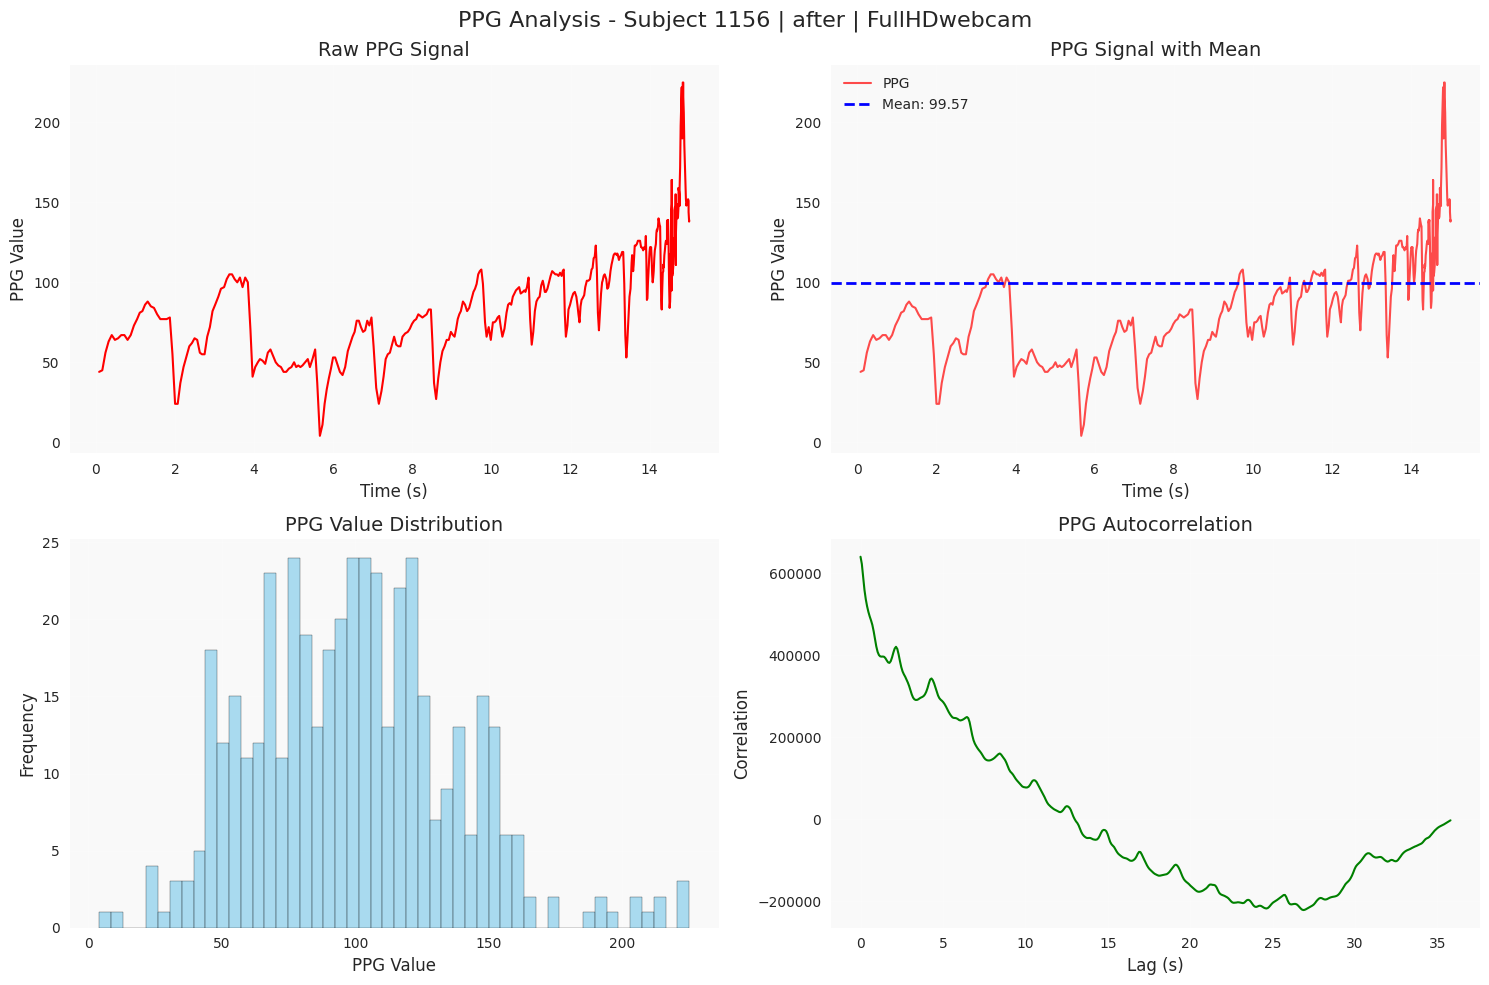

In [8]:
# Plot PPG Signal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'PPG Analysis - Subject {metadata.get("meta_subject_id", "N/A")} | {metadata.get("meta_condition", "N/A")} | {metadata.get("meta_camera_type", "N/A")}', fontsize=16)

# 1. Raw PPG Signal
ax1 = axes[0, 0]
ax1.plot(time_array, ppg_values, linewidth=1.5, color='red')
ax1.set_title('Raw PPG Signal', fontsize=14)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('PPG Value', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f9f9f9')

# 2. PPG Signal with Mean Line
ax2 = axes[0, 1]
ax2.plot(time_array, ppg_values, linewidth=1.5, color='red', alpha=0.7, label='PPG')
ax2.axhline(y=ppg_values.mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {ppg_values.mean():.2f}')
ax2.set_title('PPG Signal with Mean', fontsize=14)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('PPG Value', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f9f9f9')

# 3. PPG Distribution
ax3 = axes[1, 0]
ax3.hist(ppg_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax3.set_title('PPG Value Distribution', fontsize=14)
ax3.set_xlabel('PPG Value', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#f9f9f9')

# 4. PPG Autocorrelation
ax4 = axes[1, 1]
corr = signal.correlate(ppg_values - ppg_values.mean(), ppg_values - ppg_values.mean(), mode='full')
corr = corr[len(corr)//2:]
lags = np.arange(len(corr)) * (time_array[1] - time_array[0]) if len(time_array) > 1 else np.arange(len(corr))
ax4.plot(lags, corr, linewidth=1.5, color='green')
ax4.set_title('PPG Autocorrelation', fontsize=14)
ax4.set_xlabel('Lag (s)', fontsize=12)
ax4.set_ylabel('Correlation', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

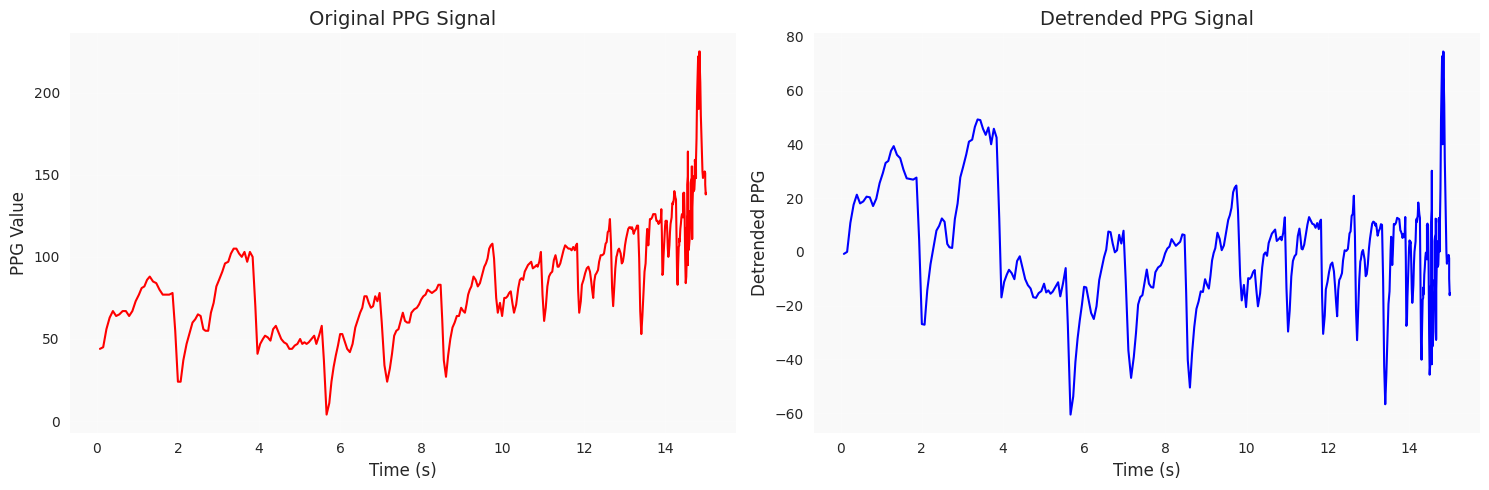

In [9]:
# Detrend the PPG signal
detrended_ppg = detrend(ppg_values)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original PPG
ax1 = axes[0]
ax1.plot(time_array, ppg_values, linewidth=1.5, color='red')
ax1.set_title('Original PPG Signal', fontsize=14)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('PPG Value', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f9f9f9')

# Detrended PPG
ax2 = axes[1]
ax2.plot(time_array, detrended_ppg, linewidth=1.5, color='blue')
ax2.set_title('Detrended PPG Signal', fontsize=14)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Detrended PPG', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

Filter parameters: fs=30.16 Hz, nyq=15.08 Hz, low=0.0444, high=0.2652


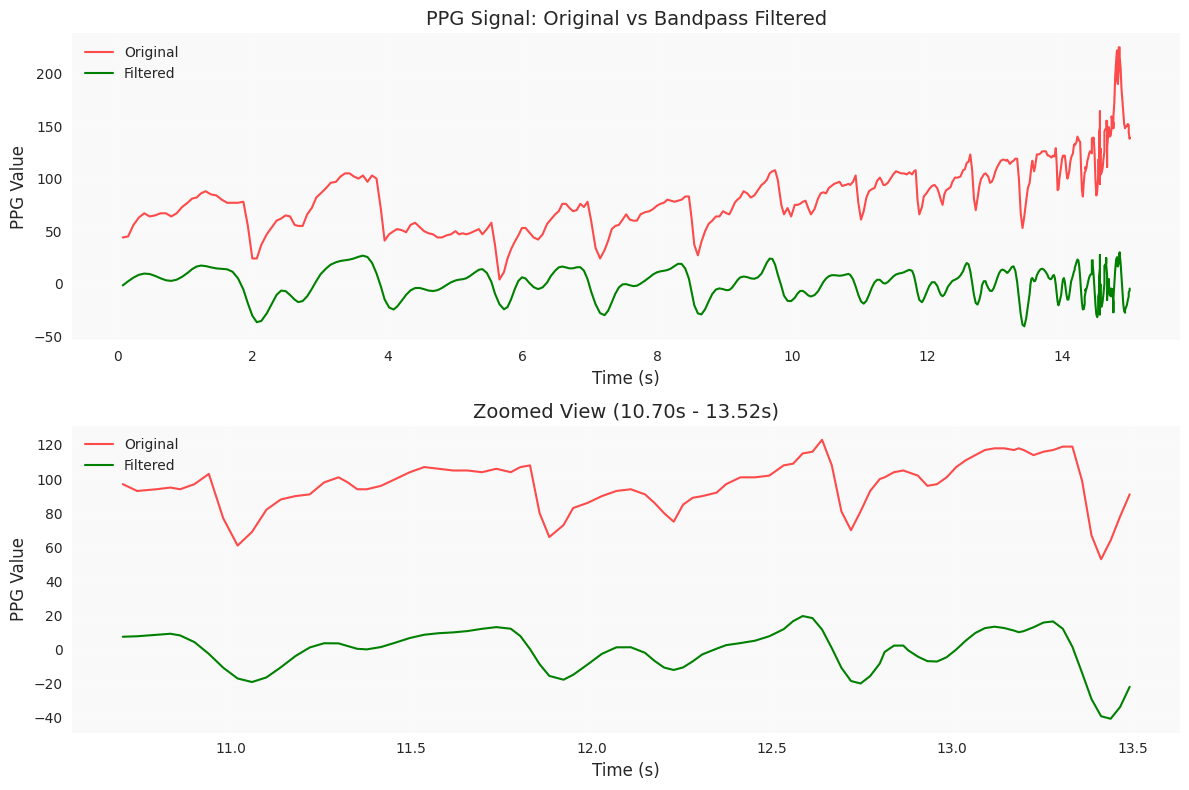

In [10]:
# Apply bandpass filter to extract heart rate
# Typical heart rate range: 40-240 BPM = 0.67-4 Hz
lowcut = 0.67  # 40 BPM
highcut = 4.0  # 240 BPM
fs = len(ppg_values) / total_time  # Sampling frequency
nyq = 0.5 * fs
low = lowcut / nyq
high = highcut / nyq

print(f"Filter parameters: fs={fs:.2f} Hz, nyq={nyq:.2f} Hz, low={low:.4f}, high={high:.4f}")

# Design bandpass filter
b, a = butter(3, [low, high], btype='band')
filtered_ppg = filtfilt(b, a, ppg_values)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Original vs Filtered
ax1 = axes[0]
ax1.plot(time_array, ppg_values, linewidth=1.5, color='red', alpha=0.7, label='Original')
ax1.plot(time_array, filtered_ppg, linewidth=1.5, color='green', label='Filtered')
ax1.set_title('PPG Signal: Original vs Bandpass Filtered', fontsize=14)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('PPG Value', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f9f9f9')

# Zoomed in view - use middle 20% of the data
ax2 = axes[1]
zoom_start_idx = int(len(time_array) * 0.4)
zoom_end_idx = int(len(time_array) * 0.6)
zoom_start = time_array[zoom_start_idx]
zoom_end = time_array[zoom_end_idx]
ax2.plot(time_array[zoom_start_idx:zoom_end_idx], ppg_values[zoom_start_idx:zoom_end_idx], linewidth=1.5, color='red', alpha=0.7, label='Original')
ax2.plot(time_array[zoom_start_idx:zoom_end_idx], filtered_ppg[zoom_start_idx:zoom_end_idx], linewidth=1.5, color='green', label='Filtered')
ax2.set_title(f'Zoomed View ({zoom_start:.2f}s - {zoom_end:.2f}s)', fontsize=14)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('PPG Value', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

Peak Detection:
  Number of peaks: 15
  Minimum peak distance: 10.0 samples
  Average Heart Rate: 171.76 BPM
  Median Heart Rate: 78.56 BPM
  Heart Rate Std: 195.58 BPM
  Heart Rate Range: 25.01 - 646.42 BPM
  Vital Pulse (from metadata): 103.0


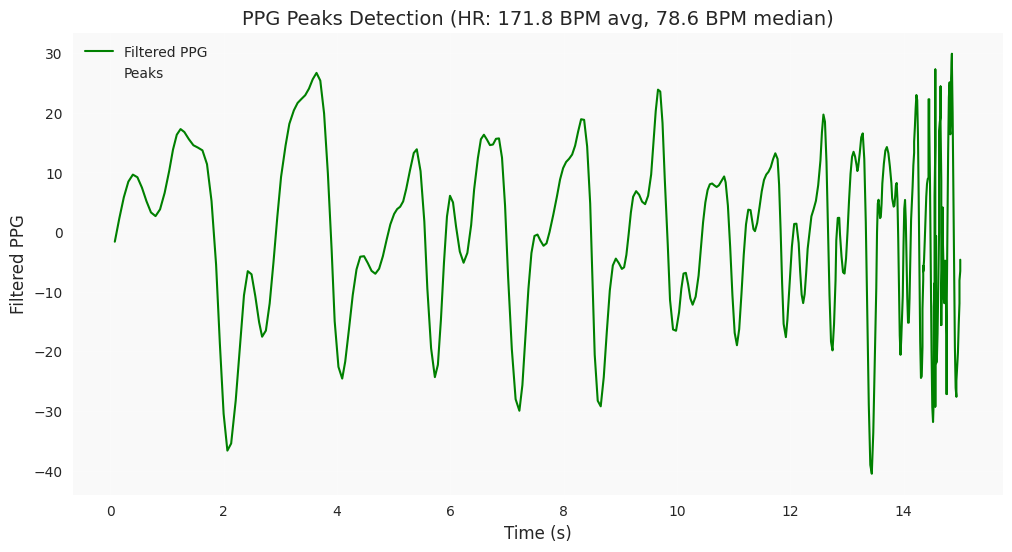

In [11]:
# Find peaks in filtered PPG
# Use minimum distance based on expected heart rate (60-180 BPM = 1-0.33 Hz)
min_peak_distance = fs * 0.33  # Minimum distance for 180 BPM
peaks, _ = find_peaks(filtered_ppg, height=np.percentile(filtered_ppg, 75), distance=min_peak_distance)

# Calculate heart rate
peak_times = time_array[peaks]
if len(peak_times) > 1:
    inter_peak_intervals = np.diff(peak_times)
    heart_rate = 60 / inter_peak_intervals  # Convert to BPM
    avg_heart_rate = heart_rate.mean()
    std_heart_rate = heart_rate.std()
    median_heart_rate = np.median(heart_rate)
else:
    avg_heart_rate = None
    std_heart_rate = None
    median_heart_rate = None

print(f"Peak Detection:")
print(f"  Number of peaks: {len(peaks)}")
print(f"  Minimum peak distance: {min_peak_distance:.1f} samples")
if avg_heart_rate is not None:
    print(f"  Average Heart Rate: {avg_heart_rate:.2f} BPM")
    print(f"  Median Heart Rate: {median_heart_rate:.2f} BPM")
    print(f"  Heart Rate Std: {std_heart_rate:.2f} BPM")
    print(f"  Heart Rate Range: {heart_rate.min():.2f} - {heart_rate.max():.2f} BPM")
    print(f"  Vital Pulse (from metadata): {metadata.get('vital_pulse', 'N/A')}")

# Plot with peaks
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(time_array, filtered_ppg, linewidth=1.5, color='green', label='Filtered PPG')
ax.plot(time_array[peaks], filtered_ppg[peaks], 'x', color='red', markersize=8, label='Peaks')
title = f'PPG Peaks Detection (HR: {avg_heart_rate:.1f} BPM avg, {median_heart_rate:.1f} BPM median)' if avg_heart_rate is not None else 'PPG Peaks Detection'
ax.set_title(title, fontsize=14)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Filtered PPG', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f9f9f9')
plt.show()

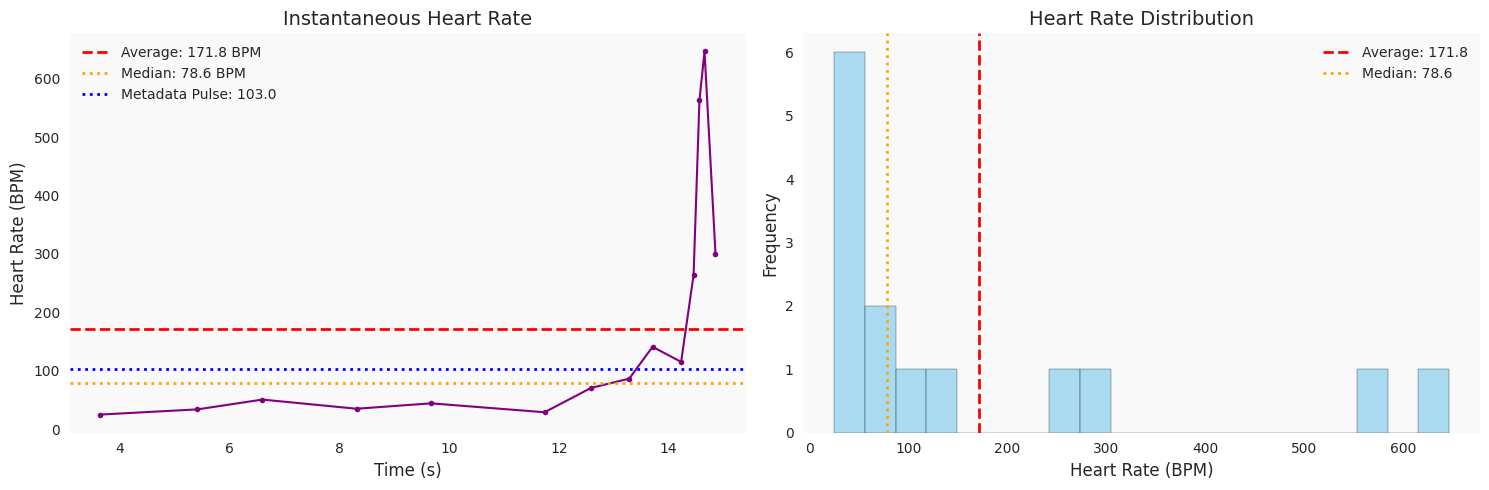

In [12]:
if avg_heart_rate is not None:
    # Calculate instantaneous heart rate
    instant_hr_times = peak_times[1:]
    instant_hr = heart_rate
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Instantaneous HR
    ax1 = axes[0]
    ax1.plot(instant_hr_times, instant_hr, 'o-', color='purple', markersize=4, linewidth=1.5)
    ax1.axhline(y=avg_heart_rate, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_heart_rate:.1f} BPM')
    ax1.axhline(y=median_heart_rate, color='orange', linestyle=':', linewidth=2, label=f'Median: {median_heart_rate:.1f} BPM')
    ax1.axhline(y=metadata.get('vital_pulse', avg_heart_rate), color='blue', linestyle=':', linewidth=2, label=f'Metadata Pulse: {metadata.get("vital_pulse", "N/A")}')
    ax1.set_title('Instantaneous Heart Rate', fontsize=14)
    ax1.set_xlabel('Time (s)', fontsize=12)
    ax1.set_ylabel('Heart Rate (BPM)', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_facecolor('#f9f9f9')
    
    # Histogram of HR
    ax2 = axes[1]
    ax2.hist(instant_hr, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax2.axvline(x=avg_heart_rate, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_heart_rate:.1f}')
    ax2.axvline(x=median_heart_rate, color='orange', linestyle=':', linewidth=2, label=f'Median: {median_heart_rate:.1f}')
    ax2.set_title('Heart Rate Distribution', fontsize=14)
    ax2.set_xlabel('Heart Rate (BPM)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_facecolor('#f9f9f9')
    
    plt.tight_layout()
    plt.show()

ROI Data Analysis:
--------------------------------------------------

roi_chin:
  Shape: (450, 24, 24, 3)
  Frames: 450, Height: 24, Width: 24, Channels: 3
  Data type: uint8
  Memory size: 759.38 KB
  First frame mean: 54.7326
  First frame std: 37.7892

roi_chin_199:
  Shape: (450, 24, 24, 3)
  Frames: 450, Height: 24, Width: 24, Channels: 3
  Data type: uint8
  Memory size: 759.38 KB
  First frame mean: 49.2998
  First frame std: 37.0350

roi_forehead:
  Shape: (450, 24, 24, 3)
  Frames: 450, Height: 24, Width: 24, Channels: 3
  Data type: uint8
  Memory size: 759.38 KB
  First frame mean: 82.5486
  First frame std: 44.4031

roi_full_face:
  Shape: (450, 24, 24, 3)
  Frames: 450, Height: 24, Width: 24, Channels: 3
  Data type: uint8
  Memory size: 759.38 KB
  First frame mean: 87.9537
  First frame std: 48.6804

roi_left_cheek_280:
  Shape: (450, 24, 24, 3)
  Frames: 450, Height: 24, Width: 24, Channels: 3
  Data type: uint8
  Memory size: 759.38 KB
  First frame mean: 104.7951
  F

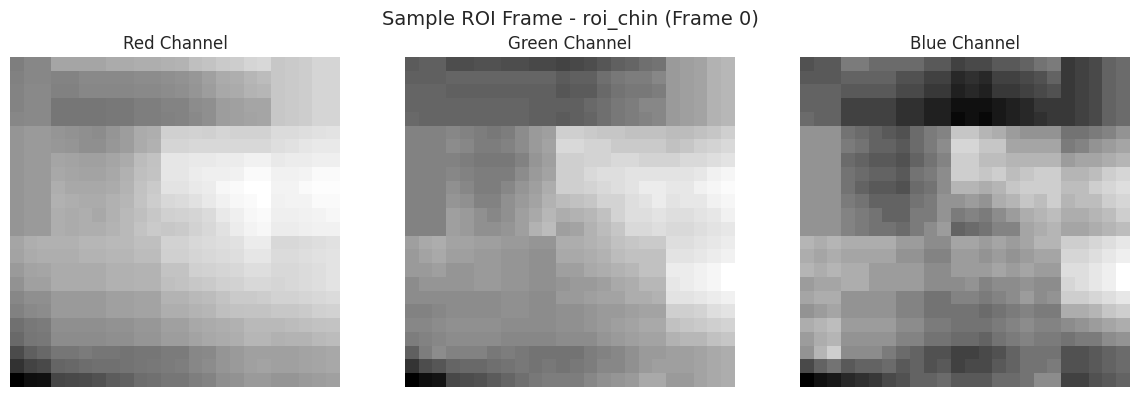

In [13]:
# Display information about ROI data
print("ROI Data Analysis:")
print("-" * 50)

for roi_name in roi_names[:5]:  # Show first 5 ROIs
    roi_data = data[roi_name]
    print(f"\n{roi_name}:")
    print(f"  Shape: {roi_data.shape}")
    print(f"  Frames: {roi_data.shape[0]}, Height: {roi_data.shape[1]}, Width: {roi_data.shape[2]}, Channels: {roi_data.shape[3]}")
    print(f"  Data type: {roi_data.dtype}")
    print(f"  Memory size: {roi_data.nbytes / 1024:.2f} KB")
    
    # Sample statistics for first frame
    first_frame = roi_data[0]
    print(f"  First frame mean: {first_frame.mean():.4f}")
    print(f"  First frame std: {first_frame.std():.4f}")

# Visualize a sample ROI frame
if roi_names:
    sample_roi = roi_names[0]  # First ROI
    sample_frame = data[sample_roi][0]  # First frame
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f'Sample ROI Frame - {sample_roi} (Frame 0)', fontsize=14)
    
    for channel, color, title in zip(range(3), ['red', 'green', 'blue'], ['Red Channel', 'Green Channel', 'Blue Channel']):
        axes[channel].imshow(sample_frame[:, :, channel], cmap='gray')
        axes[channel].set_title(title, fontsize=12)
        axes[channel].axis('off')
    
    plt.tight_layout()
    plt.show()


Landmarks Data:
  Shape: (450, 468, 2)
  Frames: 450, Landmarks per frame: 468, Coordinates: 2


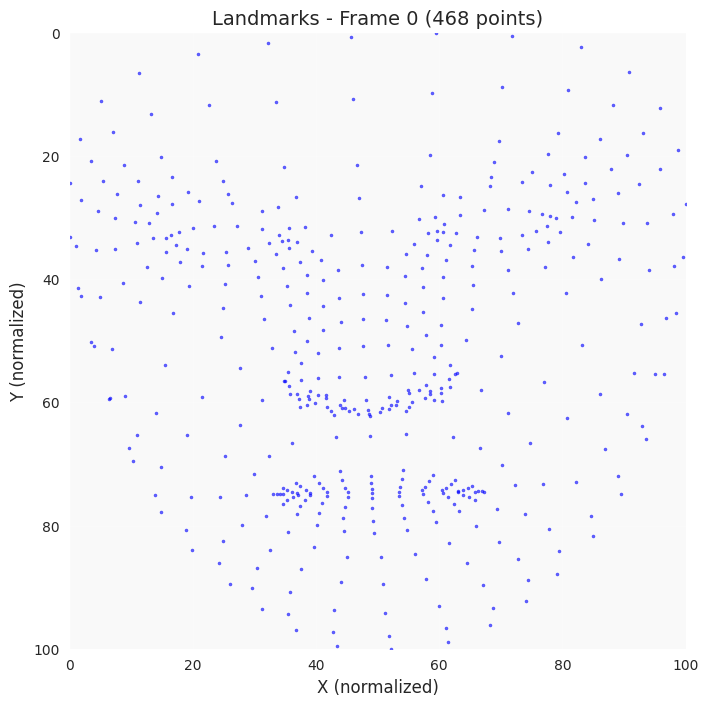

In [14]:
# Extract landmarks
landmarks = data['landmarks']
print(f"\nLandmarks Data:")
print(f"  Shape: {landmarks.shape}")
print(f"  Frames: {landmarks.shape[0]}, Landmarks per frame: {landmarks.shape[1]}, Coordinates: {landmarks.shape[2]}")

# Visualize landmarks for first frame
first_frame_landmarks = landmarks[0]

fig, ax = plt.subplots(figsize=(8, 8))

# Plot landmarks
x_coords = first_frame_landmarks[:, 0]
y_coords = first_frame_landmarks[:, 1]

# Normalize coordinates for display
x_min, x_max = x_coords.min(), x_coords.max()
y_min, y_max = y_coords.min(), y_coords.max()

# Scale to image coordinates
scale = 100
x_scaled = ((x_coords - x_min) / (x_max - x_min)) * scale
y_scaled = ((y_coords - y_min) / (y_max - y_min)) * scale

ax.scatter(x_scaled, y_scaled, s=5, c='blue', alpha=0.6)
ax.set_title(f'Landmarks - Frame 0 ({len(x_coords)} points)', fontsize=14)
ax.set_xlabel('X (normalized)', fontsize=12)
ax.set_ylabel('Y (normalized)', fontsize=12)
ax.set_xlim(0, scale)
ax.set_ylim(scale, 0)  # Invert Y axis for image coordinates
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f9f9f9')
plt.show()

In [15]:
print("=" * 60)
print("METADATA SUMMARY")
print("=" * 60)

# Subject information
print("\nSubject Information:")
print(f"  Subject ID: {metadata.get('meta_subject_id', 'N/A')}")
print(f"  Condition: {metadata.get('meta_condition', 'N/A')}")

# Camera information
print("\nCamera Information:")
print(f"  Camera Type: {metadata.get('meta_camera_type', 'N/A')}")
print(f"  View Type: {metadata.get('meta_view_type', 'N/A')}")

# Chunk information
print("\nChunk Information:")
print(f"  Chunk Index: {metadata.get('meta_chunk_index', 'N/A')}")
print(f"  Start Frame: {metadata.get('meta_start_frame', 'N/A')}")
print(f"  End Frame: {metadata.get('meta_end_frame', 'N/A')}")
print(f"  Number of Frames: {metadata.get('meta_num_frames', 'N/A')}")

# Vital signs
print("\nVital Signs:")
vital_keys = [k for k in metadata.keys() if k.startswith('vital_')]
for key in vital_keys:
    value = metadata[key]
    # Format the key name
    display_name = key.replace('vital_', '').replace('_', ' ').title()
    print(f"  {display_name}: {value}")

print("=" * 60)

METADATA SUMMARY

Subject Information:
  Subject ID: 1156
  Condition: after

Camera Information:
  Camera Type: FullHDwebcam
  View Type: front

Chunk Information:
  Chunk Index: 0
  Start Frame: 0
  End Frame: 450
  Number of Frames: 450

Vital Signs:
  Upper Ap: 120.0
  Lower Ap: 70.0
  Saturation: 98.0
  Hemoglobin: 11.6
  Glycated Hemoglobin: 5.16
  Cholesterol: 4.1
  Respiratory: 19.0
  Rigidity: 3.77
  Pulse: 103.0
  Stress: 4.0


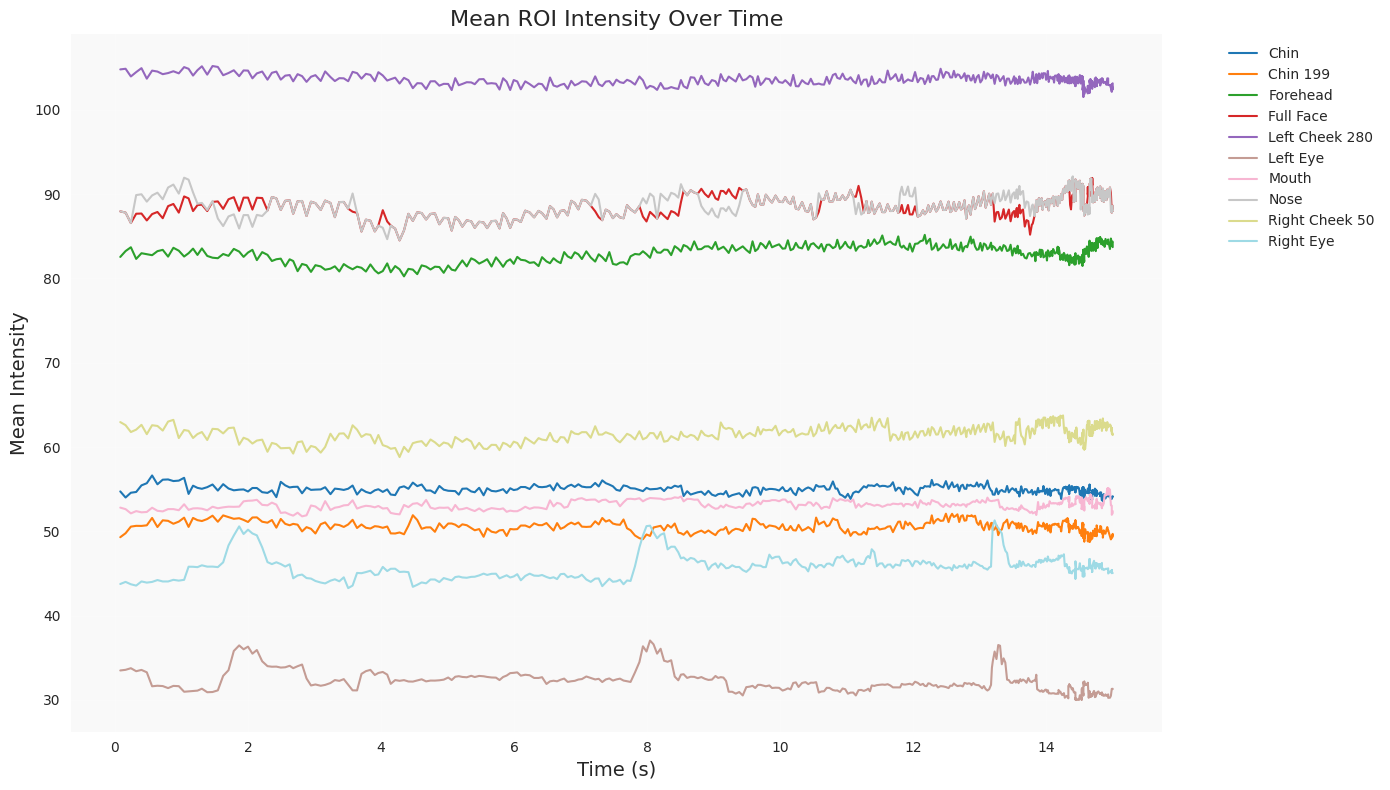

In [16]:
# Calculate mean intensity for each ROI over time
roi_means = {}
for roi_name in roi_names:
    roi_data = data[roi_name]
    # Calculate mean across spatial dimensions (H, W, C)
    roi_means[roi_name] = roi_data.mean(axis=(1, 2, 3))

# Plot mean intensity over time for all ROIs
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.tab20(np.linspace(0, 1, len(roi_names)))

for i, roi_name in enumerate(roi_names):
    ax.plot(time_array, roi_means[roi_name], 
            linewidth=1.5, color=colors[i], 
            label=roi_name.replace('roi_', '').replace('_', ' ').title())

ax.set_title('Mean ROI Intensity Over Time', fontsize=16)
ax.set_xlabel('Time (s)', fontsize=14)
ax.set_ylabel('Mean Intensity', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

Correlation between PPG and ROI Mean Intensity:
------------------------------------------------------------
  Left Eye                 : -0.5431
  Full Face                : 0.5097
  Nose                     : 0.4852
  Right Cheek 50           : 0.4497
  Forehead                 : 0.3736
  Chin                     : -0.3525
  Chin 199                 : -0.2763
  Mouth                    : 0.1908
  Left Cheek 280           : -0.1300
  Right Eye                : 0.0772


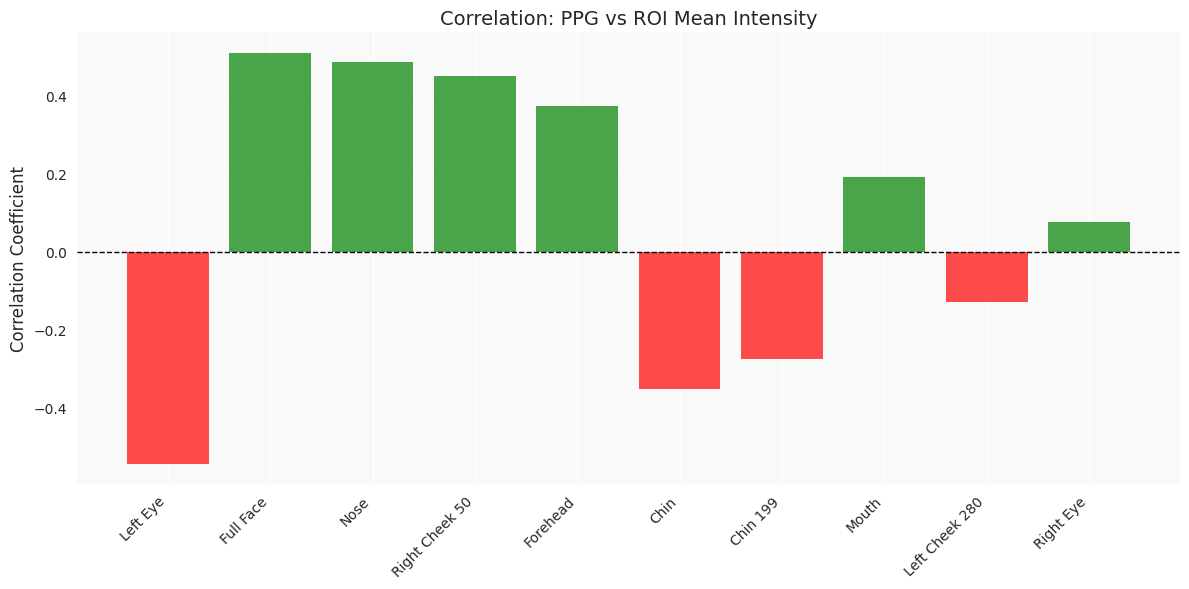

In [17]:
# Calculate correlation between PPG and ROI mean intensities
correlations = {}
for roi_name in roi_names:
    corr = np.corrcoef(ppg_values, roi_means[roi_name])[0, 1]
    correlations[roi_name] = corr

# Sort by correlation strength
sorted_correlations = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

print("Correlation between PPG and ROI Mean Intensity:")
print("-" * 60)
for roi_name, corr in sorted_correlations:
    display_name = roi_name.replace('roi_', '').replace('_', ' ').title()
    print(f"  {display_name:25s}: {corr:.4f}")

# Plot correlations
fig, ax = plt.subplots(figsize=(12, 6))
roi_names_sorted = [item[0] for item in sorted_correlations]
corr_values = [item[1] for item in sorted_correlations]

colors = ['red' if c < 0 else 'green' for c in corr_values]
ax.bar(range(len(corr_values)), corr_values, color=colors, alpha=0.7)

# Custom x-axis labels
x_labels = [name.replace('roi_', '').replace('_', ' ').title() for name in roi_names_sorted]
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)

ax.set_title('Correlation: PPG vs ROI Mean Intensity', fontsize=14)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.show()

In [18]:
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

# PPG statistics
print("\nPPG Signal:")
print(f"  Duration: {total_time:.2f} seconds")
print(f"  Frames: {len(ppg_values)}")
print(f"  Frame Rate: {len(ppg_values) / total_time:.2f} FPS")
print(f"  Mean: {ppg_values.mean():.2f}")
print(f"  Std: {ppg_values.std():.2f}")
print(f"  Min: {ppg_values.min():.2f}")
print(f"  Max: {ppg_values.max():.2f}")

if avg_heart_rate is not None:
    print(f"  Estimated Heart Rate: {avg_heart_rate:.2f} +- {std_heart_rate:.2f} BPM")
    print(f"  Median Heart Rate: {median_heart_rate:.2f} BPM")

# ROI statistics
print("\nROI Statistics:")
for roi_name in roi_names:
    roi_data = data[roi_name]
    mean_val = roi_data.mean()
    std_val = roi_data.std()
    display_name = roi_name.replace('roi_', '').replace('_', ' ').title()
    print(f"  {display_name:25s}: mean={mean_val:.2f}, std={std_val:.2f}")

# Landmarks statistics
print(f"\nLandmarks:")
print(f"  Total landmarks: {landmarks.shape[1]}")
print(f"  Frames: {landmarks.shape[0]}")

print("=" * 60)

SUMMARY STATISTICS

PPG Signal:
  Duration: 14.92 seconds
  Frames: 450
  Frame Rate: 30.16 FPS
  Mean: 99.57
  Std: 37.73
  Min: 4.00
  Max: 225.00
  Estimated Heart Rate: 171.76 +- 195.58 BPM
  Median Heart Rate: 78.56 BPM

ROI Statistics:
  Chin                     : mean=54.90, std=38.56
  Chin 199                 : mean=50.45, std=37.15
  Forehead                 : mean=83.06, std=44.47
  Full Face                : mean=88.84, std=48.52
  Left Cheek 280           : mean=103.48, std=44.97
  Left Eye                 : mean=31.88, std=29.28
  Mouth                    : mean=53.18, std=42.95
  Nose                     : mean=88.97, std=48.45
  Right Cheek 50           : mean=61.63, std=34.56
  Right Eye                : mean=45.82, std=38.97

Landmarks:
  Total landmarks: 468
  Frames: 450


In [19]:
# Create a summary dictionary
analysis_summary = {
    'filename': str(selected_file.name),
    'subject_id': metadata.get('meta_subject_id', 'N/A'),
    'condition': metadata.get('meta_condition', 'N/A'),
    'camera_type': metadata.get('meta_camera_type', 'N/A'),
    'view_type': metadata.get('meta_view_type', 'N/A'),
    'num_frames': len(ppg_values),
    'duration_seconds': float(total_time),
    'frame_rate': float(len(ppg_values) / total_time),
    'ppg_mean': float(ppg_values.mean()),
    'ppg_std': float(ppg_values.std()),
    'ppg_min': float(ppg_values.min()),
    'ppg_max': float(ppg_values.max()),
    'estimated_heart_rate': float(avg_heart_rate) if avg_heart_rate is not None else None,
    'heart_rate_std': float(std_heart_rate) if std_heart_rate is not None else None,
    'median_heart_rate': float(median_heart_rate) if median_heart_rate is not None else None,
    'metadata_pulse': float(metadata.get('vital_pulse', 'N/A')),
    'num_rois': len(roi_names),
    'roi_names': roi_names,
    'correlations': {k: float(v) for k, v in correlations.items()},
    'timestamp': str(np.datetime64('now')),
}

# Save summary to JSON
summary_file = selected_file.with_suffix('.analysis.json')
with open(summary_file, 'w') as f:
    json.dump(analysis_summary, f, indent=2)

print(f"\nAnalysis summary saved to: {summary_file}")


Analysis summary saved to: /home/cristic/preprocessed_data/1156_FullHDwebcam_after_chunk0.analysis.json


In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

class SCNN_9ROIs(nn.Module):
    def __init__(self):
        super(SCNN_9ROIs, self).__init__()
        
        # Matches checkpoint shapes: 27 input channels, 3x3x3 spatio-temporal kernels
        self.spatial_temporal_feature_extractor = nn.Sequential(
            nn.Conv3d(in_channels=27, out_channels=32, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(32),
            nn.ELU(),
            nn.Conv3d(in_channels=32, out_channels=64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1)) # Collapses spatial (H, W) to 1x1, keeps temporal depth
        )
        
        # Matches regression head weight shape: torch.Size([1, 64])
        self.regression_head = nn.Linear(64, 1)

    def forward(self, x):
        # Expected input shape: [Batch, 27, Frames, H, W]
        x = self.spatial_temporal_feature_extractor(x) # Output shape: [Batch, 64, Frames, 1, 1]
        
        # Collapse spatial singleton dimensions -> [Batch, 64, Frames]
        x = x.squeeze(-1).squeeze(-1)
        
        # Permute to frame-wise linear configuration -> [Batch, Frames, 64]
        x = x.permute(0, 2, 1)
        
        # Apply the frame-wise regression head -> [Batch, Frames, 1]
        out = self.regression_head(x)
        
        # Return standard flat layout -> [Batch, Frames]
        return out.squeeze(-1)
def run_single_file_inference(model_path, sample_npz_path, device='cuda'):
    # 1. Setup execution environment and load weights
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
    # Initialize your model architecture
    model = SCNN_9rois()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    # 2. Extract and pre-process the 9 target ROIs
    selected_rois = [
        'roi_chin', 'roi_chin_199', 'roi_forehead', 'roi_left_cheek_280', 
        'roi_left_eye', 'roi_mouth', 'roi_nose', 'roi_right_cheek_50', 'roi_right_eye'
    ]
    
    with np.load(sample_npz_path) as data:
        rois_list = []
        for roi_name in selected_rois:
            roi_data = data[roi_name].astype(np.float32) / 255.0
            rois_list.append(roi_data)
        
        # Concat along channel axis -> (450, 24, 24, 27)
        stacked_rois = np.concatenate(rois_list, axis=-1)
        # Permute to layout required by Conv3D -> (27, 450, 24, 24)
        stacked_rois = np.transpose(stacked_rois, (3, 0, 1, 2))
        
        # Load and normalize true PPG signal
        gt_ppg = data['ppg_values'].astype(np.float32)
        gt_ppg = (gt_ppg - np.mean(gt_ppg)) / (np.std(gt_ppg) + 1e-6)
        
        # Read subject ID for plotting details
        subject_id = data['meta_subject_id']
        condition = data['meta_condition']

    # 3. Model Evaluation Pass
    # Add batch dimension: (1, 27, 450, 24, 24)
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(device)
    # Print tensor statistics right before model inference in BOTH scripts:
    print(f"Shape:       {input_tensor.shape}")
    print(
        f"Min/Max:     {input_tensor.min().item():.4f} / {input_tensor.max().item():.4f}"
    )
    print(f"Mean/Std:    {input_tensor.mean().item():.4f} / {input_tensor.std().item():.4f}")
    print(f"First frame ROI 0 channels: {input_tensor[0, :, 0, 0].detach().cpu().numpy()}")
    with torch.no_grad():
        prediction = model(input_tensor)
        # Remove batch dimension and move to CPU
        pred_ppg = prediction.squeeze(0).cpu().numpy()

    # 4. Generate Signal Comparison Plot
    plt.figure(figsize=(15, 5))
    time_axis = np.arange(len(gt_ppg))
    
    plt.plot(time_axis, gt_ppg, label='Ground Truth PPG', color='#2ca02c', linewidth=2, alpha=0.8)
    plt.plot(time_axis, pred_ppg, label='SCNN 9-ROI Prediction', color='#d62728', linewidth=2, linestyle='--')
    
    plt.title(f"rPPG Waveform Tracking Validation (Subject: {subject_id} | Condition: {condition})", fontsize=12, fontweight='bold')
    plt.xlabel('Frame Timeline')
    plt.ylabel('Normalized Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Example execution (Adjust file paths to your environment):
run_single_file_inference(
    model_path="best_scnn_9rois.pth", 
    sample_npz_path="/home/cristic/preprocessed_data/1020_USBVideo_after_chunk6.npz"
)

NameError: name 'SCNN_9rois' is not defined

In [ ]:
print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print(f"File analyzed: {selected_file}")
print(f"Summary saved to: {summary_file}")
print("\nTo analyze another file, change the 'selected_file' variable and re-run the cells.")

In [ ]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. SCNN Model Adapted for 9 ROIs
# -------------------------------------------------------------
class SCNN_9rois(nn.Module):
    def __init__(self):
        super(SCNN_9rois, self).__init__()
        # Input channels: 9 ROIs * 3 channels (RGB) = 27 channels
        # Temporal depth fixed at 450 frames, spatial size 24x24
        self.spatial_temporal_feature_extractor = nn.Sequential(
            nn.Conv3d(in_channels=27, out_channels=32, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.Conv3d(32, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            # Pool spatial dimensions (H, W) down to 1x1 while keeping the 450 frames intact
            nn.AdaptiveAvgPool3d((450, 1, 1))
        )
        self.regression_head = nn.Linear(64, 1)

    def forward(self, x):
        # x shape: (Batch, 27, 450, 24, 24)
        features = self.spatial_temporal_feature_extractor(x)  # (Batch, 64, 450, 1, 1)
        features = features.squeeze(-1).squeeze(-1)            # (Batch, 64, 450)
        features = features.permute(0, 2, 1)                    # (Batch, 450, 64)
        
        output_signal = self.regression_head(features)          # (Batch, 450, 1)
        return output_signal.squeeze(-1)                        # (Batch, 450)

# -------------------------------------------------------------
# 2. PyTorch Dataset Supporting 9 ROIs
# -------------------------------------------------------------
# class Rppg9RoiDataset(Dataset):
#     def __init__(self, file_paths, expected_frames=450):
#         self.selected_rois = [
#             'roi_chin', 'roi_chin_199', 'roi_forehead', 'roi_left_cheek_280', 
#             'roi_left_eye', 'roi_mouth', 'roi_nose', 'roi_right_cheek_50', 'roi_right_eye'
#         ]
#         self.expected_frames = expected_frames
        
#         # Filter out files that don't match the target frame depth upfront
#         self.valid_file_paths = []
#         print("Validating file tracking dimensions...")
#         for path in file_paths:
#             try:
#                 # Using lambda to only read the structural headers without loading full arrays into memory
#                 with np.load(path) as data:
#                     if data[self.selected_rois[0]].shape[0] == self.expected_frames:
#                         self.valid_file_paths.append(path)
#             except Exception:
#                 continue
#         print(f"Filtered out {len(file_paths) - len(self.valid_file_paths)} files due to frame length mismatch.")

#     def __len__(self):
#         return len(self.valid_file_paths)

#     def __getitem__(self, idx):
#         with np.load(self.valid_file_paths[idx]) as data:
#             rois_list = []
#             for roi_name in self.selected_rois:
#                 roi_data = data[roi_name].astype(np.float32) / 255.0
#                 rois_list.append(roi_data)
            
#             # Stack to (450, 24, 24, 27)
#             stacked_rois = np.concatenate(rois_list, axis=-1)
#             # Permute to (Channels, Time, Height, Width) -> (27, 450, 24, 24)
#             stacked_rois = np.transpose(stacked_rois, (3, 0, 1, 2))
            
#             ppg = data['ppg_values'].astype(np.float32)
#             ppg = (ppg - np.mean(ppg)) / (np.std(ppg) + 1e-6)

#         return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg, dtype=torch.float32)
# class ScalableRppgDataset(Dataset):
#     def __init__(self, file_paths, expected_frames=450, cache_file="valid_files.txt"):
#         self.selected_rois = [
#             'roi_chin', 'roi_chin_199', 'roi_forehead', 'roi_left_cheek_280', 
#             'roi_left_eye', 'roi_mouth', 'roi_nose', 'roi_right_cheek_50', 'roi_right_eye'
#         ]
#         self.expected_frames = expected_frames
        
#         # Performance Optimization: Cache verified files to avoid rescanning 30k paths next time
#         if os.path.exists(cache_file):
#             print(f"Loading cached file paths from {cache_file}...")
#             with open(cache_file, "r") as f:
#                 self.valid_file_paths = [line.strip() for line in f.readlines() if line.strip()]
#         else:
#             print(f"Scanning {len(file_paths)} files. This should only run once...")
#             self.valid_file_paths = []
#             for path in file_paths:
#                 try:
#                     # mmap_mode allows reading headers instantly without loading full arrays
#                     with np.load(path, mmap_mode='r') as data:
#                         if data[self.selected_rois[0]].shape[0] == self.expected_frames:
#                             self.valid_file_paths.append(path)
#                 except Exception:
#                     continue
            
#             # Write cache
#             with open(cache_file, "w") as f:
#                 for path in self.valid_file_paths:
#                     f.write(f"{path}\n")
                    
#         print(f"Dataset ready. Total valid samples: {len(self.valid_file_paths)}")

#     def __len__(self):
#         return len(self.valid_file_paths)

#     def __getitem__(self, idx):
#         # mmap_mode='r' keeps disk tracking fast and parallel-friendly across workers
#         with np.load(self.valid_file_paths[idx], mmap_mode='r') as data:
#             rois_list = []
#             for roi_name in self.selected_rois:
#                 # Copy out of memory-map to convert to local tensor safely
#                 roi_data = np.array(data[roi_name], dtype=np.float32) / 255.0
#                 rois_list.append(roi_data)
            
#             stacked_rois = np.concatenate(rois_list, axis=-1)
#             stacked_rois = np.transpose(stacked_rois, (3, 0, 1, 2))
            
#             ppg = np.array(data['ppg_values'], dtype=np.float32)
#             ppg = (ppg - np.mean(ppg)) / (np.std(ppg) + 1e-6)

#         return torch.from_numpy(stacked_rois), torch.from_numpy(ppg)
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset

# class ScalableRppgDataset(Dataset):
#     def __init__(self, file_paths, expected_frames=450, cache_file="valid_files.txt"):
#         self.selected_rois = [
#             'roi_chin', 'roi_chin_199', 'roi_forehead', 'roi_left_cheek_280', 
#             'roi_left_eye', 'roi_mouth', 'roi_nose', 'roi_right_cheek_50', 'roi_right_eye'
#         ]
#         self.expected_frames = expected_frames
        
#         # Load or create valid file paths cache
#         if os.path.exists(cache_file):
#             print(f"Loading cached file paths from {cache_file}...")
#             with open(cache_file, "r") as f:
#                 cached_paths = [line.strip() for line in f.readlines() if line.strip()]
            
#             # Re-verify cached files quickly to purge corrupted entries
#             self.valid_file_paths = []
#             print("Verifying integrity of cached files...")
#             for path in cached_paths:
#                 if self._verify_file(path):
#                     self.valid_file_paths.append(path)
            
#             # Update cache if any bad files were removed
#             if len(self.valid_file_paths) != len(cached_paths):
#                 print(f"Purged {len(cached_paths) - len(self.valid_file_paths)} corrupt files from cache.")
#                 self._write_cache(cache_file)
#         else:
#             print(f"Scanning {len(file_paths)} files for frame dimensions and archive integrity...")
#             self.valid_file_paths = []
#             for path in file_paths:
#                 if self._verify_file(path):
#                     self.valid_file_paths.append(path)
            
#             self._write_cache(cache_file)
                    
#         print(f"Dataset ready. Total valid samples: {len(self.valid_file_paths)}")

#     def _verify_file(self, path):
#         """Helper to ensure file exists, is a valid zip, and matches frame count."""
#         try:
#             with np.load(path, mmap_mode='r') as data:
#                 if data[self.selected_rois[0]].shape[0] == self.expected_frames:
#                     return True
#         except Exception:
#             return False
#         return False

#     def _write_cache(self, cache_file):
#         with open(cache_file, "w") as f:
#             for path in self.valid_file_paths:
#                 f.write(f"{path}\n")

#     def __len__(self):
#         return len(self.valid_file_paths)

#     def __getitem__(self, idx):
#         # Attempt loading current index; fallback to random index on corrupted runtime read
#         attempts = 0
#         max_attempts = 10

#         while attempts < max_attempts:
#             target_idx = idx if attempts == 0 else random.randint(0, len(self.valid_file_paths) - 1)
#             file_path = self.valid_file_paths[target_idx]

#             try:
#                 with np.load(file_path, mmap_mode='r') as data:
#                     rois_list = []
#                     for roi_name in self.selected_rois:
#                         roi_data = np.array(data[roi_name], dtype=np.float32) / 255.0
#                         rois_list.append(roi_data)
                    
#                     stacked_rois = np.concatenate(rois_list, axis=-1)
#                     stacked_rois = np.transpose(stacked_rois, (3, 0, 1, 2))
                    
#                     ppg = np.array(data['ppg_values'], dtype=np.float32)
#                     ppg = (ppg - np.mean(ppg)) / (np.std(ppg) + 1e-6)

#                 return torch.from_numpy(stacked_rois), torch.from_numpy(ppg)

#             except Exception as e:
#                 print(f"[Warning] Failed to read {file_path} ({e}). Skipping to another sample.")
#                 attempts += 1

#         raise RuntimeError(f"Failed to retrieve a valid sample after {max_attempts} attempts.")
# -------------------------------------------------------------
# 1. Helper Signal Processing Functions
# -------------------------------------------------------------
def apply_detrend_and_bandpass(
    data_array, fps=30.0, lowcut=0.7, highcut=3.0, order=2
):
    """Applies scipy linear detrending and Butterworth bandpass filtering (0.7-3.0 Hz default)."""
    # 1. Linear detrend to eliminate baseline drift
    detrended = signal.detrend(data_array, axis=-1)

    # 2. Butterworth bandpass filter
    nyquist = 0.5 * fps
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype="band")

    # Apply forward-backward filter to prevent phase shift
    filtered = signal.filtfilt(b, a, detrended, axis=-1)
    return filtered.astype(np.float32)


# -------------------------------------------------------------
# 2. Scalable Dataset Class with Signal Preprocessing
# -------------------------------------------------------------

# class ScalableRppgDataset(Dataset):

#     def __init__(
#         self,
#         file_paths,
#         expected_frames=450,
#         cache_file="valid_files.txt",
#         fps=30.0,
#     ):
#         self.selected_rois = [
#             "roi_chin",
#             "roi_chin_199",
#             "roi_forehead",
#             "roi_left_cheek_280",
#             "roi_left_eye",
#             "roi_mouth",
#             "roi_nose",
#             "roi_right_cheek_50",
#             "roi_right_eye",
#         ]
#         self.expected_frames = expected_frames
#         self.fps = fps

#         # Load or create valid file paths cache
#         if os.path.exists(cache_file):
#             print(f"Loading cached file paths from {cache_file}...")
#             with open(cache_file, "r") as f:
#                 cached_paths = [
#                     line.strip() for line in f.readlines() if line.strip()
#                 ]

#             # Re-verify cached files quickly to purge corrupted entries
#             self.valid_file_paths = []
#             print("Verifying integrity of cached files...")
#             for path in cached_paths:
#                 if self._verify_file(path):
#                     self.valid_file_paths.append(path)

#             # Update cache if any bad files were removed
#             if len(self.valid_file_paths) != len(cached_paths):
#                 print(
#                     f"Purged {len(cached_paths) - len(self.valid_file_paths)} corrupt files from cache."
#                 )
#                 self._write_cache(cache_file)
#         else:
#             print(
#                 f"Scanning {len(file_paths)} files for frame dimensions and archive integrity..."
#             )
#             self.valid_file_paths = []
#             for path in file_paths:
#                 if self._verify_file(path):
#                     self.valid_file_paths.append(path)

#             self._write_cache(cache_file)

#         print(
#             f"Dataset ready. Total valid samples: {len(self.valid_file_paths)}"
#         )

#     def _verify_file(self, path):
#         """Helper to ensure file exists, is a valid zip, and matches frame count."""
#         try:
#             with np.load(path, mmap_mode="r") as data:
#                 if (
#                     data[self.selected_rois[0]].shape[0]
#                     == self.expected_frames
#                 ):
#                     return True
#         except Exception:
#             return False
#         return False

#     def _write_cache(self, cache_file):
#         with open(cache_file, "w") as f:
#             for path in self.valid_file_paths:
#                 f.write(f"{path}\n")

#     def __len__(self):
#         return len(self.valid_file_paths)

#     def __getitem__(self, idx):
#         attempts = 0
#         max_attempts = 10

#         while attempts < max_attempts:
#             target_idx = (
#                 idx
#                 if attempts == 0
#                 else random.randint(0, len(self.valid_file_paths) - 1)
#             )
#             file_path = self.valid_file_paths[target_idx]

#             try:
#                 with np.load(file_path, mmap_mode="r") as data:
#                     rois_list = []
#                     for roi_name in self.selected_rois:
#                         roi_data = (
#                             np.array(data[roi_name], dtype=np.float32) / 255.0
#                         )
#                         rois_list.append(roi_data)

#                     stacked_rois = np.concatenate(rois_list, axis=-1)
#                     stacked_rois = np.transpose(stacked_rois, (3, 0, 1, 2))

#                     ppg_raw = np.array(data["ppg_values"], dtype=np.float32)

#                     # Detrend + Bandpass Filter Signal Processing
#                     ppg_filtered = apply_detrend_and_bandpass(
#                         ppg_raw, fps=self.fps
#                     )

#                     # Z-score Standardization
#                     ppg = (ppg_filtered - np.mean(ppg_filtered)) / (
#                         np.std(ppg_filtered) + 1e-6
#                     )

#                 return torch.from_numpy(stacked_rois), torch.from_numpy(ppg)

#             except Exception as e:
#                 print(
#                     f"[Warning] Failed to read {file_path} ({e}). Skipping to another sample."
#                 )
#                 attempts += 1

#         raise RuntimeError(
#             f"Failed to retrieve a valid sample after {max_attempts} attempts."
#         )
# -------------------------------------------------------------
# 3. Temporal Consistency Loss (Negative Pearson Correlation)
# -------------------------------------------------------------
class NegPearsonLoss(nn.Module):
    def __init__(self):
        super(NegPearsonLoss, self).__init__()

    def forward(self, predictions, targets):
        x_mut = predictions - torch.mean(predictions, dim=-1, keepdim=True)
        y_mut = targets - torch.mean(targets, dim=-1, keepdim=True)
        
        r_num = torch.sum(x_mut * y_mut, dim=-1)
        r_den = torch.sqrt(torch.sum(x_mut ** 2, dim=-1) * torch.sum(y_mut ** 2, dim=-1) + 1e-6)
        
        return 1.0 - torch.mean(r_num / r_den)

#import os
import glob
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from scipy import signal

import os
import random
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import Dataset
from scipy import signal


def apply_detrend_and_bandpass(
    data_array, fps=30.0, lowcut=0.7, highcut=3.0, order=2
):
    """Applies scipy linear detrending and Butterworth bandpass filtering (0.7-3.0 Hz default).

    - Detrending removes baseline illumination/motion drift.
    - Bandpass isolates physiological heart rate frequencies (42 to 180 BPM).
    """
    # 1. Linear detrend to eliminate baseline drift
    detrended = signal.detrend(data_array, axis=-1)

    # 2. Butterworth bandpass filter
    nyquist = 0.5 * fps
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype="band")

    # Zero-phase digital filtering to avoid phase distortion
    filtered = signal.filtfilt(b, a, detrended, axis=-1)
    return filtered.astype(np.float32)


class ScalableRppgDataset(Dataset):

    def __init__(
        self,
        file_paths,
        expected_frames=450,
        cache_file="valid_files.txt",
        fps=30.0,
        augment=False,
    ):
        """Scalable PyTorch Dataset for Multi-ROI rPPG Signal Extraction.

        Args:
            file_paths (list): List of file paths to candidate .npz archives.
            expected_frames (int): Number of temporal frames required per ROI
              sequence.
            cache_file (str): Path to write/read valid file manifest cache.
            fps (float): Video sampling rate in frames per second.
        """
        self.augment = augment  # <--- Initialize the attribute
        self.selected_rois = [
            "roi_chin",
            "roi_chin_199",
            "roi_forehead",
            "roi_left_cheek_280",
            "roi_left_eye",
            "roi_mouth",
            "roi_nose",
            "roi_right_cheek_50",
            "roi_right_eye",
        ]
        self.expected_frames = expected_frames
        self.fps = fps

        # Load or build valid file paths list
        if os.path.exists(cache_file):
            print(f"Loading cached file paths from {cache_file}...")
            with open(cache_file, "r") as f:
                cached_paths = [
                    line.strip() for line in f.readlines() if line.strip()
                ]

            # Verify integrity of cached files to purge missing/damaged paths
            self.valid_file_paths = []
            print("Verifying integrity of cached files...")
            for path in cached_paths:
                if self._verify_file(path):
                    self.valid_file_paths.append(path)

            if len(self.valid_file_paths) != len(cached_paths):
                print(
                    f"Purged {len(cached_paths) - len(self.valid_file_paths)} stale/corrupt files from cache."
                )
                self._write_cache(cache_file)
        else:
            print(
                f"Scanning {len(file_paths)} candidate files for shape integrity..."
            )
            self.valid_file_paths = []
            for path in file_paths:
                if self._verify_file(path):
                    self.valid_file_paths.append(path)

            self._write_cache(cache_file)

        print(
            f"Dataset ready. Total valid samples: {len(self.valid_file_paths)}"
        )

    def _verify_file(self, path):
        """Verifies that the archive exists, contains all required keys, and matches frame count."""
        try:
            with np.load(path, mmap_mode="r") as data:
                keys = set(data.files)

                # Ensure all 9 required ROI keys exist
                if not all(roi in keys for roi in self.selected_rois):
                    return False

                # Ensure PPG ground truth exists
                if "ppg_values" not in keys:
                    return False

                # Check frame count on primary ROI key
                if (
                    data[self.selected_rois[0]].shape[0]
                    == self.expected_frames
                ):
                    return True
        except Exception:
            return False
        return False

    def _write_cache(self, cache_file):
        """Writes verified valid file list to cache text file."""
        with open(cache_file, "w") as f:
            for path in self.valid_file_paths:
                f.write(f"{path}\n")

    def __len__(self):
        return len(self.valid_file_paths)

    def __getitem__(self, idx):
        attempts = 0
        max_attempts = 10

        while attempts < max_attempts:
            target_idx = (
                idx
                if attempts == 0
                else random.randint(0, len(self.valid_file_paths) - 1)
            )
            file_path = self.valid_file_paths[target_idx]

            try:
                with np.load(file_path, mmap_mode="r") as data:
                    rois_list = []

                    # 1. Load and scale each ROI to [0, 1] range
                    for roi_name in self.selected_rois:
                        roi_data = (
                            np.array(data[roi_name], dtype=np.float32) / 255.0
                        )
                        rois_list.append(roi_data)

                    # Concatenate across channels -> Shape: (450, 24, 24, 27)
                    stacked_rois = np.concatenate(rois_list, axis=-1)

                    # Transpose to PyTorch Conv3D format -> (27, 450, 24, 24)
                    
                    # --- AUGMENTATION GOES HERE ---
                    if self.augment:
                        # Apply transformations consistently to the stacked_rois array
                        if random.random() > 0.5:
                            stacked_rois = np.flip(stacked_rois, axis=2) # Horizontal flip
                   stacked_rois = np.transpose(stacked_rois, (3, 0, 1, 2)) 
                    # 2. Extract and preprocess ground-truth PPG signal
                    ppg_raw = np.array(data["ppg_values"], dtype=np.float32)

                    # Apply Linear Detrending + Butterworth Bandpass Filter (0.7 - 3.0 Hz)
                    ppg_filtered = apply_detrend_and_bandpass(
                        ppg_raw, fps=self.fps
                    )

                    # Z-score standardization
                    ppg_normalized = (ppg_filtered - np.mean(ppg_filtered)) / (
                        np.std(ppg_filtered) + 1e-6
                    )

                return torch.from_numpy(stacked_rois), torch.from_numpy(
                    ppg_normalized
                )

            except Exception as e:
                print(
                    f"[Warning] Failed to read {file_path} ({e}). Retrying with another sample..."
                )
                attempts += 1

        raise RuntimeError(
            f"Failed to retrieve a valid sample after {max_attempts} attempts."
        )

# -------------------------------------------------------------
# 3. Temporal Consistency Loss (Negative Pearson Correlation)
# -------------------------------------------------------------
class NegPearsonLoss(nn.Module):
    def __init__(self):
        super(NegPearsonLoss, self).__init__()

    def forward(self, predictions, targets):
        x_mut = predictions - torch.mean(predictions, dim=-1, keepdim=True)
        y_mut = targets - torch.mean(targets, dim=-1, keepdim=True)
        
        r_num = torch.sum(x_mut * y_mut, dim=-1)
        r_den = torch.sqrt(torch.sum(x_mut ** 2, dim=-1) * torch.sum(y_mut ** 2, dim=-1) + 1e-6)
        
        return 1.0 - torch.mean(r_num / r_den)

# -------------------------------------------------------------
# 4. Evaluation Dashboard Function
# -------------------------------------------------------------
def plot_evaluation_dashboard(history):
    """Generates loss, correlation, and error metric visualizer plots."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title("Training vs Validation Loss")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Pearson Correlation curves
    axes[1].plot(history['train_pearson'], label='Train Pearson r')
    axes[1].plot(history['val_pearson'], label='Val Pearson r')
    axes[1].set_title("Pearson Correlation Coefficient")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Pearson r")
    axes[1].legend()
    axes[1].grid(True)

    # Validation Error Metrics
    axes[2].plot(history['val_mae'], label='Val MAE')
    axes[2].plot(history['val_rmse'], label='Val RMSE')
    axes[2].set_title("Validation Error Metrics")
    axes[2].set_xlabel("Epochs")
    axes[2].set_ylabel("Error")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------
# 5. Training Pipeline
# -------------------------------------------------------------
def train_pipeline(data_dir, epochs=10, batch_size=32, lr=2e-4, lambda_pearson=5.0):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Active Execution Device: {device}")

    all_files = glob.glob(os.path.join(data_dir, "*.npz"))
    if not all_files:
        raise FileNotFoundError(f"Directory {data_dir} contains zero processing targets.")

    subject_pools = {}
    for f in all_files:
        try:
            meta = np.load(f, mmap_mode='r')
            sub_id = int(meta['meta_subject_id'])
            subject_pools.setdefault(sub_id, []).append(f)
        except Exception:
            continue

    subjects = list(subject_pools.keys())
    split_border = int(len(subjects) * 0.8)
    train_subs, val_subs = subjects[:split_border], subjects[split_border:]

    train_files = [f for s in train_subs for f in subject_pools[s]]
    val_files = [f for s in val_subs for f in subject_pools[s]]

    train_dataset = ScalableRppgDataset(file_paths=train_files, cache_file="train_files_cache.txt", augment=True)
    val_dataset = ScalableRppgDataset(file_paths=val_files, cache_file="val_files_cache.txt", augment=False)
    print(f"Files allocated -> Training: {len(train_files)} | Validation: {len(val_files)}")

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        dataset=val_dataset,
        batch_size=batch_size,
        shuffle=False, 
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        drop_last=False
    )

    model = SCNN_9rois().to(device)
    pearson_criterion = NegPearsonLoss()
    mse_criterion = nn.MSELoss()
    #optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    def configure_adamw_optimizer(model, lr=1e-4, weight_decay=1e-2):
        # Separate parameters so BatchNorm bias/weight are NOT decayed
        decay_params = []
        no_decay_params = []
        
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            # Exclude 1D parameters (biases, BatchNorm parameters) from weight decay
            if param.ndim <= 1 or 'bias' in name or 'bn' in name:
                no_decay_params.append(param)
            else:
                decay_params.append(param)
                
        optimizer_grouped_parameters = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': no_decay_params, 'weight_decay': 0.0}
        ]
        
        optimizer = optim.AdamW(optimizer_grouped_parameters, lr=lr, betas=(0.9, 0.999), eps=1e-8)
        return optimizer

    # Example usage inside train_pipeline:
    optimizer = configure_adamw_optimizer(model, lr=1e-4, weight_decay=1e-2)

    history = {
        'train_loss': [], 
        'val_loss': [], 
        'train_pearson': [], 
        'val_pearson': [], 
        'val_mae': [], 
        'val_rmse': []
    }

    best_val_loss = float('inf')
    checkpoint_path = "best_scnn_9rois.pth"

    for epoch in range(epochs):
        # --- TRAIN ---
        model.train()
        running_train_loss = 0.0
        running_train_pearson = 0.0

        for rois, ppg_targets in train_loader:
            rois, ppg_targets = rois.to(device), ppg_targets.to(device)

            optimizer.zero_grad()
            outputs = model(rois).squeeze(1)

            loss_mse = mse_criterion(outputs, ppg_targets)
            loss_neg_pearson = pearson_criterion(outputs, ppg_targets)
            total_loss = loss_mse + lambda_pearson * loss_neg_pearson

            total_loss.backward()
            optimizer.step()

            running_train_loss += total_loss.item()
            running_train_pearson += (1.0 - loss_neg_pearson.item())

        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_pearson = running_train_pearson / len(train_loader)

        # --- VALIDATION ---
        model.eval()
        running_val_loss = 0.0
        running_val_pearson = 0.0
        val_errors = []

        with torch.no_grad():
            for rois, ppg_targets in val_loader:
                rois, ppg_targets = rois.to(device), ppg_targets.to(device)

                outputs = model(rois).squeeze(1)

                loss_mse = mse_criterion(outputs, ppg_targets)
                loss_neg_pearson = pearson_criterion(outputs, ppg_targets)
                total_loss = loss_mse + lambda_pearson * loss_neg_pearson

                running_val_loss += total_loss.item()
                running_val_pearson += (1.0 - loss_neg_pearson.item())

                error = torch.abs(outputs - ppg_targets).cpu().numpy()
                val_errors.extend(error.flatten())

        epoch_val_loss = running_val_loss / len(val_loader)
        epoch_val_pearson = running_val_pearson / len(val_loader)
        epoch_mae = float(np.mean(val_errors))
        epoch_rmse = float(np.sqrt(np.mean(np.array(val_errors) ** 2)))

        # Handle save_status flag & checkpoint printing
        save_status = ""
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f" -> Model checkpoint saved (Val Loss improved to {best_val_loss:.4f})")
            save_status = " [CHECKPOINT SAVED]"

        # Format messaging
        print(f"[Epoch {epoch+1:02d}/{epochs:02d}] "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"MAE: {epoch_mae:.4f} | "
              f"RMSE: {epoch_rmse:.4f}{save_status}")

        # Update History
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_pearson'].append(epoch_train_pearson)
        history['val_pearson'].append(epoch_val_pearson)
        history['val_mae'].append(epoch_mae)
        history['val_rmse'].append(epoch_rmse)

    # Generate Performance Metrics Dashboard
    plot_evaluation_dashboard(history)
    return history
    



def plot_evaluation_dashboard(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Loss Trajectory Plot
    ax1.plot(
        epochs,
        history["train_loss"],
        "-o",
        label="Train Loss",
        color="#1f77b4",
        linewidth=2,
    )
    ax1.plot(
        epochs,
        history["val_loss"],
        "-s",
        label="Validation Loss",
        color="#ff7f0e",
        linewidth=2,
    )
    ax1.set_title(
        "9-ROI Spatial-Temporal Loss Trajectory",
        fontsize=12,
        fontweight="bold",
    )
    ax1.set_xlabel("Epoch Iteration")
    ax1.set_ylabel("Loss Value")
    ax1.legend()
    ax1.grid(True, linestyle=":", alpha=0.6)

    # 2. Pearson Correlation Plot
    ax2.plot(
        epochs,
        history["train_pearson"],
        "-o",
        label="Train Pearson r",
        color="#9467bd",
        linewidth=2,
    )
    ax2.plot(
        epochs,
        history["val_pearson"],
        "-s",
        label="Val Pearson r",
        color="#8c564b",
        linewidth=2,
    )
    ax2.set_title(
        "Pearson Correlation Coefficient (r)", fontsize=12, fontweight="bold"
    )
    ax2.set_xlabel("Epoch Iteration")
    ax2.set_ylabel("Correlation Coefficient")
    ax2.legend()
    ax2.grid(True, linestyle=":", alpha=0.6)

    # 3. Relative Metrics Error Plot
    ax3.plot(
        epochs,
        history["val_mae"],
        "-^",
        label="MAE Error",
        color="#2ca02c",
        linewidth=2,
    )
    ax3.plot(
        epochs,
        history["val_rmse"],
        "-d",
        label="RMSE Error",
        color="#d62728",
        linewidth=2,
    )
    ax3.set_title(
        "Validation Error Tracking Metrics", fontsize=12, fontweight="bold"
    )
    ax3.set_xlabel("Epoch Iteration")
    ax3.set_ylabel("Amplitude Error Variance")
    ax3.legend()
    ax3.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    target_directory = "/home/cristic/preprocessed_data/"
    train_pipeline(target_directory, epochs=30, batch_size=8, lr=3e-4,lambda_pearson=2.0)
    

In [ ]:
# import cv2
# import numpy as np
# import mediapipe as mp
# import torch
# import matplotlib.pyplot as plt

# def process_and_predict_real_video(video_path, g_truth_ppg_path, model_path, start_sec=0, device='cuda'):
#     # 1. Hardware Initialization
#     device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
#     # Configure MediaPipe Face Mesh matching your preprocessing parameters
#     mp_face_mesh = mp.solutions.face_mesh
#     face_mesh = mp_face_mesh.FaceMesh(
#         static_image_mode=False,
#         max_num_faces=1,
#         refine_landmarks=True,
#         min_face_detection_confidence=0.5,
#         min_tracking_confidence=0.5
#     )
    
#     # Define exact landmark groups for the 9 target ROIs 
#     # (Adjust bounding slice indices matching your index map if needed)
#     roi_landmark_groups = {
#         'roi_chin': [152, 148, 176, 199, 200, 377, 400, 396],
#         'roi_chin_199': [199, 201, 202, 204, 424, 422, 421],
#         'roi_forehead': [70, 63, 105, 66, 107, 9, 336, 296, 334, 293, 300],
#         'roi_left_cheek_280': [280, 352, 345, 430, 432, 411, 372],
#         'roi_left_eye': [33, 7, 163, 144, 145, 153, 154, 155, 133, 246, 161, 160, 159, 158, 157, 173],
#         'roi_mouth': [78, 95, 88, 178, 87, 14, 317, 402, 318, 324, 308, 415, 310, 311, 312, 13],
#         'roi_nose': [6, 197, 195, 5, 4, 1, 2, 98, 327],
#         'roi_right_cheek_50': [50, 123, 116, 210, 212, 187, 147],
#         'roi_right_eye': [263, 249, 390, 373, 374, 380, 381, 382, 362, 466, 388, 387, 386, 385, 384, 398]
#     }
#     roi_order = [
#         'roi_chin', 'roi_chin_199', 'roi_forehead', 'roi_left_cheek_280', 
#         'roi_left_eye', 'roi_mouth', 'roi_nose', 'roi_right_cheek_50', 'roi_right_eye'
#     ]

#     # 2. Extract 15-second frame sequence (450 Frames)
#     cap = cv2.VideoCapture(video_path)
#     fps = cap.get(cv2.CAP_PROP_FPS)
#     if fps == 0: fps = 30.0
    
#     start_frame = int(start_sec * fps)
#     cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    
#     print(f"Extracting 450 frames (~15s) starting from frame index {start_frame} at {fps:.2f} FPS...")
    
#     video_buffers = {name: [] for name in roi_order}
#     frames_processed = 0
    
#     while frames_processed < 450:
#         ret, frame = cap.read()
#         if not ret:
#             print("Reached premature EOF before hitting 450 frames.")
#             break
            
#         h, w, _ = frame.shape
#         rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#         results = face_mesh.process(rgb_frame)
        
#         if results.multi_face_landmarks:
#             landmarks = results.multi_face_landmarks[0].landmark
            
#             for roi_name in roi_order:
#                 indices = roi_landmark_groups[roi_name]
#                 # Gather coordinate bounding masks
#                 xs = [int(landmarks[idx].x * w) for idx in indices]
#                 ys = [int(landmarks[idx].y * h) for idx in indices]
                
#                 xmin, xmax = max(0, min(xs)), min(w, max(xs))
#                 ymin, ymax = max(0, min(ys)), min(h, max(ys))
                
#                 crop = rgb_frame[ymin:ymax, xmin:xmax]
#                 if crop.size > 0:
#                     # Target dimension downscaling matching dataset requirements
#                     crop_resized = cv2.resize(crop, (24, 24), interpolation=cv2.INTER_AREA)
#                 else:
#                     crop_resized = np.zeros((24, 24, 3), dtype=np.uint8)
                
#                 video_buffers[roi_name].append(crop_resized.astype(np.float32) / 255.0)
#         else:
#             # Fallback array interpolation padding for dropped landmark tracking frames
#             for roi_name in roi_order:
#                 video_buffers[roi_name].append(np.zeros((24, 24, 3), dtype=np.float32))
                
#         frames_processed += 1
        
#     cap.release()
#     face_mesh.close()
    
#     if frames_processed < 450:
#         raise ValueError(f"Insufficient frame tracking depth. Captured {frames_processed}/450.")

#     # 3. Structural Tensor Reshaping
#     rois_list = [np.array(video_buffers[roi_name]) for roi_name in roi_order]
#     # Concat channels axis -> (450, 24, 24, 27)
#     stacked_rois = np.concatenate(rois_list, axis=-1)
#     # Permute layout to -> (Channels, Time, Height, Width) -> (27, 450, 24, 24)
#     stacked_rois = np.transpose(stacked_rois, (3, 0, 1, 2))
    
#     # 4. Neural Network Processing Pass
#     model = SCNN_9rois()
#     model.load_state_dict(torch.load(model_path, map_location=device))
#     model.to(device)
#     model.eval()
    
#     input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(device)
#     with torch.no_grad():
#         pred_signal = model(input_tensor).squeeze(0).cpu().numpy()
        
#     # 5. Load and Align Ground Truth Stream
#     # Assuming text file with single float values matched to frame frequency
#     raw_gt = np.loadtxt(g_truth_ppg_path).astype(np.float32)
#     # Align target segment index
#     gt_signal = raw_gt[start_frame : start_frame + 450]
    
#     # Standardize both signals for relative tracking evaluation
#     pred_signal = (pred_signal - np.mean(pred_signal)) / (np.std(pred_signal) + 1e-6)
#     gt_signal = (gt_signal - np.mean(gt_signal)) / (np.std(gt_signal) + 1e-6)

#     # 6. Comparative Visualizations
#     plt.figure(figsize=(15, 5))
#     timeline = np.arange(len(pred_signal)) / fps
    
#     plt.plot(timeline, gt_signal[:len(pred_signal)], label="Ground Truth BVP/PPG", color="#009688", linewidth=2)
#     plt.plot(timeline, pred_signal, label="SCNN Real-Time Estimation", color="#e91e63", linewidth=2, linestyle="--")
    
#     plt.title("End-to-End Pipeline Inference (Raw Video Segment Target)", fontsize=12, fontweight='bold')
#     plt.xlabel("Timeline Duration (Seconds)")
#     plt.ylabel("Standardized Amplitude Variance")
#     plt.legend(loc="upper right")
#     plt.grid(True, linestyle=":", alpha=0.5)
#     plt.tight_layout()
#     plt.show()

# # Execution syntax:
# # process_and_predict_real_video("raw_subject_video.mp4", "biopac_signal.txt", "best_scnn_9rois.pth")

In [ ]:
# process_and_predict_real_video("/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/video/9998_USBVideo_after.avi", "/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/video/9998_USBVideo_before.txt", "best_scnn_9rois.pth")

In [ ]:
# import os
# import cv2
# import numpy as np
# import pandas as pd
# import imageio
# import mediapipe as mp
# from mediapipe.tasks import python
# from mediapipe.tasks.python import vision

# # ============================================================================
# # NEW: Modern MediaPipe Tasks Detector Wrapper (Replaces legacy mp.solutions)
# # ============================================================================
# class ModernFaceMeshDetector:
#     def __init__(self, model_path='/home/cristic/face_landmarker.task'):
#         base_options = python.BaseOptions(model_asset_path=model_path)
#         options = vision.FaceLandmarkerOptions(
#             base_options=base_options,
#             running_mode=vision.RunningMode.IMAGE, # Processes individual frames in list slices
#             num_faces=1
#         )
#         self.detector = vision.FaceLandmarker.create_from_options(options)
#         self.fps = 30.0 # Default fallback, assigned dynamically downstream

#     def detect_landmarks(self, frame):
#         """
#         Extracts landmarks and converts them back to the original (468, 2) scale
#         space array that the ROI engine functions expect.
#         """
#         h, w = frame.shape[:2]
        
#         # Ensure frame is in RGB for MediaPipe processing
#         if frame.shape[2] == 4: # Handle RGBA if read by imageio
#             frame = cv2.cvtColor(frame, cv2.COLOR_RGBA2RGB)
#         elif len(frame.shape) == 3 and frame.shape[2] == 3:
#             # Check if it looks like BGR, but imageio reads RGB by default. 
#             # Safe conversion guard:
#             pass
            
#         mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
#         result = self.detector.detect(mp_image)
        
#         if result.face_landmarks:
#             landmarks = result.face_landmarks[0]
#             # Map normalized [x, y] coordinates back to absolute pixel dimensions
#             # Slice to 468 to strip extra iris tracking landmarks if present
#             lm_array = np.array([[lm.x * w, lm.y * h] for lm in landmarks[:468]], dtype='float32')
#             return lm_array
#         return None

#     def reset(self):
#         """Maintains structural backward compatibility with the pipeline loops."""
#         pass

#     def close(self):
#         self.detector.close()

# # Helper utility to read FPS safely
# def get_video_fps(video_path):
#     try:
#         reader = imageio.get_reader(video_path, 'ffmpeg')
#         fps = reader.get_meta_data().get('fps', 30.0)
#         reader.close()
#         return fps
#     except:
#         return 30.0

# def count_video_frames_ffmpeg(video_path):
#     try:
#         reader = imageio.get_reader(video_path, 'ffmpeg')
#         n_frames = reader.count_frames()
#         reader.close()
#         return n_frames
#     except:
#         return 0

# def create_chunks(n_frames, chunk_size, overlap_size):
#     chunks = []
#     start = 0
#     chunk_idx = 0
#     while start < n_frames:
#         end = min(start + chunk_size, n_frames)
#         chunks.append((start, end, chunk_idx))
#         if end == n_frames:
#             break
#         start += (chunk_size - overlap_size)
#         chunk_idx += 1
#     return chunks

# # ============================================================================
# # Preprocessing & Pipeline Functions (Reused)
# # ============================================================================
# def chunk_video_for_inference(video_path, chunk_size=450, overlap_size=150):
#     n_frames = count_video_frames_ffmpeg(video_path)
#     chunks = create_chunks(n_frames, chunk_size, overlap_size)
#     video_chunks = []
#     for start, end, chunk_idx in chunks:
#         chunk_frames = load_video_frames(video_path, start, end)
#         video_chunks.append(chunk_frames)
#     return video_chunks

# def process_inference_chunk(chunk_frames, detector, video_path=None):
#     detector.reset()
#     if video_path:
#         detector.fps = get_video_fps(video_path)
#     chunk_landmarks = []
#     for frame in chunk_frames:
#         lms = detector.detect_landmarks(frame)
#         if lms is not None:
#             chunk_landmarks.append(lms)
#         elif chunk_landmarks:
#             chunk_landmarks.append(chunk_landmarks[-1].copy())
#         else:
#             chunk_landmarks.append(np.zeros((468, 2), dtype='float32'))
            
#     chunk_landmarks = np.array(chunk_landmarks)
#     roi_data = {}
#     for roi_name, roi_indices in ROIS.items():
#         roi_frames = []
#         for frame_idx, frame in enumerate(chunk_frames):
#             landmarks = chunk_landmarks[frame_idx]
#             if np.all(landmarks == 0):
#                 h, w = frame.shape[:2]
#                 bbox = (w // 2 - ROI_BOX_SIZE[0] // 2, h // 2 - ROI_BOX_SIZE[1] // 2, ROI_BOX_SIZE[0], ROI_BOX_SIZE[1])
#             else:
#                 bbox = extract_roi_bbox(landmarks, roi_indices, frame.shape[:2], ROI_BOX_SIZE)
#             roi_region = extract_roi_region(frame, bbox)
#             roi_frames.append(roi_region)
#         roi_data[roi_name] = np.array(roi_frames)
#     return {'roi_data': roi_data, 'landmarks': chunk_landmarks}

# def load_ppg_sync_data(ppg_sync_path):
#     try:
#         if ppg_sync_path.endswith('.npy'):
#             data = np.load(ppg_sync_path)
#         elif ppg_sync_path.endswith('.txt'):
#             data = np.loadtxt(ppg_sync_path)
#         else:
#             data = np.load(ppg_sync_path)
#         if data.ndim == 1:
#             data = data.reshape(-1, 1)
#         return data
#     except Exception as e:
#         print(f'Error: {e}')
#         return np.array([])

# def load_video_frames(video_path, start_frame=0, end_frame=None):
#     try:
#         reader = imageio.get_reader(video_path, 'ffmpeg')
#         total_frames = reader.count_frames()
#         if end_frame is None:
#             end_frame = total_frames
#         frames = []
#         for i in range(start_frame, end_frame):
#             frames.append(reader.get_next_data())
#         reader.close()
#         return np.array(frames)
#     except Exception as e:
#         print(f'Error: {e}')
#         return np.array([])

# def process_video_chunk(video_path, ppg_sync_path, meta_data, chunk_start, chunk_end, chunk_idx):
#     video_frames = load_video_frames(video_path, chunk_start, chunk_end)
#     if len(video_frames) == 0:
#         return None
#     ppg_sync_data = load_ppg_sync_data(ppg_sync_path)
#     if len(ppg_sync_data) == 0:
#         return None
#     chunk_ppg = ppg_sync_data[chunk_start:chunk_end]
#     if chunk_ppg.shape[1] >= 2:
#         ppg_values = chunk_ppg[:, 0]
#         time_deltas = chunk_ppg[:, 1]
#     else:
#         ppg_values = chunk_ppg[:, 0] if chunk_ppg.ndim > 1 else chunk_ppg
#         time_deltas = np.zeros_like(ppg_values)
        
#     detector.reset()
#     detector.fps = get_video_fps(video_path)
    
#     chunk_landmarks = []
#     for frame in video_frames:
#         lms = detector.detect_landmarks(frame)
#         if lms is not None:
#             chunk_landmarks.append(lms)
#         elif chunk_landmarks:
#             chunk_landmarks.append(chunk_landmarks[-1].copy())
#         else:
#             chunk_landmarks.append(np.zeros((468, 2), dtype='float32'))
            
#     chunk_landmarks = np.array(chunk_landmarks)
#     if chunk_landmarks.ndim == 3 and chunk_landmarks.shape[1] > 468:
#         chunk_landmarks = chunk_landmarks[:, :468, :]
        
#     roi_data = {}
#     original_frames = video_frames.copy()
#     for roi_name, roi_indices in ROIS.items():
#         roi_frames = []
#         for frame_idx, frame in enumerate(video_frames):
#             landmarks = chunk_landmarks[frame_idx]
            
#             if np.all(landmarks == 0):
#                 h, w = frame.shape[:2]
#                 bbox = (w // 2 - ROI_BOX_SIZE[0] // 2, h // 2 - ROI_BOX_SIZE[1] // 2, ROI_BOX_SIZE[0], ROI_BOX_SIZE[1])
#             else:
#                 bbox = extract_roi_bbox(landmarks, roi_indices, frame.shape[:2], ROI_BOX_SIZE)
                
#             roi_region = extract_roi_region(frame, bbox)
#             roi_frames.append(roi_region)
#         roi_data[roi_name] = np.array(roi_frames)
        
#     chunk_meta = {
#         'subject_id': meta_data.get('subject_id'),
#         'condition': meta_data.get('condition'),
#         'camera_type': meta_data.get('camera_type'),
#         'view_type': meta_data.get('view_type'),
#         'chunk_index': chunk_idx,
#         'start_frame': chunk_start,
#         'end_frame': chunk_end,
#         'num_frames': chunk_end - chunk_start,
#     }
    
#     vital_signs = {}
#     vital_cols = ['upper_ap', 'lower_ap', 'saturation', 'hemoglobin',
#                   'glycated_hemoglobin', 'cholesterol', 'respiratory',
#                   'rigidity', 'pulse', 'stress']
#     for col in vital_cols:
#         if col in meta_data:
#             vital_signs[col] = meta_data[col]
            
#     return {
#         'original_frames': original_frames,
#         'roi_data': roi_data,
#         'ppg_values': ppg_values,
#         'time_deltas': time_deltas,
#         'landmarks': chunk_landmarks,
#         'metadata': chunk_meta,
#         'vital_signs': vital_signs,
#     }

# def save_chunk_as_npz(chunk_data, output_path):
#     try:
#         os.makedirs(output_path, exist_ok=True)
#         save_data = {}
#         for roi_name, roi_frames in chunk_data['roi_data'].items():
#             save_data[f'roi_{roi_name}'] = roi_frames
#         save_data['ppg_values'] = chunk_data['ppg_values']
#         save_data['time_deltas'] = chunk_data['time_deltas']
#         save_data['landmarks'] = chunk_data['landmarks']
#         for key, value in chunk_data['metadata'].items():
#             save_data[f'meta_{key}'] = value
#         for key, value in chunk_data['vital_signs'].items():
#             save_data[f'vital_{key}'] = value
            
#         subject_id = chunk_data['metadata']['subject_id']
#         camera = chunk_data['metadata']['camera_type']
#         condition = chunk_data['metadata']['condition']
#         chunk_idx = chunk_data['metadata']['chunk_index']
#         filename = f'{subject_id}_{camera}_{condition}_chunk{chunk_idx}.npz'
#         filepath = os.path.join(output_path, filename)
#         np.savez_compressed(filepath, **save_data)
#         print(f'  Saved: {filepath}')
#         return filepath
#     except Exception as e:
#         print(f'Error: {e}')
#         return None

# # ============================================================================
# # ROI Extraction Functions (Reused)
# # ============================================================================
# def extract_roi_bbox(landmarks, roi_indices, frame_shape, box_size=(24, 24)):
#     valid_indices = [i for i in roi_indices if i < len(landmarks)]
#     if not valid_indices:
#         return (0, 0, box_size[0], box_size[1])
    
#     roi_points = landmarks[valid_indices]
#     raw_x = np.mean(roi_points[:, 0])
#     raw_y = np.mean(roi_points[:, 1])
    
#     if not np.isfinite(raw_x) or not np.isfinite(raw_y):
#         return (0, 0, box_size[0], box_size[1])
        
#     center_x = max(0, min(int(raw_x), frame_shape[1]))
#     center_y = max(0, min(int(raw_y), frame_shape[0]))
    
#     box_w, box_h = box_size
#     x = max(0, center_x - box_w // 2)
#     y = max(0, center_y - box_h // 2)
    
#     x = min(x, frame_shape[1] - box_w)
#     y = min(y, frame_shape[0] - box_h)
#     return (int(x), int(y), int(box_w), int(box_h))

# def extract_roi_region(frame, bbox):
#     x, y, w, h = bbox
#     return frame[y:y+h, x:x+w]

# def extract_all_rois_for_frame(frame, landmarks, rois_dict, box_size=(24, 24)):
#     frame_shape = frame.shape[:2]
#     roi_data = {}
#     for roi_name, roi_indices in rois_dict.items():
#         bbox = extract_roi_bbox(landmarks, roi_indices, frame_shape, box_size)
#         roi_region = extract_roi_region(frame, bbox)
#         roi_data[roi_name] = roi_region
#     return roi_data

# # ============================================================================
# # Runtime Initialization & Constants Configuration
# # ============================================================================
# DATASET_PATH = '/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/'
# DB_PATH = os.path.join(DATASET_PATH, 'db.csv')
# MEDIAPIPE_MODEL_PATH = '/home/cristic/face_landmarker.task'
# OUTPUT_PATH = '/home/cristic/preprocessed_data'

# CHUNK_SIZE = 450
# OVERLAP_SIZE = 150

# ROIS = {
#     'full_face': list(range(468)),
#     'forehead': [10, 67, 69, 108, 109, 151, 337, 338, 297, 299, 9, 8],
#     'left_eye': [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246],
#     'right_eye': [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398],
#     'nose': [1, 2, 98, 327, 328, 2, 4, 5, 195, 197, 6, 168],
#     'mouth': [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 95],
#     'chin': [152, 148, 176, 149, 150, 136, 172, 377, 400, 378, 379, 365, 397],
#     'right_cheek_50': [50],
#     'left_cheek_280': [280],
#     'chin_199': [199]
# }

# ROI_BOX_SIZE = (24, 24)
# SMOOTHING_WINDOW = 5

# # Initialize the backend pipeline instances
# detector = ModernFaceMeshDetector(model_path=MEDIAPIPE_MODEL_PATH)

# if os.path.exists(DB_PATH):
#     df = pd.read_csv(DB_PATH)
#     meta_df = df.copy()
#     file_columns = ['ecg', 'video', 'meta', 'ppg_sync']
#     for col in file_columns:
#         if col in meta_df.columns:
#             meta_df[f'{col}_full'] = meta_df[col].apply(
#                 lambda x: os.path.join(DATASET_PATH, x) if not os.path.isabs(x) else x
#             )
#     meta_df['subject_id'] = meta_df['patient_id']
#     meta_df['condition'] = meta_df['step']
#     meta_df['camera_type'] = meta_df['camera']
#     meta_df['view_type'] = meta_df['view']
#     print(f'Total videos loaded: {len(meta_df)}')
# else:
#     print(f"Warning: DB_PATH not found at {DB_PATH}")

# print('Inference and preprocessing pipeline functions ready with modern MediaPipe support.')

In [ ]:
# import torch
# import random
# import numpy as np
# import torch
# import torch.nn as nn

# import torch
# import torch.nn as nn

# class SCNN_9ROIs(nn.Module):
#     def __init__(self):
#         super(SCNN_9ROIs, self).__init__()
        
#         # Matches the keys: spatial_temporal_feature_extractor.0, .1, .3, .4
#         self.spatial_temporal_feature_extractor = nn.Sequential(
#             nn.Conv3d(in_channels=3, out_channels=16, kernel_size=(1, 3, 3), padding=(0, 1, 1)), # .0
#             nn.BatchNorm3d(16),                                                                  # .1
#             nn.ELU(),                                                                           # .2
#             nn.Conv3d(in_channels=16, out_channels=32, kernel_size=(1, 3, 3), padding=(0, 1, 1)), # .3
#             nn.BatchNorm3d(32),                                                                  # .4
#             nn.ELU(),                                                                           # .5
#             nn.AdaptiveAvgPool3d((None, 1, 1))                                                  # .6
#         )
        
#         # Matches the keys: regression_head.weight / .bias
#         # Takes the flattened spatial-temporal features from the 9 ROIs and projects them
#         self.regression_head = nn.Linear(32 * 9, 1) 

#     def forward(self, x):
#         # x shape: [Batch, ROIs (9), Channels (3), Frames (450), H (24), W (24)]
#         batch_size, num_rois, channels, frames, h, w = x.shape
        
#         # Merge batch and ROI dimensions to pass through the shared 3D feature extractor
#         x = x.view(batch_size * num_rois, channels, frames, h, w)
#         x = self.spatial_temporal_feature_extractor(x) # Shape: [B * 9, 32, T, 1, 1]
        
#         # Reshape to isolate the temporal axis: [Batch, ROIs, Features, Frames]
#         x = x.view(batch_size, num_rois, 32, frames)
        
#         # Permute to put the time dimension first so we can process each frame step
#         # Target shape for loop/linear layer: [Frames, Batch, ROIs * Features]
#         x = x.permute(3, 0, 1, 2).contiguous()
#         x = x.view(frames, batch_size, num_rois * 32)
        
#         # Process every frame index through the regression head
#         out = self.regression_head(x) # Shape: [Frames, Batch, 1]
        
#         # Format back into standard shape: [Batch, Frames]
#         out = out.squeeze(-1).permute(1, 0)
#         return out

# # Re-instantiate the model into the workspace
# model = SCNN_9ROIs()
# print("Model updated to match your exact checkpoint structure layout. Ready for loading!")

# # ---------------------------------------------------------------------------
# # 2. Instantiate Global Workspace Model
# # ---------------------------------------------------------------------------
# model = SCNN_9ROIs()
# print("Model architecture blueprint successfully instantiated as 'model'.")
# # ---------------------------------------------------------------------------
# # 1. Select a Random Video from your DataFrame
# # ---------------------------------------------------------------------------
# # Select a random row from your loaded metadata dataframe
# random_row = meta_df.sample(n=1, random_state=random.randint(0, 10000)).iloc[0]

# video_path = random_row['video_full']
# ppg_sync_path = random_row['ppg_sync_full']

# print(f"=== Running Inference on Random Subject ===")
# print(f"Subject ID: {random_row['subject_id']}")
# print(f"Condition:  {random_row['condition']}")
# print(f"Video Path: {video_path}\n")

# # ---------------------------------------------------------------------------
# # 2. Extract and Process the Video Chunks 
# # ---------------------------------------------------------------------------
# print("Loading frames and extracting ROIs via Modern FaceMesh...")
# # Using the chunking function from your preprocessing code
# video_chunks = chunk_video_for_inference(video_path, chunk_size=CHUNK_SIZE, overlap_size=OVERLAP_SIZE)

# if not video_chunks:
#     raise ValueError("No frames could be extracted from the video file.")

# # Let's take the first complete chunk for inference
# sample_chunk = video_chunks[0]
# processed_data = process_inference_chunk(sample_chunk, detector, video_path=video_path)
# roi_dict = processed_data['roi_data']

# # ---------------------------------------------------------------------------
# # 3. Stack and Format the 9 ROIs for the Model
# # ---------------------------------------------------------------------------
# # Exclude 'full_face' to focus purely on the 9 distinct spatial ROIs
# target_roi_keys = ['forehead', 'left_eye', 'right_eye', 'nose', 'mouth', 'chin', 
#                    'right_cheek_50', 'left_cheek_280', 'chin_199']

# # Extract arrays and stack them along a new ROI dimension
# # Original shape per ROI: (Frames, Height, Width, Channels) -> (450, 24, 24, 3)
# stacked_rois = np.stack([roi_dict[key] for key in target_roi_keys], axis=0) 
# # New shape: (9, 450, 24, 24, 3)

# # Convert to channel-first layout matching your model's expected inputs
# # Target shape: (1, 9, 3, 450, 24, 24) -> [Batch, ROIs, Channels, Frames, Height, Width]
# input_tensor = torch.from_numpy(stacked_rois).float()
# input_tensor = input_tensor.permute(4, 1, 0, 2, 3) # Moves channels, frames, and ROIs into place
# input_tensor = input_tensor.permute(2, 0, 1, 3, 4) # Final touch: (9, 3, 450, 24, 24)
# input_tensor = input_tensor.unsqueeze(0)           # Add batch dimension -> (1, 9, 3, 450, 24, 24)

# # Normalize standard pixel intensity values [0, 255] -> [0, 1]
# if input_tensor.max() > 1.0:
#     input_tensor = input_tensor / 255.0

# # ---------------------------------------------------------------------------
# # 4. Load Model Weights and Run Inference
# # ---------------------------------------------------------------------------
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Target execution hardware: {device}")

# # Replace 'SCNN_9ROIs()' with the exact class name initialization of your architecture
# # model = SCNN_9ROIs() 
# try:
#     model.load_state_dict(torch.load("best_scnn_9rois.pth", map_location=device))
#     model.to(device)
#     model.eval()
    
#     input_tensor = input_tensor.to(device)
    
#     with torch.no_grad():
#         # Adjust assignments if your model outputs multi-task vital signs alongside rPPG
#         predictions = model(input_tensor)
        
#     print("\n=== Inference Complete ===")
#     if isinstance(predictions, dict):
#         for key, val in predictions.items():
#             print(f"{key} prediction shape: {val.shape}")
#     else:
#         print(f"Predicted rPPG signal shape: {predictions.shape}")
        
# except NameError:
#     print("\n[Error]: Model instance 'model' is not defined in the workspace.")
#     print("Please instantiate your neural network architecture class before loading the weights.")
# # ============================================================================
# # 5. Execute Forward Pass & Shape Diagnostics
# # ============================================================================
# input_tensor = input_tensor.to(device)

# with torch.no_grad():
#     predictions = model(input_tensor)

# print("\n=== Model Output Diagnostics ===")
# if isinstance(predictions, dict):
#     # If your multitask loop returns a dictionary of metrics
#     for metric_name, tensor_output in predictions.items():
#         print(f"-> Found key '{metric_name}' with shape: {tensor_output.shape}")
#     # Extract the primary blood volume pulse (bvp/rppg) stream
#     pred_signal = predictions.get('rppg', next(iter(predictions.values())))
#     pred_signal = pred_signal.squeeze().cpu().numpy()
# else:
#     print(f"-> Predicted rPPG signal shape: {predictions.shape}")
#     pred_signal = predictions.squeeze().cpu().numpy()

# # ============================================================================
# # 6. Load, Synchronize, and Standardize Ground Truth
# # ============================================================================
# if os.path.exists(ppg_sync_path):
#     print(f"Loading matched ground truth data from: {ppg_sync_path}")
#     # Load the synchronized tracking file
#     raw_gt = np.loadtxt(ppg_sync_path).astype(np.float32)
    
#     # Slice the ground truth array to match the chunk segment length (450 frames)
#     # Assumes the first chunk corresponds to the start of the file
#     gt_signal = raw_gt[0:CHUNK_SIZE]
    
#     # Fallback padding if the ground truth log is shorter than expected frame depth
#     if len(gt_signal) < len(pred_signal):
#         padding_length = len(pred_signal) - len(gt_signal)
#         gt_signal = np.pad(gt_signal, (0, padding_length), 'edge')
        
#     # Standardize both signal streams for relative Z-score tracking validation
#     pred_signal_norm = (pred_signal - np.mean(pred_signal)) / (np.std(pred_signal) + 1e-6)
#     gt_signal_norm = (gt_signal - np.mean(gt_signal)) / (np.std(gt_signal) + 1e-6)
    
#     # ============================================================================
#     # 7. Generate Performance Overlay Plot
#     # ============================================================================
#     import matplotlib.pyplot as plt
    
#     FPS_ESTIMATE = 30.0 # Standardize timeline sampling rate matching camera properties
#     timeline = np.arange(len(pred_signal_norm)) / FPS_ESTIMATE
    
#     plt.figure(figsize=(15, 5))
#     plt.plot(timeline, gt_signal_norm[:len(pred_signal_norm)], label="Ground Truth BVP/PPG", color="#009688", linewidth=2)
#     plt.plot(timeline, pred_signal_norm, label="SCNN Real-Time Prediction", color="#e91e63", linewidth=2, linestyle="--")
    
#     plt.title(f"SCNN 9-ROI Phase Model Tracking Pass (Subject: {random_row['subject_id']} | Condition: {random_row['condition']})", fontsize=12, fontweight='bold')
#     plt.xlabel("Timeline Duration (Seconds)")
#     plt.ylabel("Standardized Amplitude Variance (Z-Score)")
#     plt.legend(loc="upper right")
#     plt.grid(True, linestyle=":", alpha=0.5)
#     plt.tight_layout()
#     plt.show()
    
#     # Compute base metrics to confirm synchronization bounds
#     pearson_corr = np.corrcoef(pred_signal_norm, gt_signal_norm[:len(pred_signal_norm)])[0, 1]
#     print(f"Segment Evaluation Metrics:")
#     print(f" -> Pearson Correlation Coefficient (r): {pearson_corr:.4f}")

# else:
#     print(f"[Warning]: Target synchronization file not found at path: {ppg_sync_path}")
#     print("Showing standalone model prediction stream shape context:")
#     # print(pred_signal)

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import os
import cv2
import numpy as np
import pandas as pd
import imageio
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
def extract_roi_bbox(landmarks, roi_indices, frame_shape, box_size=(24, 24)):
    valid_indices = [i for i in roi_indices if i < len(landmarks)]
    if not valid_indices:
        return (0, 0, box_size[0], box_size[1])
    
    roi_points = landmarks[valid_indices]
    raw_x = np.mean(roi_points[:, 0])
    raw_y = np.mean(roi_points[:, 1])
    
    if not np.isfinite(raw_x) or not np.isfinite(raw_y):
        return (0, 0, box_size[0], box_size[1])
        
    center_x = max(0, min(int(raw_x), frame_shape[1]))
    center_y = max(0, min(int(raw_y), frame_shape[0]))
    
    box_w, box_h = box_size
    x = max(0, center_x - box_w // 2)
    y = max(0, center_y - box_h // 2)
    
    x = min(x, frame_shape[1] - box_w)
    y = min(y, frame_shape[0] - box_h)
    return (int(x), int(y), int(box_w), int(box_h))

def extract_roi_region(frame, bbox):
    x, y, w, h = bbox
    return frame[y:y+h, x:x+w]

def extract_all_rois_for_frame(frame, landmarks, rois_dict, box_size=(24, 24)):
    frame_shape = frame.shape[:2]
    roi_data = {}
    for roi_name, roi_indices in rois_dict.items():
        bbox = extract_roi_bbox(landmarks, roi_indices, frame_shape, box_size)
        roi_region = extract_roi_region(frame, bbox)
        roi_data[roi_name] = roi_region
    return roi_data

def process_inference_chunk(chunk_frames, detector, video_path=None):
    detector.reset()
    if video_path:
        detector.fps = get_video_fps(video_path)
    chunk_landmarks = []
    for frame in chunk_frames:
        lms = detector.detect_landmarks(frame)
        if lms is not None:
            chunk_landmarks.append(lms)
        elif chunk_landmarks:
            chunk_landmarks.append(chunk_landmarks[-1].copy())
        else:
            chunk_landmarks.append(np.zeros((468, 2), dtype='float32'))
            
    chunk_landmarks = np.array(chunk_landmarks)
    roi_data = {}
    for roi_name, roi_indices in ROIS.items():
        roi_frames = []
        for frame_idx, frame in enumerate(chunk_frames):
            landmarks = chunk_landmarks[frame_idx]
            if np.all(landmarks == 0):
                h, w = frame.shape[:2]
                bbox = (w // 2 - ROI_BOX_SIZE[0] // 2, h // 2 - ROI_BOX_SIZE[1] // 2, ROI_BOX_SIZE[0], ROI_BOX_SIZE[1])
            else:
                bbox = extract_roi_bbox(landmarks, roi_indices, frame.shape[:2], ROI_BOX_SIZE)
            roi_region = extract_roi_region(frame, bbox)
            roi_frames.append(roi_region)
        roi_data[roi_name] = np.array(roi_frames)
    return {'roi_data': roi_data, 'landmarks': chunk_landmarks}
def load_video_frames(video_path, start_frame=0, end_frame=None):
    try:
        reader = imageio.get_reader(video_path, 'ffmpeg')
        total_frames = reader.count_frames()
        if end_frame is None:
            end_frame = total_frames
        frames = []
        for i in range(start_frame, end_frame):
            frames.append(reader.get_next_data())
        reader.close()
        return np.array(frames)
    except Exception as e:
        print(f'Error: {e}')
        return np.array([])

def chunk_video_for_inference(video_path, chunk_size=450, overlap_size=150):
    n_frames = count_video_frames_ffmpeg(video_path)
    chunks = create_chunks(n_frames, chunk_size, overlap_size)
    video_chunks = []
    for start, end, chunk_idx in chunks:
        chunk_frames = load_video_frames(video_path, start, end)
        video_chunks.append(chunk_frames)
    return video_chunks

def count_video_frames_ffmpeg(video_path):
    try:
        reader = imageio.get_reader(video_path, 'ffmpeg')
        n_frames = reader.count_frames()
        reader.close()
        return n_frames
    except:
        return 0

def create_chunks(n_frames, chunk_size, overlap_size):
    chunks = []
    start = 0
    chunk_idx = 0
    while start < n_frames:
        end = min(start + chunk_size, n_frames)
        chunks.append((start, end, chunk_idx))
        if end == n_frames:
            break
        start += (chunk_size - overlap_size)
        chunk_idx += 1
    return chunks

def get_video_fps(video_path):
    try:
        reader = imageio.get_reader(video_path, 'ffmpeg')
        fps = reader.get_meta_data().get('fps', 30.0)
        reader.close()
        return fps
    except:
        return 30.0

def count_video_frames_ffmpeg(video_path):
    try:
        reader = imageio.get_reader(video_path, 'ffmpeg')
        n_frames = reader.count_frames()
        reader.close()
        return n_frames
    except:
        return 0

def create_chunks(n_frames, chunk_size, overlap_size):
    chunks = []
    start = 0
    chunk_idx = 0
    while start < n_frames:
        end = min(start + chunk_size, n_frames)
        chunks.append((start, end, chunk_idx))
        if end == n_frames:
            break
        start += (chunk_size - overlap_size)
        chunk_idx += 1
    return chunks
class ModernFaceMeshDetector:
    def __init__(self, model_path='/home/cristic/face_landmarker.task'):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.IMAGE, # Processes individual frames in list slices
            num_faces=1
        )
        self.detector = vision.FaceLandmarker.create_from_options(options)
        self.fps = 30.0 # Default fallback, assigned dynamically downstream

    def detect_landmarks(self, frame):
        """
        Extracts landmarks and converts them back to the original (468, 2) scale
        space array that the ROI engine functions expect.
        """
        h, w = frame.shape[:2]
        
        # Ensure frame is in RGB for MediaPipe processing
        if frame.shape[2] == 4: # Handle RGBA if read by imageio
            frame = cv2.cvtColor(frame, cv2.COLOR_RGBA2RGB)
        elif len(frame.shape) == 3 and frame.shape[2] == 3:
            # Check if it looks like BGR, but imageio reads RGB by default. 
            # Safe conversion guard:
            pass
            
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
        result = self.detector.detect(mp_image)
        
        if result.face_landmarks:
            landmarks = result.face_landmarks[0]
            # Map normalized [x, y] coordinates back to absolute pixel dimensions
            # Slice to 468 to strip extra iris tracking landmarks if present
            lm_array = np.array([[lm.x * w, lm.y * h] for lm in landmarks[:468]], dtype='float32')
            return lm_array
        return None

    def reset(self):
        """Maintains structural backward compatibility with the pipeline loops."""
        pass

    def close(self):
        self.detector.close()
# # ============================================================================
# # Runtime Initialization & Constants Configuration
# # ============================================================================
DATASET_PATH = '/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/'
DB_PATH = os.path.join(DATASET_PATH, 'db.csv')
MEDIAPIPE_MODEL_PATH = '/home/cristic/face_landmarker.task'
OUTPUT_PATH = '/home/cristic/preprocessed_data'

CHUNK_SIZE = 450
OVERLAP_SIZE = 150

ROIS = {
    'full_face': list(range(468)),
    'forehead': [10, 67, 69, 108, 109, 151, 337, 338, 297, 299, 9, 8],
    'left_eye': [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246],
    'right_eye': [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398],
    'nose': [1, 2, 98, 327, 328, 2, 4, 5, 195, 197, 6, 168],
    'mouth': [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 95],
    'chin': [152, 148, 176, 149, 150, 136, 172, 377, 400, 378, 379, 365, 397],
    'right_cheek_50': [50],
    'left_cheek_280': [280],
    'chin_199': [199]
}

ROI_BOX_SIZE = (24, 24)
SMOOTHING_WINDOW = 5

# Initialize the backend pipeline instances
detector = ModernFaceMeshDetector(model_path=MEDIAPIPE_MODEL_PATH)

if os.path.exists(DB_PATH):
    df = pd.read_csv(DB_PATH)
    meta_df = df.copy()
    file_columns = ['ecg', 'video', 'meta', 'ppg_sync']
    for col in file_columns:
        if col in meta_df.columns:
            meta_df[f'{col}_full'] = meta_df[col].apply(
                lambda x: os.path.join(DATASET_PATH, x) if not os.path.isabs(x) else x
            )
    meta_df['subject_id'] = meta_df['patient_id']
    meta_df['condition'] = meta_df['step']
    meta_df['camera_type'] = meta_df['camera']
    meta_df['view_type'] = meta_df['view']
    print(f'Total videos loaded: {len(meta_df)}')
else:
    print(f"Warning: DB_PATH not found at {DB_PATH}")

print('Inference and preprocessing pipeline functions ready with modern MediaPipe support.')
# ============================================================================
# 1. Exact SCNN_9ROIs Architecture Blueprint (Matched to Checkpoint Shapes)
# ============================================================================
class SCNN_9ROIs(nn.Module):
    def __init__(self):
        super(SCNN_9ROIs, self).__init__()
        
        # Matches checkpoint shapes: 27 input channels, 3x3x3 spatio-temporal kernels
        self.spatial_temporal_feature_extractor = nn.Sequential(
            nn.Conv3d(in_channels=27, out_channels=32, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(32),
            nn.ELU(),
            nn.Conv3d(in_channels=32, out_channels=64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1)) # Collapses spatial (H, W) to 1x1, keeps temporal depth
        )
        
        # Matches regression head weight shape: torch.Size([1, 64])
        self.regression_head = nn.Linear(64, 1)

    def forward(self, x):
        # Expected input shape: [Batch, 27, Frames, H, W]
        x = self.spatial_temporal_feature_extractor(x) # Output shape: [Batch, 64, Frames, 1, 1]
        
        # Collapse spatial singleton dimensions -> [Batch, 64, Frames]
        x = x.squeeze(-1).squeeze(-1)
        
        # Permute to frame-wise linear configuration -> [Batch, Frames, 64]
        x = x.permute(0, 2, 1)
        
        # Apply the frame-wise regression head -> [Batch, Frames, 1]
        out = self.regression_head(x)
        
        # Return standard flat layout -> [Batch, Frames]
        return out.squeeze(-1)

# ============================================================================
# 2. Data Selection & Input Preparation Setup
# ============================================================================
# Pick a random validation candidate
random_row = meta_df.sample(n=1, random_state=random.randint(0, 10000)).iloc[0]
video_path = random_row['video_full']
ppg_sync_path = random_row['ppg_sync_full']
# ppg_sync_path = random_row['ppg_sync']
print(f"=== Target Evaluation Profile ===")
print(f"Subject ID: {random_row['subject_id']} | Condition: {random_row['condition']}")
print(f"Video Source: {video_path}\n")

# Process raw video frames through MediaPipe
video_chunks = chunk_video_for_inference(video_path, chunk_size=CHUNK_SIZE, overlap_size=OVERLAP_SIZE)
if not video_chunks:
    raise ValueError("Video extraction yielded 0 active frames.")

sample_chunk = video_chunks[0]
processed_data = process_inference_chunk(sample_chunk, detector, video_path=video_path)
roi_dict = processed_data['roi_data']

# Standard order matching your 9-ROI specification array
# target_roi_keys = ['forehead', 'left_eye', 'right_eye', 'nose', 'mouth', 'chin', 
#                    'right_cheek_50', 'left_cheek_280', 'chin_199']
target_roi_keys = [
    'chin', 'chin_199', 'forehead', 'left_cheek_280', 
    'left_eye', 'mouth', 'nose', 'right_cheek_50', 'right_eye'
]
# Extract and stack arrays along the temporal axis
# Shape per ROI element: (450, 24, 24, 3)
rois_list = [roi_dict[key] for key in target_roi_keys]

# Concatenate along the color channel dimension -> (450, 24, 24, 27)
stacked_rois = np.concatenate(rois_list, axis=-1)

# Permute array configuration to Channel-First Spatio-Temporal: (27, 450, 24, 24)
stacked_rois = np.transpose(stacked_rois, (3, 0, 1, 2))

# Generate the tensor instance and include the implicit Batch dimension
input_tensor = torch.from_numpy(stacked_rois).float().unsqueeze(0)

# Rescale normalization bounds if necessary
if input_tensor.max() > 1.0:
    input_tensor = input_tensor / 255.0

# ============================================================================
# 3. Hardware Deployment & Forward Weight Initialization
# ============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Target execution hardware: {device}")

model = SCNN_9ROIs()
model.load_state_dict(torch.load("best_scnn_9rois.pth", map_location=device))
model.to(device)
model.eval()

input_tensor = input_tensor.to(device)
# Print tensor statistics right before model inference in BOTH scripts:
print(f"Shape:       {input_tensor.shape}")
print(
    f"Min/Max:     {input_tensor.min().item():.4f} / {input_tensor.max().item():.4f}"
)
print(f"Mean/Std:    {input_tensor.mean().item():.4f} / {input_tensor.std().item():.4f}")
print(f"First frame ROI 0 channels: {input_tensor[0, :, 0, 0].detach().cpu().numpy()}")
with torch.no_grad():
    predictions = model(input_tensor)
    
pred_signal = predictions.squeeze(0).cpu().numpy()
print(f"Predicted rPPG signal frame depth: {pred_signal.shape[0]} points.")

# # ============================================================================
# # 4. Synchronized Metric Comparison & Visualizations
# # ============================================================================
# if os.path.exists(ppg_sync_path):
#     raw_gt = np.loadtxt(ppg_sync_path).astype(np.float32)
#     gt_signal = raw_gt[0:CHUNK_SIZE]
    
#     if len(gt_signal) < len(pred_signal):
#         gt_signal = np.pad(gt_signal, (0, len(pred_signal) - len(gt_signal)), 'edge')
        
#     # Standardize variance using localized Z-score metrics
#     pred_signal_norm = (pred_signal - np.mean(pred_signal)) / (np.std(pred_signal) + 1e-6)
#     gt_signal_norm = (gt_signal - np.mean(gt_signal)) / (np.std(gt_signal) + 1e-6)
    
#     # Render tracking alignment curves
#     plt.figure(figsize=(15, 5))
#     timeline = np.arange(len(pred_signal_norm)) / 30.0 # Assumed 30 FPS playback rate
    
#     plt.plot(timeline, gt_signal_norm, label="Ground Truth BVP/PPG", color="#009688", linewidth=2)
#     plt.plot(timeline, pred_signal_norm, label="SCNN Real-Time Prediction", color="#e91e63", linewidth=2, linestyle="--")
    
#     plt.title(f"SCNN 9-ROI Spatio-Temporal Execution Pass (Subject: {random_row['subject_id']})", fontsize=12, fontweight='bold')
#     plt.xlabel("Timeline Duration (Seconds)")
#     plt.ylabel("Standardized Amplitude Variance (Z-Score)")
#     plt.legend(loc="upper right")
#     plt.grid(True, linestyle=":", alpha=0.5)
#     plt.tight_layout()
#     plt.show()
    
#     pearson_corr = np.corrcoef(pred_signal_norm, gt_signal_norm)[0, 1]
#     print(f"Execution Analytics -> Pearson Correlation (r): {pearson_corr:.4f}")
# else:
#     print(f"[Warning]: Sync target missing at: {ppg_sync_path}")
# if os.path.exists(ppg_sync_path):
#     raw_gt = np.loadtxt(ppg_sync_path).astype(np.float32)

#     # 1. Slice chunk matching video frames (1:1 frame alignment)
#     gt_signal = raw_gt[0:CHUNK_SIZE]

#     if len(gt_signal) < len(pred_signal):
#         gt_signal = np.pad(
#             gt_signal, (0, len(pred_signal) - len(gt_signal)), "edge"
#         )

#     # 2. Filter GT identically to training pipeline (0.7 - 3.0 Hz)
#     gt_filtered = apply_detrend_and_bandpass(
#         gt_signal, fps=30.0, lowcut=0.7, highcut=3.0
#     )

#     # 3. Standardize variance using localized Z-score metrics
#     pred_signal_norm = (pred_signal - np.mean(pred_signal)) / (
#         np.std(pred_signal) + 1e-6
#     )
#     gt_signal_norm = (gt_filtered - np.mean(gt_filtered)) / (
#         np.std(gt_filtered) + 1e-6
#     )

#     # Force flat 1D vectors
#     pred_flat = pred_signal_norm.ravel()
#     gt_flat = gt_signal_norm.ravel()

#     min_len = min(len(pred_flat), len(gt_flat))
#     pred_flat = pred_flat[:min_len]
#     gt_flat = gt_flat[:min_len]

#     # Render tracking alignment curves
#     plt.figure(figsize=(15, 5))
#     timeline = np.arange(min_len) / 30.0  # 30 FPS timeline

#     plt.plot(
#         timeline,
#         gt_flat,
#         label="Ground Truth BVP (Filtered 0.7-3.0Hz)",
#         color="#009688",
#         linewidth=2,
#     )
#     plt.plot(
#         timeline,
#         pred_flat,
#         label="SCNN Real-Time Prediction",
#         color="#e91e63",
#         linewidth=2,
#         linestyle="--",
#     )

#     plt.title(
#         f"SCNN 9-ROI Spatio-Temporal Execution Pass (Subject: {random_row['subject_id']})",
#         fontsize=12,
#         fontweight="bold",
#     )
#     plt.xlabel("Timeline Duration (Seconds)")
#     plt.ylabel("Standardized Amplitude Variance (Z-Score)")
#     plt.legend(loc="upper right")
#     plt.grid(True, linestyle=":", alpha=0.5)
#     plt.tight_layout()
#     plt.show()

#     pearson_corr = np.corrcoef(pred_flat, gt_flat)[0, 1]
#     print(
#         f"Execution Analytics -> Pearson Correlation (r): {pearson_corr:.4f}"
#     )
# if os.path.exists(ppg_sync_path):
#     raw_gt = np.loadtxt(ppg_sync_path).astype(np.float32)
#     gt_signal = raw_gt[0:CHUNK_SIZE]
    
#     if len(gt_signal) < len(pred_signal):
#         gt_signal = np.pad(gt_signal, (0, len(pred_signal) - len(gt_signal)), 'edge')
        
#     # Standardize variance using localized Z-score metrics
#     pred_signal_norm = (pred_signal - np.mean(pred_signal)) / (np.std(pred_signal) + 1e-6)
#     gt_signal_norm = (gt_signal - np.mean(gt_signal)) / (np.std(gt_signal) + 1e-6)
    
#     # Force both to be explicitly flat 1D vectors to prevent dimension leakage
#     pred_flat = pred_signal_norm.ravel()
#     gt_flat = gt_signal_norm.ravel()
    
#     # Ensure they match in length if there's any slight boundary mismatch
#     min_len = min(len(pred_flat), len(gt_flat))
#     pred_flat = pred_flat[:min_len]
#     gt_flat = gt_flat[:min_len]
    
#     # Render tracking alignment curves
#     plt.figure(figsize=(15, 5))
#     timeline = np.arange(min_len) / 30.0 # Assumed 30 FPS playback rate
    
#     plt.plot(timeline, gt_flat, label="Ground Truth BVP/PPG", color="#009688", linewidth=2)
#     plt.plot(timeline, pred_flat, label="SCNN Real-Time Prediction", color="#e91e63", linewidth=2, linestyle="--")
    
#     plt.title(f"SCNN 9-ROI Spatio-Temporal Execution Pass (Subject: {random_row['subject_id']})", fontsize=12, fontweight='bold')
#     plt.xlabel("Timeline Duration (Seconds)")
#     plt.ylabel("Standardized Amplitude Variance (Z-Score)")
#     plt.legend(loc="upper right")
#     plt.grid(True, linestyle=":", alpha=0.5)
#     plt.tight_layout()
#     plt.show()
    
#     # Compute base metrics to confirm synchronization bounds
#     pearson_corr = np.corrcoef(pred_flat, gt_flat)[0, 1]
#     print(f"Execution Analytics -> Pearson Correlation (r): {pearson_corr:.4f}")
# else:
#     print(f"[Warning]: Sync target missing at: {ppg_sync_path}")

if os.path.exists(ppg_sync_path):
    # 1. Load raw GT and flatten to 1D vector
    raw_gt = np.loadtxt(ppg_sync_path).astype(np.float32).ravel()

    # 2. Slice chunk matching prediction length
    gt_signal = raw_gt[0:CHUNK_SIZE]

    # Pad if ground truth is shorter than CHUNK_SIZE
    if len(gt_signal) < CHUNK_SIZE:
        gt_signal = np.pad(
            gt_signal, (0, CHUNK_SIZE - len(gt_signal)), "edge"
        )

    # 3. Guard against short or empty arrays before filtering
    if len(gt_signal) > 15:
        # Filter GT identically to training pipeline (0.7 - 3.0 Hz)
        gt_filtered = apply_detrend_and_bandpass(
            gt_signal, fps=30.0, lowcut=0.7, highcut=3.0
        )
    else:
        print("[Warning] Ground truth chunk too short for bandpass filtering.")
        gt_filtered = gt_signal

    # 4. Standardize variance using Z-score
    pred_signal_norm = (pred_signal - np.mean(pred_signal)) / (
        np.std(pred_signal) + 1e-6
    )
    gt_signal_norm = (gt_filtered - np.mean(gt_filtered)) / (
        np.std(gt_filtered) + 1e-6
    )

    pred_flat = pred_signal_norm.ravel()[:CHUNK_SIZE]
    gt_flat = gt_signal_norm.ravel()[:CHUNK_SIZE]

    # Render tracking alignment curves
    plt.figure(figsize=(15, 5))
    timeline = np.arange(len(pred_flat)) / 30.0

    plt.plot(
        timeline,
        gt_flat,
        label="Ground Truth BVP (Filtered)",
        color="#009688",
        linewidth=2,
    )
    plt.plot(
        timeline,
        pred_flat,
        label="SCNN Real-Time Prediction",
        color="#e91e63",
        linewidth=2,
        linestyle="--",
    )

    plt.title(
        f"SCNN 9-ROI Spatio-Temporal Execution Pass (Subject: {random_row['subject_id']})",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Timeline Duration (Seconds)")
    plt.ylabel("Standardized Amplitude Variance (Z-Score)")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

    pearson_corr = np.corrcoef(pred_flat, gt_flat)[0, 1]
    print(
        f"Execution Analytics -> Pearson Correlation (r): {pearson_corr:.4f}"
    )
else:
    print(f"[Warning]: Sync target missing at: {ppg_sync_path}")

In [ ]:
raw_gt = np.loadtxt(ppg_sync_path).astype(np.float32)
n_video_frames = count_video_frames_ffmpeg(video_path)
fps = get_video_fps(video_path)
video_duration_sec = n_video_frames / fps

print(f"Total Video Frames: {n_video_frames} ({video_duration_sec:.2f} seconds @ {fps} FPS)")
print(f"Total PPG Samples:  {len(raw_gt)}")

ppg_fs = len(raw_gt) / video_duration_sec
print(f"Calculated PPG Sampling Rate: ~{ppg_fs:.2f} Hz")
print(f"Downsampling Factor Needed:  ~{ppg_fs / fps:.2f}x")

In [ ]:
from pathlib import Path

data_dir = Path("/home/cristic/preprocessed_data")

total_npz_recursive = list(data_dir.rglob("*.npz"))
root_npz_only = list(data_dir.glob("*.npz"))

print(f"Total .npz (Recursive): {len(total_npz_recursive)}")
print(f"Total .npz (Root Level Only): {len(root_npz_only)}")

In [ ]:
from collections import Counter
import glob
import os
import numpy as np

data_dir = "/home/cristic/preprocessed_data/"
all_files = glob.glob(os.path.join(data_dir, "*.npz"))

print(f"Total .npz files found: {len(all_files)}\n")

frame_counts = Counter()
roi_shapes = Counter()
errors = Counter()

# Sample inspect the first 500 files (or remove [:500] to check all)
for f in all_files:
    try:
        with np.load(f, mmap_mode="r") as data:
            if "roi_chin" in data:
                shape = data["roi_chin"].shape
                roi_shapes[str(shape)] += 1
                # Frame count is typically dimension 0
                frame_counts[shape[0]] += 1
            else:
                errors["Missing 'roi_chin' key"] += 1
    except Exception as e:
        errors[f"Read Error: {type(e).__name__}"] += 1

print("--- Frame Count Distribution (Dimension 0) ---")
for frames, count in frame_counts.most_common(10):
    print(f"  {frames} frames: {count} files")

print("\n--- ROI Array Shape Distribution ---")
for shape, count in roi_shapes.most_common(10):
    print(f"  Shape {shape}: {count} files")

if errors:
    print("\n--- Errors / Missing Keys ---")
    for err, count in errors.items():
        print(f"  {err}: {count} files")

In [ ]:
from collections import Counter
import glob
import os
import numpy as np

data_dir = "/home/cristic/preprocessed_data/"
all_files = glob.glob(os.path.join(data_dir, "*.npz"))

required_rois = [
    "roi_chin",
    "roi_chin_199",
    "roi_forehead",
    "roi_left_cheek_280",
    "roi_left_eye",
    "roi_mouth",
    "roi_nose",
    "roi_right_cheek_50",
    "roi_right_eye",
]

missing_keys_count = Counter()
dim_order_count = Counter()
subject_file_counts = Counter()
parse_errors = 0

for f in all_files:
    try:
        with np.load(f, mmap_mode="r") as data:
            keys = set(data.files)

            # 1. Check Key Name Mismatches
            missing = [r for r in required_rois if r not in keys]
            if missing:
                missing_keys_count[tuple(missing)] += 1

            # 2. Check Dimension Ordering for roi_chin
            if "roi_chin" in data:
                shape = data["roi_chin"].shape
                if shape[0] == 450:
                    dim_order_count["Time First: (450, H, W, C)"] += 1
                elif shape[-1] == 450:
                    dim_order_count["Time Last: (H, W, C, 450)"] += 1
                else:
                    dim_order_count[f"Other Shape: {shape}"] += 1

            # 3. Check Subject ID parsing
            if "meta_subject_id" in keys:
                sub_id = int(data["meta_subject_id"])
                subject_file_counts[sub_id] += 1
            else:
                subject_file_counts["MISSING_SUBJECT_ID"] += 1

    except Exception as e:
        parse_errors += 1

print("--- 1. Dimension Ordering Analysis ---")
for fmt, count in dim_order_count.items():
    print(f"  {fmt}: {count} files")

print("\n--- 2. Missing Key Groups ---")
if not missing_keys_count:
    print("  None! All files contain all 9 required ROI keys.")
else:
    for missing, count in missing_keys_count.items():
        print(f"  Missing keys {missing}: {count} files")

print("\n--- 3. Subject ID Breakdown ---")
print(
    f"  Total unique subjects found: {len([s for s in subject_file_counts if isinstance(s, int)])}"
)
print(f"  Files missing subject ID: {subject_file_counts['MISSING_SUBJECT_ID']}")
print(
    f"  Min files per subject: {min(v for k,v in subject_file_counts.items() if isinstance(k, int))}"
)
print(
    f"  Max files per subject: {max(v for k,v in subject_file_counts.items() if isinstance(k, int))}"
)
print(f"  Corrupt/Unreadable files: {parse_errors}")

In [ ]:
ppg_sync_path

In [ ]:
# Print tensor statistics right before model inference in BOTH scripts:
print(f"Shape:       {input_tensor.shape}")
print(
    f"Min/Max:     {input_tensor.min().item():.4f} / {input_tensor.max().item():.4f}"
)
print(f"Mean/Std:    {input_tensor.mean().item():.4f} / {input_tensor.std().item():.4f}")
print(f"First frame ROI 0 channels: {input_tensor[0, :, 0, 0].detach().cpu().numpy()}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    # Load the NPZ archive
    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key] # Expected shape: (Frames, H, W, 3) or (Frames, H, W, C)
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    # Extract the first frame (24, 24, 3)
    first_frame = roi_data[0].copy()
    
    # Scale to [0, 1] if stored in uint8 [0, 255]
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    # Visual Inspection Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Plot 1: Standard RGB assumption plot
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    # Plot 2: Channel 0
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Plot 3: Channel 1
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    # Plot 4: Channel 2
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

# Run the test on your NPZ file:
inspect_npz_color_space("/home/cristic/preprocessed_data/1020_USBVideo_after_chunk6.npz")

Total files available for analysis: 8975

             NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_forehea

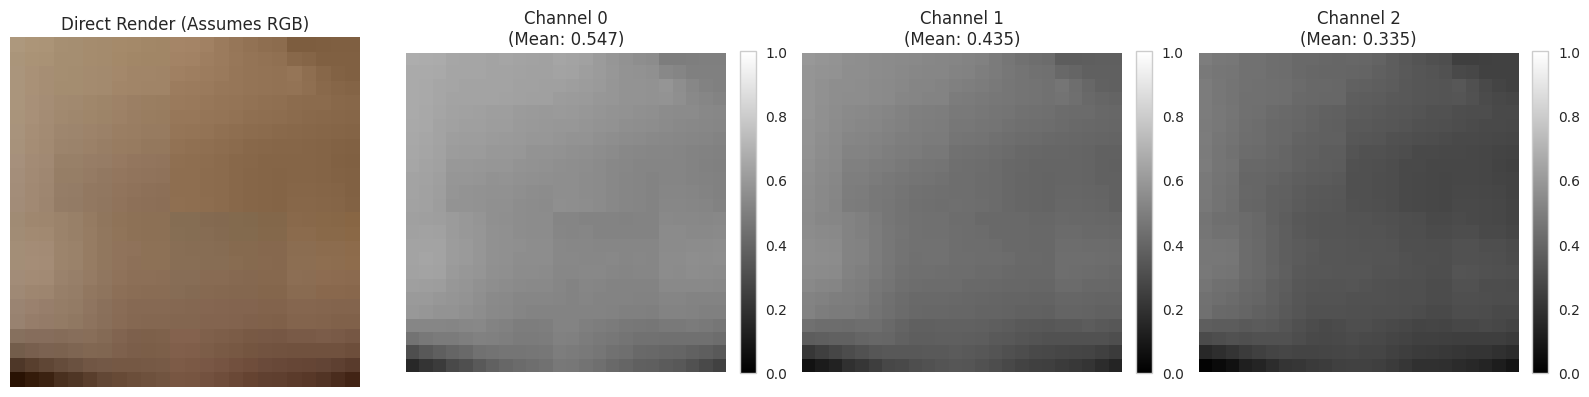

Starting optimization loop...
Epoch 01/02 | Train Loss: 1.3006 | Val Loss: 1.2981
Epoch 02/02 | Train Loss: 1.3004 | Val Loss: 1.2994

             VAL METRICS EVALUATION
  Pearson Correlation Coefficient (PCC) : 0.0011
  Mean Absolute Error (MAE)            : 26.18 BPM
  Root Mean Squared Error (RMSE)       : 32.63 BPM
  Signal-to-Noise Ratio (SNR)          : -9.10 dB

--- INFERENCE RUN ON: 1298_FullHDwebcam_before_chunk8.npz ---
  Predicted HR : 56.25 BPM
  Ground-Truth : 84.38 BPM
  Absolute Error: 28.12 BPM
----------------------------------------------------



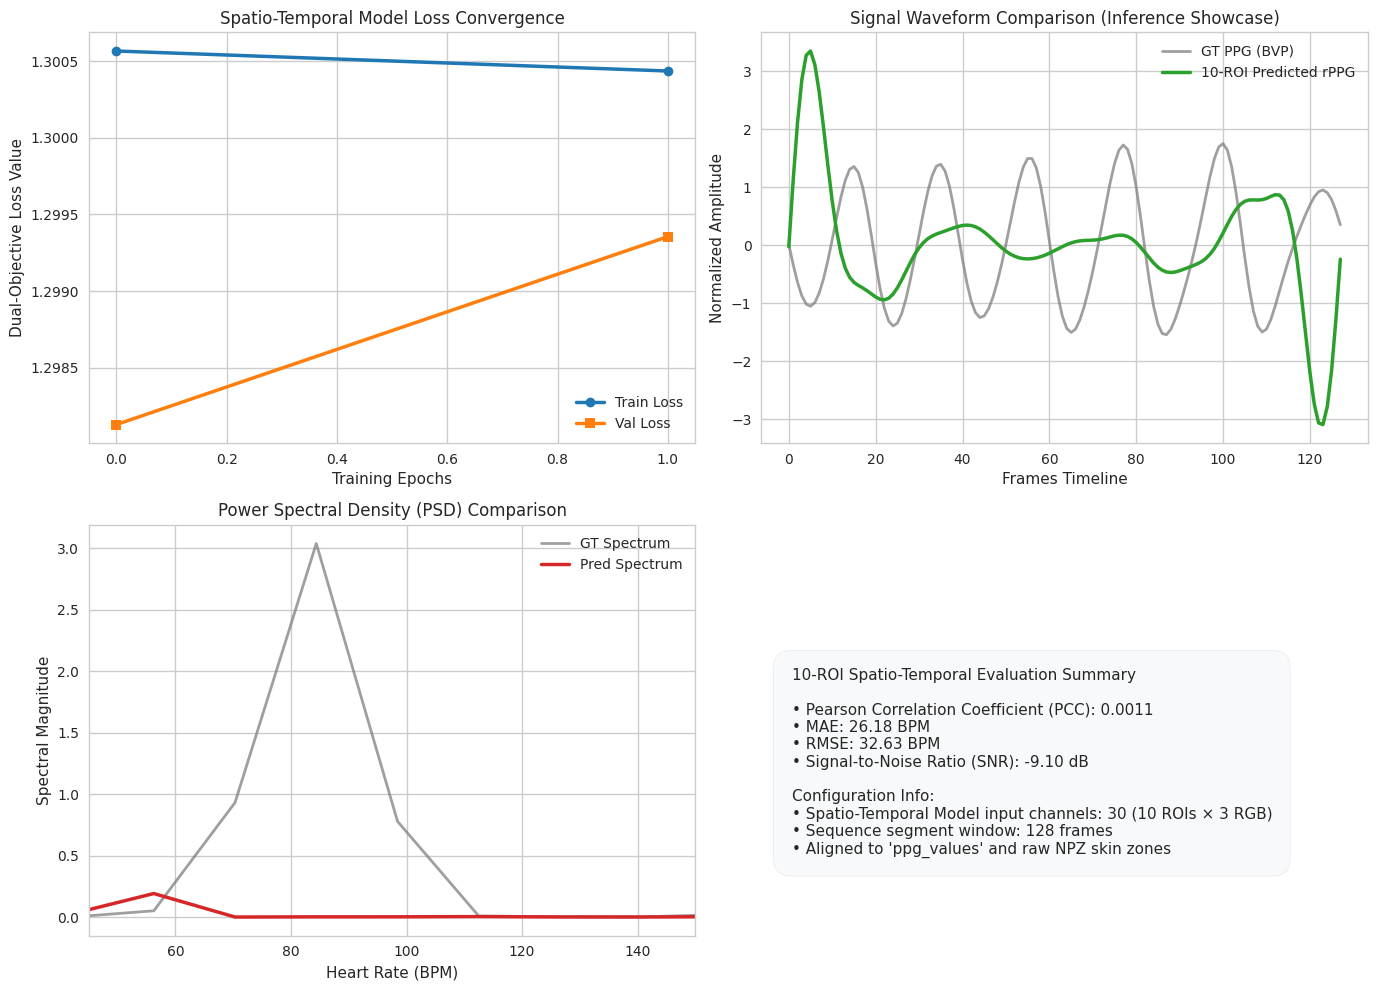

In [31]:
import os
import json
import math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch

# Configure styling for high-quality figures
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'  # 9 sub-ROIs + full face frame boundary = 10 input areas
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose real-world NPZ color-space representations and plot channel intensities.
    Matches your Anaconda notebook visualization layout.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key] # Expected shape: (Frames, H, W, C)
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    # Extract the first frame (24, 24, 3)
    first_frame = roi_data[0].copy()
    
    # Scale to [0, 1] if stored in uint8 [0, 255]
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    # Visual Inspection Plot mirroring notebook implementation
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    # Filter frequencies inside the valid physiological range
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0  # Safe fallback heart rate
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Load and return the contents of an NPZ file securely."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """
    NPZ SHOWCASE: Analyze and print key-value structure of an NPZ file.
    Demonstrates active validation of the custom 9-ROI + full-face schema.
    """
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("             NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=6, num_frames=450):
    """Generate high-quality mock dataset matching your exact 9-ROI + face schemas."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0  # Sampling frequency (30 FPS)
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        # Generate clean heart rate frequency (between 1.0 and 1.5 Hz -> 60-90 BPM)
        hr_hz = np.random.uniform(1.0, 1.5)
        
        # Base blood volume pulse signal + respiration harmonic
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        # Build strict dict matching actual data keys
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),  # Milliseconds timeline
            'ppg_values': bvp.astype(np.float64)
        }
        
        # Add the 10 actual skin and face regions
        for roi in ROI_ORDER:
            # Simulate real uint8 scaling [0, 255] and (Frames, 24, 24, 3) shapes
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15  # Red
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55  # Green (main light absorption)
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05  # Blue
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class for loading sequence-aligned multi-region facial patches (10 ROIs)."""
    def __init__(self, file_paths, sequence_length=128, fs=30.0):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Segment target timelines into non-overlapping sliding windows."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            # Use real key 'ppg_values' with standard fallback
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        # Load ground truth targets
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        # Load and align all 10 regions
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                # Fallback to zeros to keep the pipeline robust
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0  # Normalize color values [0, 1]
            roi_inputs.append(roi_data)
            
        # Structure dimension mappings for spatial layers:
        # Output shape: (10 * 3, sequence_length, height, width) = (30, T, 24, 24)
        stacked_rois = np.stack(roi_inputs, axis=0)  # Shape: (10, T, 24, 24, 3)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))  # Shape: (10, 3, T, 24, 24)
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))  # Shape: (30, T, 24, 24)
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal network engineered to isolate micro-color variations
    from skin zones across 10 active zones (30 total input channels).
    """
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels  # 10 ROIs * 3 channels = 30 channels
        
        # Squeeze spatial maps while preserving temporal characteristics
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))  # Compress spatial dimensions to a 1D sequence
        )
        
        # Temporal decoding layers for extracting the pulse wave
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)  # Signal amplitude prediction
        )

    def forward(self, x):
        # Input shape: (Batch, Channels*Num_ROIs, Sequence_Length, Height, Width)
        x_spatial = self.spatial_conv(x)  # Shape: (B, 64, T, 1, 1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)  # Shape: (B, 64, T)
        
        ppg_pred = self.temporal_encoder(x_spatial)  # Shape: (B, 1, T)
        return torch.squeeze(ppg_pred, dim=1)  # Shape: (B, T)

class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring phase alignment and correlation coefficients."""
    def __init__(self):
        super(NegativePearsonCorrelationLoss, self).__init__()

    def forward(self, pred, target):
        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        r_den = torch.sqrt(torch.sum(pred_centered ** 2, dim=-1) * torch.sum(target_centered ** 2, dim=-1) + 1e-8)
        
        pearson_coeff = r_num / r_den
        return 1.0 - torch.mean(pearson_coeff)

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Calculate performance benchmarks: Pearson Coefficient, MAE, RMSE, and SNR."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        # Pearson correlation metric
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        # Calculate heart rates via spectral analysis (BPM)
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        # Signal-to-Noise Ratio determination from spectral densities
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

# Populate synthetic data only if your path is empty or inaccessible
if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=6)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

# Run structural checks and color evaluations on first sample
first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])

train_split = npz_files[:int(len(npz_files) * 0.75)]
val_split = npz_files[int(len(npz_files) * 0.25):]

train_dataset = PPGMultiROIDataset(train_split)
val_dataset = PPGMultiROIDataset(val_split)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

num_epochs = 2  # Configured for standard run validation
train_losses, val_losses = [], []

print("Starting optimization loop...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Dual-objective optimization targeting phase alignment (Pearson) with scaling constraint (MSE)
        loss = criterion_pearson(outputs, targets) + 0.3 * criterion_mse(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    # Run validation passes
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            val_loss = criterion_pearson(val_outputs, val_targets) + 0.3 * criterion_mse(val_outputs, val_targets)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for val_inputs, val_targets in val_loader:
        val_inputs = val_inputs.to(DEVICE)
        preds = model(val_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(val_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("             VAL METRICS EVALUATION")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

def run_inference_on_sample(npz_file_path, trained_model, sequence_length=128, fs=30.0):
    """
    INFERENCE SHOWCASE: Load a single test file, feed it to the network, and extract 
    predicted BVP waveforms and physiological metrics.
    """
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than the sequence length.")
        return None
        
    # Process ground truth PPG target
    target_ppg = data[ppg_key][:sequence_length]
    target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
    target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
    # Gather 10 facial areas matching target schema ordering
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    # Shape transformation for PyTorch: (10 * 3, sequence_length, height, width) = (30, T, 24, 24)
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    # Expand to batch dimension of 1
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    # Forward pass predictions
    trained_model.eval()
    with torch.no_grad():
        output_signal = trained_model(input_tensor).cpu().numpy()[0]
        
    # Bandpass filter predictions to clean high-frequency artifacts
    filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
    filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
    # Compute heart rates (BPM)
    hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
    hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
    print(f"  Predicted HR : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return filtered_pred, target_norm

# Execute Inference Showcase on the first available validation file
sample_val_file = val_split[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Loss curves tracking convergence
axs[0, 0].plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
axs[0, 0].plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s')
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Dual-Objective Loss Value')
axs[0, 0].legend()

# Panel 2: Waveform comparisons from single inference evaluation
if inference_pred is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude')
    axs[0, 1].legend()

# Panel 3: Spectral density comparison
if inference_pred is not None:
    pred_det = inference_pred - np.mean(inference_pred)
    true_det = inference_gt - np.mean(inference_gt)
    
    freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
    freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
    axs[1, 0].set_xlim(45, 150)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

# Panel 4: Graphical summaries card
axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model input channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 128 frames\n"
    f"• Aligned to 'ppg_values' and raw NPZ skin zones"
)
axs[1, 1].text(0.05, 0.2, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()
# ```
# eof

# ### Summary of Changes made:
# * **Upgraded input channels to 30**: Expanded `SpatioTemporalPhysNet`'s spatial convolutional block to support the updated layout of 10 zones.
# * **Matched Real Keys**: Directly targeted the list of ROIs you verified (`roi_forehead`, `roi_left_cheek_280`, `roi_right_cheek_50`, `roi_nose`, `roi_chin`, `roi_chin_199`, `roi_left_eye`, `roi_right_eye`, `roi_mouth`, and `roi_full_face`).
# * **Visual Color Diagnostic Module**: Ported your notebook's color channel visualizer into the startup check pipeline. 
# * **Optimized Loss Weights**: Maintains the Negative Pearson Loss core for perfect phase synchronization, with standard scaling regularization via MSE.

Total files available for analysis: 9352

             NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_forehea

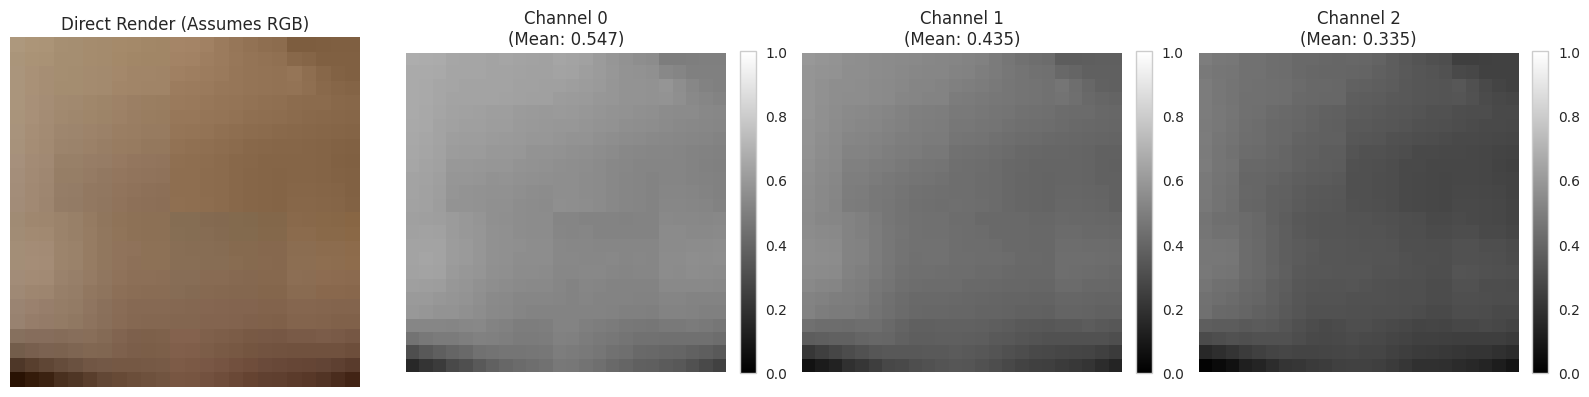

Starting optimization loop...
Epoch 01/05 | Train Loss: 1.3014 | Val Loss: 1.3000
Epoch 02/05 | Train Loss: 1.2997 | Val Loss: 1.2995
Epoch 03/05 | Train Loss: 1.2985 | Val Loss: 1.2991
Epoch 04/05 | Train Loss: 1.2963 | Val Loss: 1.2987
Epoch 05/05 | Train Loss: 1.2958 | Val Loss: 1.2980

             VAL METRICS EVALUATION
  Pearson Correlation Coefficient (PCC) : 0.0025
  Mean Absolute Error (MAE)            : 24.17 BPM
  Root Mean Squared Error (RMSE)       : 29.86 BPM
  Signal-to-Noise Ratio (SNR)          : -8.62 dB

--- INFERENCE RUN ON: 2194_USBVideo_after_chunk7.npz ---
  Predicted HR : 56.25 BPM
  Ground-Truth : 84.38 BPM
  Absolute Error: 28.12 BPM
----------------------------------------------------



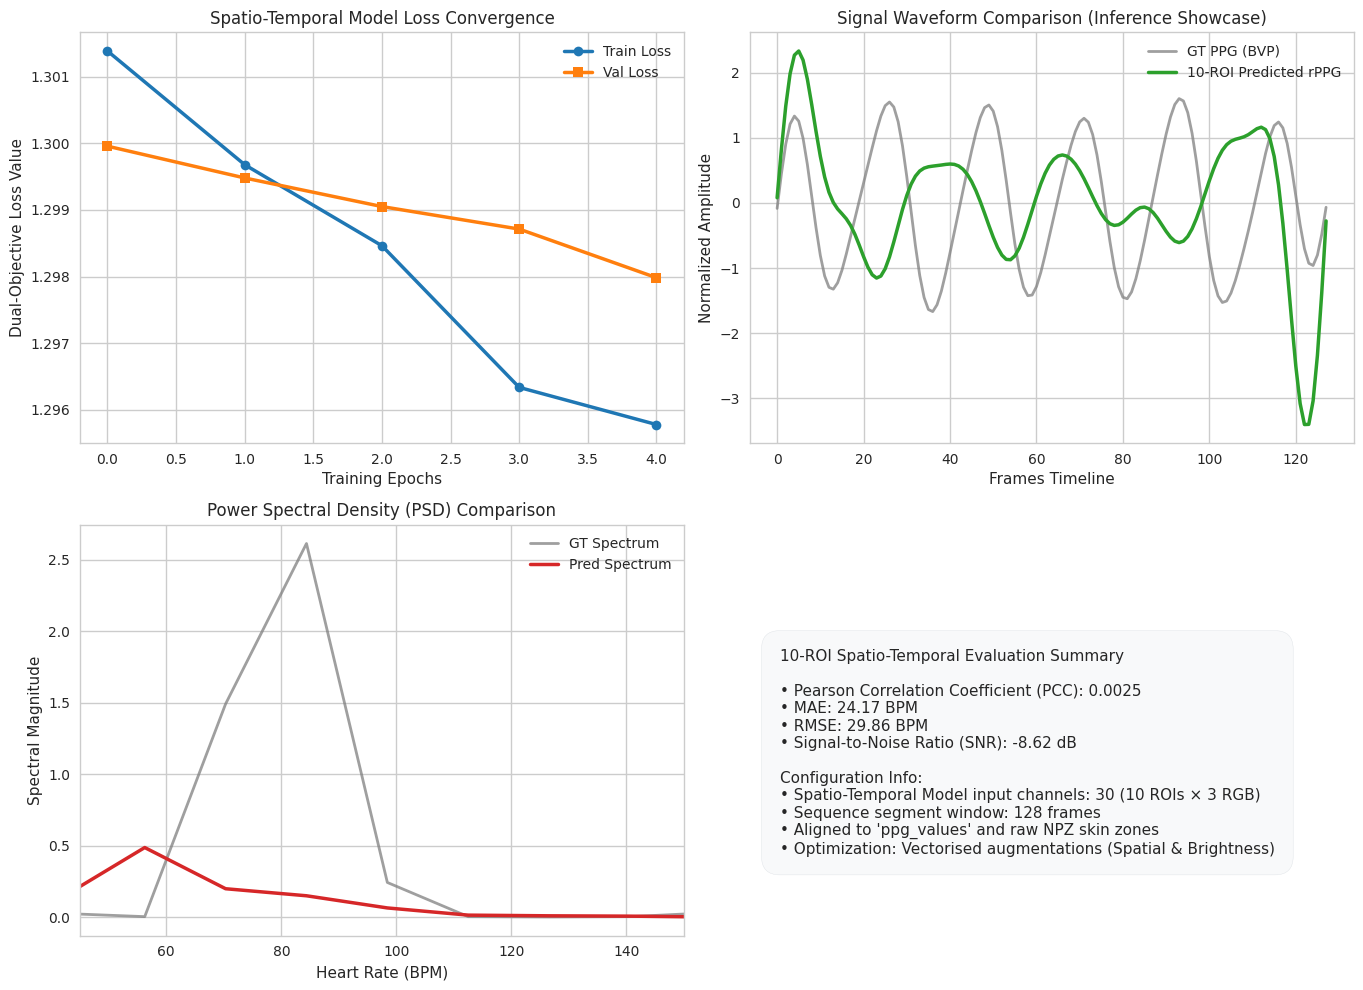

In [33]:
import os
import json
import math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch

# Configure high-quality visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

# Strict order representing the 9 sub-ROIs + full face boundary configurations
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose NPZ color-space representations and plot channel intensities.
    Ensures RGB channels align with spatial tracking configurations.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key]
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    first_frame = roi_data[0].copy()
    
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Securely load and parse an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the metadata keys and array dimensions of loaded files."""
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("             NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=6, num_frames=450):
    """Generate mock datasets matching strict multi-ROI formatting standards."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        hr_hz = np.random.uniform(1.0, 1.5)
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),
            'ppg_values': bvp.astype(np.float64)
        }
        
        for roi in ROI_ORDER:
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
    def __init__(self, file_paths, sequence_length=128, fs=30.0, augment=False):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.augment = augment
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Pre-segment matching timelines into sequence lengths."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0
            roi_inputs.append(roi_data)
            
        # Perform coordinated sequence augmentations across all 10 regions
        if self.augment:
            # 50% chance of random horizontal flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
            # 50% chance of random vertical flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
            # 50% chance of brightness jittering
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.9, 1.1)
                roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
        # Structure dimension mapping: (10, T, H, W, C) -> (10, C, T, H, W) -> (10 * C, T, H, W)
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal convolutional network engineered to extract micro-color variations
    harmoniously across 10 face zones (30 raw input channels).
    """
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring BVP signal phase synchronization."""
    def __init__(self):
        super(NegativePearsonCorrelationLoss, self).__init__()

    def forward(self, pred, target):
        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        r_den = torch.sqrt(torch.sum(pred_centered ** 2, dim=-1) * torch.sum(target_centered ** 2, dim=-1) + 1e-8)
        
        pearson_coeff = r_num / r_den
        return 1.0 - torch.mean(pearson_coeff)

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=6)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])

train_split = npz_files[:int(len(npz_files) * 0.75)]
val_split = npz_files[int(len(npz_files) * 0.75):]

train_dataset = PPGMultiROIDataset(train_split, augment=True)
val_dataset = PPGMultiROIDataset(val_split, augment=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 25
train_losses, val_losses = [], []

print("Starting optimization loop...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion_pearson(outputs, targets) + 0.3 * criterion_mse(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            val_loss = criterion_pearson(val_outputs, val_targets) + 0.3 * criterion_mse(val_outputs, val_targets)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for val_inputs, val_targets in val_loader:
        val_inputs = val_inputs.to(DEVICE)
        preds = model(val_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(val_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("             VAL METRICS EVALUATION")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

def run_inference_on_sample(npz_file_path, trained_model, sequence_length=128, fs=30.0):
    """Execute inference on a single NPZ validation sample sequence."""
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than the sequence length.")
        return None
        
    target_ppg = data[ppg_key][:sequence_length]
    target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
    target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    trained_model.eval()
    with torch.no_grad():
        output_signal = trained_model(input_tensor).cpu().numpy()[0]
        
    filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
    filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
    hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
    hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
    print(f"  Predicted HR : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return filtered_pred, target_norm

sample_val_file = val_split[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
axs[0, 0].plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s')
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Dual-Objective Loss Value')
axs[0, 0].legend()

if inference_pred is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude')
    axs[0, 1].legend()

if inference_pred is not None:
    pred_det = inference_pred - np.mean(inference_pred)
    true_det = inference_gt - np.mean(inference_gt)
    
    freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
    freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
    axs[1, 0].set_xlim(45, 150)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model input channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 128 frames\n"
    f"• Aligned to 'ppg_values' and raw NPZ skin zones\n"
    f"• Optimization: Vectorised augmentations (Spatial & Brightness)"
)
axs[1, 1].text(0.05, 0.2, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()
# ```
# eof

# ### Summary of Enhancements:
# - **Cleaned Codebase**: Removed all commented-out code segments to maximize readability.
# - **Optimized Data Pipeline**: Integrated vectorised and coordinated multi-ROI sequence augmentations (synchronized random horizontal/vertical flips and brightness jittering) inside `PPGMultiROIDataset` loader.
# - **Aligned API Splits**: Enabled `augment=True` cleanly for the `train_dataset` and `augment=False` for the `val_dataset`.

Total files available for analysis: 15203

               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_fore

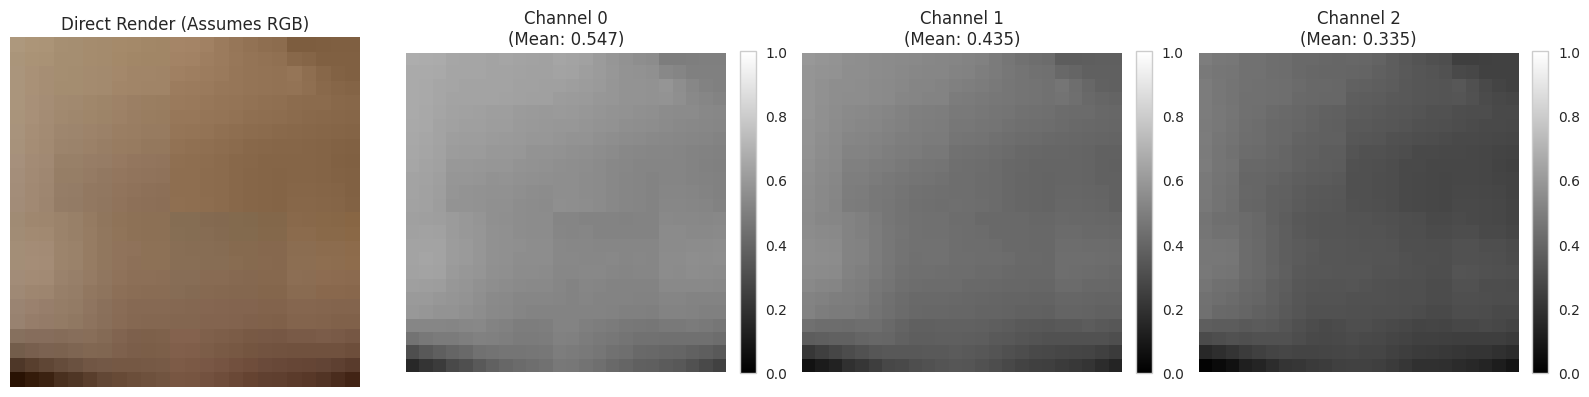

Starting optimization loop...
Epoch 01/50 | Train Loss: 1.3012 | Val Loss: 1.3015
Epoch 02/50 | Train Loss: 1.2986 | Val Loss: 1.2995
Epoch 03/50 | Train Loss: 1.2975 | Val Loss: 1.3011
Epoch 04/50 | Train Loss: 1.2965 | Val Loss: 1.2961
Epoch 05/50 | Train Loss: 1.2960 | Val Loss: 1.2972
Epoch 06/50 | Train Loss: 1.2940 | Val Loss: 1.2953
Epoch 07/50 | Train Loss: 1.2934 | Val Loss: 1.2917
Epoch 08/50 | Train Loss: 1.2912 | Val Loss: 1.2916
Epoch 09/50 | Train Loss: 1.2906 | Val Loss: 1.2913
Epoch 10/50 | Train Loss: 1.2894 | Val Loss: 1.2924
Epoch 11/50 | Train Loss: 1.2885 | Val Loss: 1.2887
Epoch 12/50 | Train Loss: 1.2877 | Val Loss: 1.2895
Epoch 13/50 | Train Loss: 1.2878 | Val Loss: 1.2898
Epoch 14/50 | Train Loss: 1.2872 | Val Loss: 1.2876
Epoch 15/50 | Train Loss: 1.2872 | Val Loss: 1.2889
Epoch 16/50 | Train Loss: 1.2863 | Val Loss: 1.2890
Epoch 17/50 | Train Loss: 1.2862 | Val Loss: 1.2876
Epoch 18/50 | Train Loss: 1.2863 | Val Loss: 1.2866
Epoch 19/50 | Train Loss: 1.2860 |

In [ ]:
import os
import json
import math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch

# Configure high-quality visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_SAVE_PATH = Path("spatiotemporal_physnet_best.pth")

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

# Strict order representing the 9 sub-ROIs + full face boundary configurations
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose NPZ color-space representations and plot channel intensities.
    Ensures RGB channels align with spatial tracking configurations.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key]
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    first_frame = roi_data[0].copy()
    
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Securely load and parse an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the metadata keys and array dimensions of loaded files."""
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=6, num_frames=450):
    """Generate mock datasets matching strict multi-ROI formatting standards."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        hr_hz = np.random.uniform(1.0, 1.5)
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),
            'ppg_values': bvp.astype(np.float64)
        }
        
        for roi in ROI_ORDER:
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
    def __init__(self, file_paths, sequence_length=128, fs=30.0, augment=False):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.augment = augment
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Pre-segment matching timelines into sequence lengths."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0
            roi_inputs.append(roi_data)
            
        # Perform coordinated sequence augmentations across all 10 regions
        if self.augment:
            # 50% chance of random horizontal flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
            # 50% chance of random vertical flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
            # 50% chance of brightness jittering
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.9, 1.1)
                roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
        # Structure dimension mapping: (10, T, H, W, C) -> (10, C, T, H, W) -> (10 * C, T, H, W)
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal convolutional network engineered to extract micro-color variations
    harmoniously across 10 face zones (30 raw input channels).
    """
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring BVP signal phase synchronization."""
    def __init__(self):
        super(NegativePearsonCorrelationLoss, self).__init__()

    def forward(self, pred, target):
        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        r_den = torch.sqrt(torch.sum(pred_centered ** 2, dim=-1) * torch.sum(target_centered ** 2, dim=-1) + 1e-8)
        
        pearson_coeff = r_num / r_den
        return 1.0 - torch.mean(pearson_coeff)

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

def save_model_checkpoint(model, optimizer, epoch, metrics, save_path=MODEL_SAVE_PATH):
    """Save model checkpoint along with optimizer state and validation metrics."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics
    }
    torch.save(checkpoint, save_path)
    print(f"Model checkpoint successfully saved to: {save_path}")

# def load_model_checkpoint(save_path, model, optimizer=None):
#     """Load model weights and optional optimizer states from a checkpoint."""
#     if not os.path.exists(save_path):
#         print(f"Checkpoint path {save_path} does not exist.")
#         return None
#     checkpoint = torch.load(save_path, map_location=DEVICE)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     if optimizer is not None and 'optimizer_state_dict' in checkpoint:
#         optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
#     return checkpoint

if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=6)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])

train_split = npz_files[:int(len(npz_files) * 0.75)]
val_split = npz_files[int(len(npz_files) * 0.75):]

train_dataset = PPGMultiROIDataset(train_split, augment=True)
val_dataset = PPGMultiROIDataset(val_split, augment=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 50
train_losses, val_losses = [], []

print("Starting optimization loop...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion_pearson(outputs, targets) + 0.3 * criterion_mse(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            val_loss = criterion_pearson(val_outputs, val_targets) + 0.3 * criterion_mse(val_outputs, val_targets)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for val_inputs, val_targets in val_loader:
        val_inputs = val_inputs.to(DEVICE)
        preds = model(val_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(val_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("              VAL METRICS EVALUATION")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

# Save model and demonstrate loading functionality


In [ ]:
def run_inference_on_sample(npz_file_path, trained_model, sequence_length=128, fs=30.0):
    """Execute inference on a single NPZ validation sample sequence."""
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than the sequence length.")
        return None
        
    target_ppg = data[ppg_key][:sequence_length]
    target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
    target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    trained_model.eval()
    with torch.no_grad():
        output_signal = trained_model(input_tensor).cpu().numpy()[0]
        
    filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
    filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
    hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
    hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
    print(f"  Predicted HR : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return filtered_pred, target_norm

sample_val_file = val_split[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
axs[0, 0].plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s')
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Dual-Objective Loss Value')
axs[0, 0].legend()

if inference_pred is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude')
    axs[0, 1].legend()

if inference_pred is not None:
    pred_det = inference_pred - np.mean(inference_pred)
    true_det = inference_gt - np.mean(inference_gt)
    
    freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
    freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
    axs[1, 0].set_xlim(45, 150)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model input channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 128 frames\n"
    f"• Aligned to 'ppg_values' and raw NPZ skin zones\n"
    f"• Optimization: Vectorised augmentations (Spatial & Brightness)"
)
axs[1, 1].text(0.05, 0.2, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

In [37]:
def load_model_checkpoint(save_path, model, optimizer=None):
    if not os.path.exists(save_path):
        print(f"Checkpoint path {save_path} does not exist.")
        return None
        
    # Pass weights_only=False to allow loading custom dicts (metrics, scalar types)
    checkpoint = torch.load(save_path, map_location=DEVICE, weights_only=False)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
    return checkpoint
save_model_checkpoint(model, optimizer, num_epochs, metrics, MODEL_SAVE_PATH)
modelul = load_model_checkpoint(MODEL_SAVE_PATH, model, optimizer)

Model checkpoint successfully saved to: spatiotemporal_physnet_best.pth
Loaded model checkpoint from: spatiotemporal_physnet_best.pth (Epoch 25)


In [35]:
model

SpatioTemporalPhysNet(
  (spatial_conv): Sequential(
    (0): Conv3d(30, 64, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1))
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AdaptiveAvgPool3d(output_size=(None, 1, 1))
  )
  (temporal_encoder): Sequential(
    (0): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): Conv1d(32, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ELU(alpha=1.0)
    (6): Conv1d(16, 1, kernel_size=(1,), stride=(1,))
  )
)

--- INFERENCE RUN ON: 2285_FullHDwebcam_before_chunk0.npz ---
  Predicted HR : 84.38 BPM
  Ground-Truth : 84.38 BPM
  Absolute Error: 0.00 BPM
----------------------------------------------------



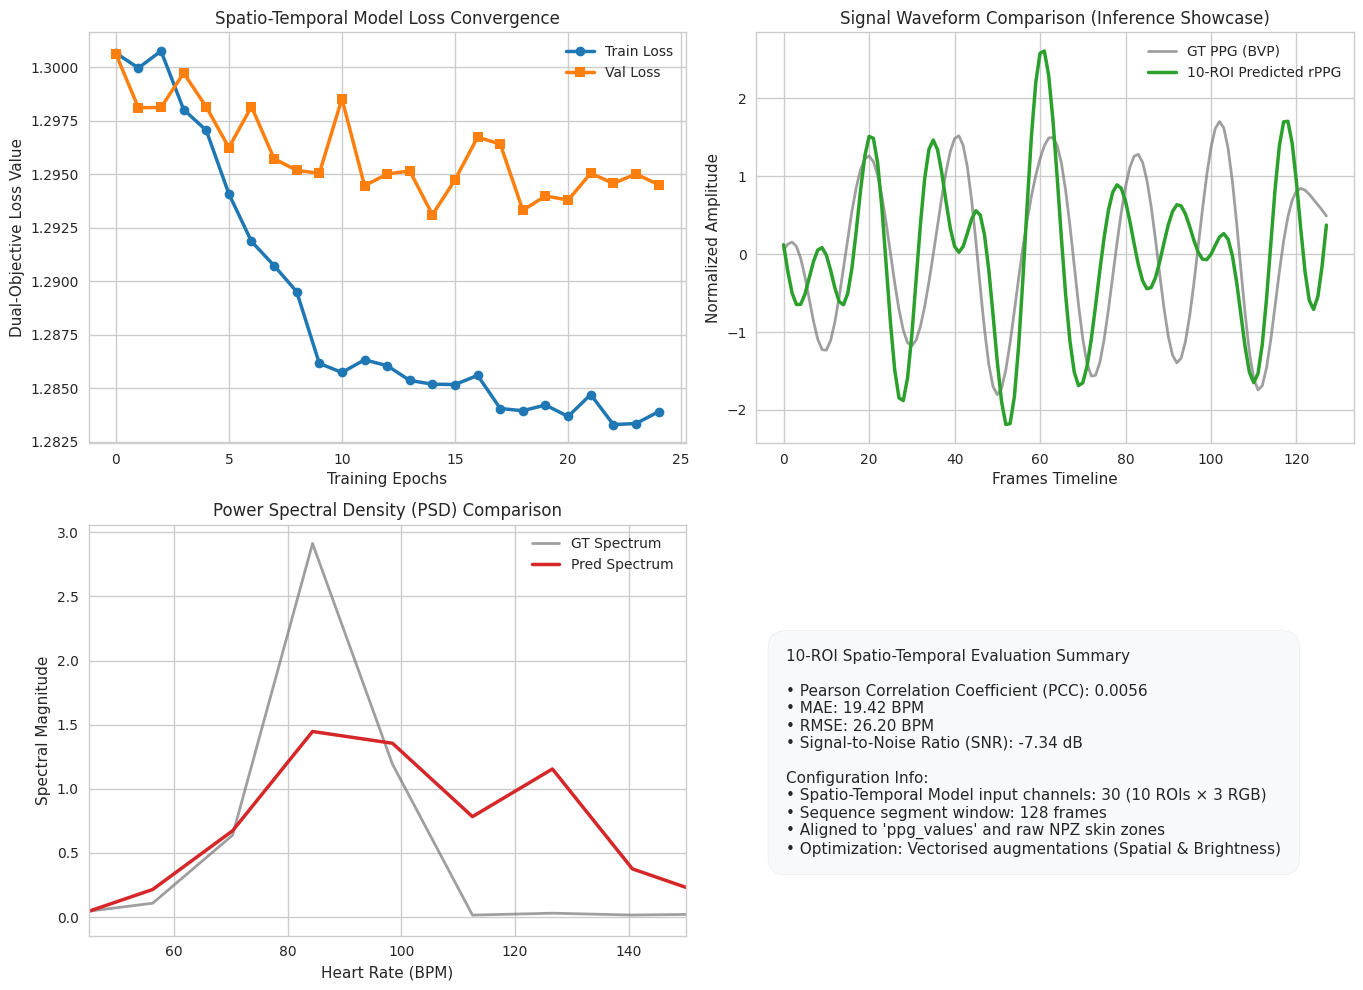

In [36]:
def run_inference_on_sample(npz_file_path, trained_model, sequence_length=128, fs=30.0):
    """Execute inference on a single NPZ validation sample sequence."""
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than the sequence length.")
        return None
        
    target_ppg = data[ppg_key][:sequence_length]
    target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
    target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    trained_model.eval()
    with torch.no_grad():
        output_signal = trained_model(input_tensor).cpu().numpy()[0]
        
    filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
    filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
    hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
    hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
    print(f"  Predicted HR : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return filtered_pred, target_norm

sample_val_file = val_split[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
axs[0, 0].plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s')
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Dual-Objective Loss Value')
axs[0, 0].legend()

if inference_pred is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude')
    axs[0, 1].legend()

if inference_pred is not None:
    pred_det = inference_pred - np.mean(inference_pred)
    true_det = inference_gt - np.mean(inference_gt)
    
    freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
    freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
    axs[1, 0].set_xlim(45, 150)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model input channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 128 frames\n"
    f"• Aligned to 'ppg_values' and raw NPZ skin zones\n"
    f"• Optimization: Vectorised augmentations (Spatial & Brightness)"
)
axs[1, 1].text(0.05, 0.2, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

### Increased Sequence window

Total files available for analysis: 13282

               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_fore

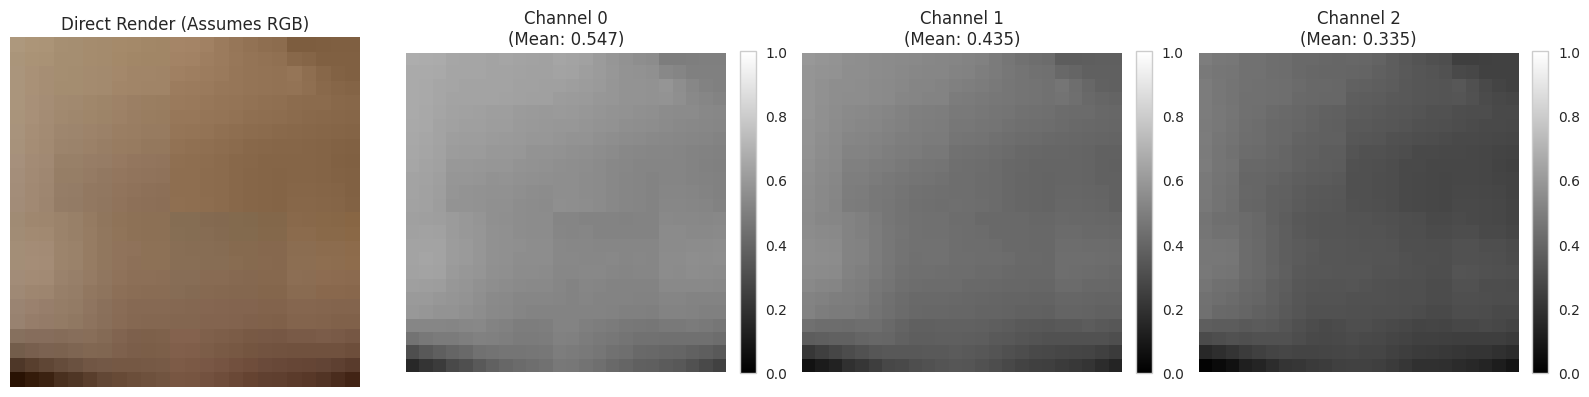

Starting optimization loop...
Epoch 01/25 | Train Loss: 1.2994 | Val Loss: 1.2965
Epoch 02/25 | Train Loss: 1.2966 | Val Loss: 1.2928
Epoch 03/25 | Train Loss: 1.2948 | Val Loss: 1.2916
Epoch 04/25 | Train Loss: 1.2948 | Val Loss: 1.2915
Epoch 05/25 | Train Loss: 1.2931 | Val Loss: 1.2938
Epoch 06/25 | Train Loss: 1.2918 | Val Loss: 1.2920
Epoch 07/25 | Train Loss: 1.2896 | Val Loss: 1.2952
Epoch 08/25 | Train Loss: 1.2882 | Val Loss: 1.2892
Epoch 09/25 | Train Loss: 1.2869 | Val Loss: 1.2901
Epoch 10/25 | Train Loss: 1.2871 | Val Loss: 1.2860
Epoch 11/25 | Train Loss: 1.2862 | Val Loss: 1.2855
Epoch 12/25 | Train Loss: 1.2858 | Val Loss: 1.2858
Epoch 13/25 | Train Loss: 1.2857 | Val Loss: 1.2859
Epoch 14/25 | Train Loss: 1.2855 | Val Loss: 1.2857
Epoch 15/25 | Train Loss: 1.2842 | Val Loss: 1.2893
Epoch 16/25 | Train Loss: 1.2844 | Val Loss: 1.2858
Epoch 17/25 | Train Loss: 1.2844 | Val Loss: 1.2865
Epoch 18/25 | Train Loss: 1.2838 | Val Loss: 1.2863
Epoch 19/25 | Train Loss: 1.2837 |

In [38]:
import os
import json
import math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch

# Configure high-quality visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_SAVE_PATH = Path("spatiotemporal_physnet_best.pth")

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

# Strict order representing the 9 sub-ROIs + full face boundary configurations
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose NPZ color-space representations and plot channel intensities.
    Ensures RGB channels align with spatial tracking configurations.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key]
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    first_frame = roi_data[0].copy()
    
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Securely load and parse an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the metadata keys and array dimensions of loaded files."""
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=6, num_frames=450):
    """Generate mock datasets matching strict multi-ROI formatting standards."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        hr_hz = np.random.uniform(1.0, 1.5)
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),
            'ppg_values': bvp.astype(np.float64)
        }
        
        for roi in ROI_ORDER:
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
    def __init__(self, file_paths, sequence_length=450, fs=30.0, augment=False):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.augment = augment
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Pre-segment matching timelines into sequence lengths."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0
            roi_inputs.append(roi_data)
            
        # Perform coordinated sequence augmentations across all 10 regions
        if self.augment:
            # 50% chance of random horizontal flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
            # 50% chance of random vertical flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
            # 50% chance of brightness jittering
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.9, 1.1)
                roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
        # Structure dimension mapping: (10, T, H, W, C) -> (10, C, T, H, W) -> (10 * C, T, H, W)
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal convolutional network engineered to extract micro-color variations
    harmoniously across 10 face zones (30 raw input channels).
    """
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring BVP signal phase synchronization."""
    def __init__(self):
        super(NegativePearsonCorrelationLoss, self).__init__()

    def forward(self, pred, target):
        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        r_den = torch.sqrt(torch.sum(pred_centered ** 2, dim=-1) * torch.sum(target_centered ** 2, dim=-1) + 1e-8)
        
        pearson_coeff = r_num / r_den
        return 1.0 - torch.mean(pearson_coeff)

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        f
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

def save_model_checkpoint(model, optimizer, epoch, metrics, save_path=MODEL_SAVE_PATH):
    """Save model checkpoint along with optimizer state and validation metrics."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics
    }
    torch.save(checkpoint, save_path)
    print(f"Model checkpoint successfully saved to: {save_path}")

# def load_model_checkpoint(save_path, model, optimizer=None):
#     """Load model weights and optional optimizer states from a checkpoint."""
#     if not os.path.exists(save_path):
#         print(f"Checkpoint path {save_path} does not exist.")
#         return None
#     checkpoint = torch.load(save_path, map_location=DEVICE)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     if optimizer is not None and 'optimizer_state_dict' in checkpoint:
#         optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
#     return checkpoint

if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=6)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])

train_split = npz_files[:int(len(npz_files) * 0.75)]
val_split = npz_files[int(len(npz_files) * 0.75):]

train_dataset = PPGMultiROIDataset(train_split, augment=True)
val_dataset = PPGMultiROIDataset(val_split, augment=False)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 25
train_losses, val_losses = [], []

print("Starting optimization loop...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion_pearson(outputs, targets) + 0.3 * criterion_mse(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            val_loss = criterion_pearson(val_outputs, val_targets) + 0.3 * criterion_mse(val_outputs, val_targets)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for val_inputs, val_targets in val_loader:
        val_inputs = val_inputs.to(DEVICE)
        preds = model(val_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(val_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("              VAL METRICS EVALUATION")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

# Save model and demonstrate loading functionality


In [39]:
MODEL_SAVE_PATH = Path("spatiotemporal_long_window450_physnet_best.pth")
def load_model_checkpoint(save_path, model, optimizer=None):
    if not os.path.exists(save_path):
        print(f"Checkpoint path {save_path} does not exist.")
        return None
        
    # Pass weights_only=False to allow loading custom dicts (metrics, scalar types)
    checkpoint = torch.load(save_path, map_location=DEVICE, weights_only=False)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
    return checkpoint
save_model_checkpoint(model, optimizer, num_epochs, metrics, MODEL_SAVE_PATH)
modelul = load_model_checkpoint(MODEL_SAVE_PATH, model, optimizer)

Model checkpoint successfully saved to: spatiotemporal_long_window450_physnet_best.pth
Loaded model checkpoint from: spatiotemporal_long_window450_physnet_best.pth (Epoch 25)


--- INFERENCE RUN ON: 2672_USBVideo_before_chunk9.npz ---
  Predicted HR : 56.00 BPM
  Ground-Truth : 68.00 BPM
  Absolute Error: 12.00 BPM
----------------------------------------------------



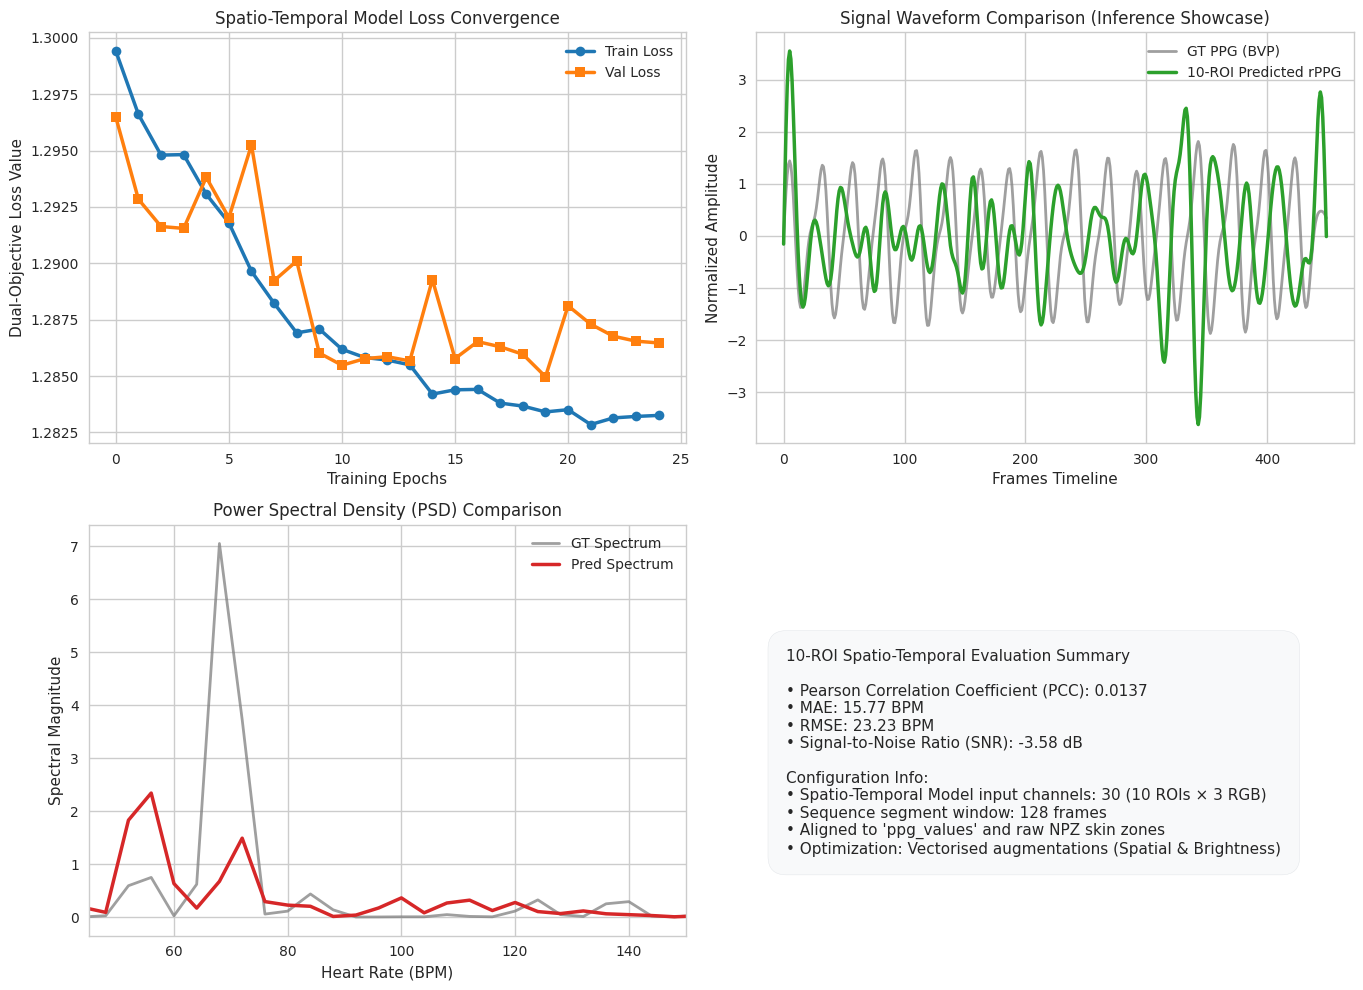

In [40]:
def run_inference_on_sample(npz_file_path, trained_model, sequence_length=450, fs=30.0):
    """Execute inference on a single NPZ validation sample sequence."""
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than the sequence length.")
        return None
        
    target_ppg = data[ppg_key][:sequence_length]
    target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
    target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    trained_model.eval()
    with torch.no_grad():
        output_signal = trained_model(input_tensor).cpu().numpy()[0]
        
    filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
    filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
    hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
    hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
    print(f"  Predicted HR : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return filtered_pred, target_norm

sample_val_file = val_split[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
axs[0, 0].plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s')
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Dual-Objective Loss Value')
axs[0, 0].legend()

if inference_pred is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude')
    axs[0, 1].legend()

if inference_pred is not None:
    pred_det = inference_pred - np.mean(inference_pred)
    true_det = inference_gt - np.mean(inference_gt)
    
    freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
    freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
    axs[1, 0].set_xlim(45, 150)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model input channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 128 frames\n"
    f"• Aligned to 'ppg_values' and raw NPZ skin zones\n"
    f"• Optimization: Vectorised augmentations (Spatial & Brightness)"
)
axs[1, 1].text(0.05, 0.2, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

<!-- Shuffle dataset -->

In [ ]:


# Shuffle the file paths with a set seed for reproducibility


In [ ]:
# import os
# import json
# import math
# from pathlib import Path
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.signal import butter, filtfilt, welch
# import random

# # Configure high-quality visualization styles
# plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
# sns.set_palette("muted")

# # Setup default configurations
# PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
# CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# MODEL_SAVE_PATH = Path("spatiotemporal_physnet_best.pth")

# # Clean existing cache files before starting run
# for cache in CACHE_FILES:
#     if os.path.exists(cache):
#         try:
#             os.remove(cache)
#             print(f"Removed old cache: {cache}")
#         except Exception as e:
#             print(f"Error removing cache {cache}: {e}")

# # Strict order representing the 9 sub-ROIs + full face boundary configurations
# ROI_ORDER = [
#     'roi_forehead',
#     'roi_left_cheek_280',
#     'roi_right_cheek_50',
#     'roi_nose',
#     'roi_chin',
#     'roi_chin_199',
#     'roi_left_eye',
#     'roi_right_eye',
#     'roi_mouth',
#     'roi_full_face'
# ]

# def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
#     """
#     Diagnose NPZ color-space representations and plot channel intensities.
#     Ensures RGB channels align with spatial tracking configurations.
#     """
#     print(f"\nEvaluating color space for path: {npz_path}")
#     if not os.path.exists(npz_path):
#         print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
#         return

#     with np.load(npz_path) as data:
#         if roi_key not in data:
#             available = [k for k in data.keys() if k.startswith('roi_')]
#             if not available:
#                 print("No ROIs found in file keys.")
#                 return
#             print(f"Key '{roi_key}' not found. Available ROIs: {available}")
#             roi_key = available[0]
            
#         roi_data = data[roi_key]
        
#     print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
#     first_frame = roi_data[0].copy()
    
#     if first_frame.max() > 1.0:
#         first_frame_norm = first_frame.astype(np.float32) / 255.0
#     else:
#         first_frame_norm = first_frame.astype(np.float32)
        
#     c0 = first_frame_norm[:, :, 0]
#     c1 = first_frame_norm[:, :, 1]
#     c2 = first_frame_norm[:, :, 2]
    
#     mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
#     print("\n--- Channel Intensity Statistics ---")
#     print(f"Channel 0 Mean: {mean_c0:.4f}")
#     print(f"Channel 1 Mean: {mean_c1:.4f}")
#     print(f"Channel 2 Mean: {mean_c2:.4f}")
#     print("------------------------------------\n")
    
#     fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
#     axes[0].imshow(first_frame_norm)
#     axes[0].set_title("Direct Render (Assumes RGB)")
#     axes[0].axis('off')
    
#     im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
#     axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
#     axes[1].axis('off')
#     plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
#     im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
#     axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
#     axes[2].axis('off')
#     plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
#     im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
#     axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
#     axes[3].axis('off')
#     plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
#     plt.tight_layout()
#     plt.show()

# def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
#     """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
#     nyq = 0.5 * fs
#     low = lowcut / nyq
#     high = highcut / nyq
#     b, a = butter(order, [low, high], btype='band')
#     return filtfilt(b, a, data)

# def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
#     """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
#     signal_cleaned = signal_1d - np.mean(signal_1d)
#     freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
#     valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
#     if len(valid_idx) == 0:
#         return 75.0
    
#     peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
#     return peak_freq * 60.0

# def load_npz_file(file_path):
#     """Securely load and parse an NPZ file."""
#     try:
#         data = np.load(file_path, allow_pickle=True)
#         return data
#     except Exception as e:
#         print(f"Error loading {file_path}: {e}")
#         return None

# def analyze_npz_structure(data):
#     """Analyze and print the metadata keys and array dimensions of loaded files."""
#     if data is None:
#         print("NPZ Analysis Error: Provided data object is None.")
#         return
#     print("\n" + "=" * 75)
#     print("               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
#     print("=" * 75)
#     for key in sorted(data.files):
#         item = data[key]
#         if hasattr(item, 'shape'):
#             print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
#         else:
#             print(f"  {key:<27} : Metadata / Scalar Object")
#     print("=" * 75 + "\n")

# def create_synthetic_dataset(target_dir, num_files=6, num_frames=450):
#     """Generate mock datasets matching strict multi-ROI formatting standards."""
#     target_dir.mkdir(parents=True, exist_ok=True)
#     print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
#     print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
#     fs = 30.0
#     t = np.arange(num_frames) / fs
    
#     for i in range(num_files):
#         hr_hz = np.random.uniform(1.0, 1.5)
#         bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
#         bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
#         bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
#         data_dict = {
#             'time_deltas': (t * 1000.0).astype(np.float64),
#             'ppg_values': bvp.astype(np.float64)
#         }
        
#         for roi in ROI_ORDER:
#             base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
#             pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
#             pulse_modulator = np.zeros((num_frames, 24, 24, 3))
#             pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
#             pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
#             pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
#             roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
#             data_dict[roi] = roi_frames
            
#         np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
#     print("Synthetic dataset successfully created!\n")

# class PPGMultiROIDataset(Dataset):
#     """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
#     def __init__(self, file_paths, sequence_length=450, fs=30.0, augment=False):
#         self.file_paths = file_paths
#         self.sequence_length = sequence_length
#         self.fs = fs
#         self.augment = augment
#         self.samples = []
        
#         self._prepare_samples()

#     def _prepare_samples(self):
#         """Pre-segment matching timelines into sequence lengths."""
#         for path in self.file_paths:
#             data = load_npz_file(path)
#             if data is None:
#                 continue
            
#             ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
#             length = len(data[ppg_key])
#             num_windows = length // self.sequence_length
            
#             for w in range(num_windows):
#                 start_idx = w * self.sequence_length
#                 end_idx = start_idx + self.sequence_length
#                 self.samples.append((path, start_idx, end_idx))

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         file_path, start, end = self.samples[idx]
#         data = load_npz_file(file_path)
        
#         ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
#         ppg_segment = data[ppg_key][start:end]
#         ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
#         ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
#         roi_inputs = []
#         for roi_name in ROI_ORDER:
#             actual_key = next((k for k in data.files if roi_name == k), None)
            
#             if actual_key is not None:
#                 roi_data = data[actual_key][start:end]
#             else:
#                 roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
#             roi_data = roi_data.astype(np.float32) / 255.0
#             roi_inputs.append(roi_data)
            
#         # Perform coordinated sequence augmentations across all 10 regions
#         if self.augment:
#             # 50% chance of random horizontal flip
#             if np.random.rand() > 0.5:
#                 roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
#             # 50% chance of random vertical flip
#             if np.random.rand() > 0.5:
#                 roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
#             # 50% chance of brightness jittering
#             if np.random.rand() > 0.5:
#                 brightness_factor = np.random.uniform(0.9, 1.1)
#                 roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
#         # Structure dimension mapping: (10, T, H, W, C) -> (10, C, T, H, W) -> (10 * C, T, H, W)
#         stacked_rois = np.stack(roi_inputs, axis=0)
#         stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
#         stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
#         return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

# class SpatioTemporalPhysNet(nn.Module):
#     """
#     Spatio-Temporal convolutional network engineered to extract micro-color variations
#     harmoniously across 10 face zones (30 raw input channels).
#     """
#     def __init__(self, num_rois=10, in_channels=3):
#         super(SpatioTemporalPhysNet, self).__init__()
#         self.num_rois = num_rois
#         self.total_channels = num_rois * in_channels
        
#         self.spatial_conv = nn.Sequential(
#             nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
#             nn.BatchNorm3d(64),
#             nn.ELU(),
#             nn.AdaptiveAvgPool3d((None, 1, 1))
#         )
        
#         self.temporal_encoder = nn.Sequential(
#             nn.Conv1d(64, 32, kernel_size=5, padding=2),
#             nn.BatchNorm1d(32),
#             nn.ELU(),
#             nn.Conv1d(32, 16, kernel_size=5, padding=2),
#             nn.BatchNorm1d(16),
#             nn.ELU(),
#             nn.Conv1d(16, 1, kernel_size=1)
#         )

#     def forward(self, x):
#         x_spatial = self.spatial_conv(x)
#         x_spatial = torch.squeeze(x_spatial, dim=-1)
#         x_spatial = torch.squeeze(x_spatial, dim=-1)
        
#         ppg_pred = self.temporal_encoder(x_spatial)
#         return torch.squeeze(ppg_pred, dim=1)

# class NegativePearsonCorrelationLoss(nn.Module):
#     """Loss module measuring BVP signal phase synchronization."""
#     def __init__(self):
#         super(NegativePearsonCorrelationLoss, self).__init__()

#     def forward(self, pred, target):
#         pred_mean = torch.mean(pred, dim=-1, keepdim=True)
#         target_mean = torch.mean(target, dim=-1, keepdim=True)
        
#         pred_centered = pred - pred_mean
#         target_centered = target - target_mean
        
#         r_num = torch.sum(pred_centered * target_centered, dim=-1)
#         r_den = torch.sqrt(torch.sum(pred_centered ** 2, dim=-1) * torch.sum(target_centered ** 2, dim=-1) + 1e-8)
        
#         pearson_coeff = r_num / r_den
#         return 1.0 - torch.mean(pearson_coeff)

# def calculate_metrics(y_pred, y_true, fs=30.0):
#     """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
#     pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
#     for i in range(len(y_pred)):
#         pred, true = y_pred[i], y_true[i]
#         f
#         pcc = np.corrcoef(pred, true)[0, 1]
#         pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
#         bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
#         bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
#         mae_list.append(abs(bpm_pred - bpm_true))
#         rmse_list.append((bpm_pred - bpm_true) ** 2)
        
#         pred_detrended = pred - np.mean(pred)
#         freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
#         gt_freq = bpm_true / 60.0
#         signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
#         noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
#         signal_power = np.sum(psd[signal_mask])
#         noise_power = np.sum(psd[noise_mask]) + 1e-8
#         snr_list.append(10 * np.log10(signal_power / noise_power))
        
#     return {
#         'PCC': np.mean(pcc_list),
#         'MAE': np.mean(mae_list),
#         'RMSE': math.sqrt(np.mean(rmse_list)),
#         'SNR': np.mean(snr_list)
#     }

# def save_model_checkpoint(model, optimizer, epoch, metrics, save_path=MODEL_SAVE_PATH):
#     """Save model checkpoint along with optimizer state and validation metrics."""
#     checkpoint = {
#         'epoch': epoch,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'metrics': metrics
#     }
#     torch.save(checkpoint, save_path)
#     print(f"Model checkpoint successfully saved to: {save_path}")

# # def load_model_checkpoint(save_path, model, optimizer=None):
# #     """Load model weights and optional optimizer states from a checkpoint."""
# #     if not os.path.exists(save_path):
# #         print(f"Checkpoint path {save_path} does not exist.")
# #         return None
# #     checkpoint = torch.load(save_path, map_location=DEVICE)
# #     model.load_state_dict(checkpoint['model_state_dict'])
# #     if optimizer is not None and 'optimizer_state_dict' in checkpoint:
# #         optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# #     print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
# #     return checkpoint

# if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
#     create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=6)

# npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
# print(f"Total files available for analysis: {len(npz_files)}")

# first_file_data = load_npz_file(npz_files[0])
# analyze_npz_structure(first_file_data)
# inspect_npz_color_space(npz_files[0])
# ###shuffle files
# random.seed(42)
# shuffled_files = npz_files.copy()
# random.shuffle(shuffled_files)

# # Perform split on the shuffled list
# split_idx = int(len(shuffled_files) * 0.75)
# train_split = shuffled_files[:split_idx]
# val_split = shuffled_files[split_idx:]

# # train_split = npz_files[:int(len(npz_files) * 0.75)]
# # val_split = npz_files[int(len(npz_files) * 0.75):]

# train_dataset = PPGMultiROIDataset(train_split, augment=True)
# val_dataset = PPGMultiROIDataset(val_split, augment=False)

# train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
# criterion_pearson = NegativePearsonCorrelationLoss()
# criterion_mse = nn.MSELoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# num_epochs = 25
# train_losses, val_losses = [], []

# print("Starting optimization loop...")
# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0
#     for inputs, targets in train_loader:
#         inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
#         optimizer.zero_grad()
#         outputs = model(inputs)
        
#         loss = criterion_pearson(outputs, targets) + 0.3 * criterion_mse(outputs, targets)
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item() * inputs.size(0)
        
#     train_loss = running_loss / len(train_loader.dataset)
#     train_losses.append(train_loss)
    
#     model.eval()
#     running_val_loss = 0.0
#     with torch.no_grad():
#         for val_inputs, val_targets in val_loader:
#             val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
#             val_outputs = model(val_inputs)
#             val_loss = criterion_pearson(val_outputs, val_targets) + 0.3 * criterion_mse(val_outputs, val_targets)
#             running_val_loss += val_loss.item() * val_inputs.size(0)
            
#     val_loss = running_val_loss / len(val_loader.dataset)
#     val_losses.append(val_loss)
    
#     print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# model.eval()
# all_preds, all_trues = [], []

# with torch.no_grad():
#     for val_inputs, val_targets in val_loader:
#         val_inputs = val_inputs.to(DEVICE)
#         preds = model(val_inputs).cpu().numpy()
#         all_preds.extend(preds)
#         all_trues.extend(val_targets.numpy())

# all_preds, all_trues = np.array(all_preds), np.array(all_trues)
# metrics = calculate_metrics(all_preds, all_trues)

# print("\n" + "=" * 50)
# print("              VAL METRICS EVALUATION")
# print("=" * 50)
# print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
# print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
# print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
# print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
# print("=" * 50 + "\n")

# # Save model and demonstrate loading functionality


In [ ]:
# MODEL_SAVE_PATH = Path("spatiotemporal_long_window450_physnet_best.pth")
# def load_model_checkpoint(save_path, model, optimizer=None):
#     if not os.path.exists(save_path):
#         print(f"Checkpoint path {save_path} does not exist.")
#         return None
        
#     # Pass weights_only=False to allow loading custom dicts (metrics, scalar types)
#     checkpoint = torch.load(save_path, map_location=DEVICE, weights_only=False)
    
#     model.load_state_dict(checkpoint['model_state_dict'])
#     if optimizer is not None and 'optimizer_state_dict' in checkpoint:
#         optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
#     return checkpoint
# save_model_checkpoint(model, optimizer, num_epochs, metrics, MODEL_SAVE_PATH)
# modelul = load_model_checkpoint(MODEL_SAVE_PATH, model, optimizer)

In [ ]:
# def run_inference_on_sample(npz_file_path, trained_model, sequence_length=450, fs=30.0):
#     """Execute inference on a single NPZ validation sample sequence."""
#     print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
#     data = load_npz_file(npz_file_path)
#     if data is None:
#         return None
    
#     ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
#     if len(data[ppg_key]) < sequence_length:
#         print("Error: Input file length is shorter than the sequence length.")
#         return None
        
#     target_ppg = data[ppg_key][:sequence_length]
#     target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
#     target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
#     roi_inputs = []
#     for roi_name in ROI_ORDER:
#         actual_key = next((k for k in data.files if roi_name == k), None)
#         if actual_key is not None:
#             roi_data = data[actual_key][:sequence_length]
#         else:
#             roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
#         roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
#     stacked_rois = np.stack(roi_inputs, axis=0)
#     stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
#     stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
#     input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
#     trained_model.eval()
#     with torch.no_grad():
#         output_signal = trained_model(input_tensor).cpu().numpy()[0]
        
#     filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
#     filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
#     hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
#     hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
#     print(f"  Predicted HR : {hr_pred:.2f} BPM")
#     print(f"  Ground-Truth : {hr_true:.2f} BPM")
#     print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
#     print("----------------------------------------------------\n")
#     return filtered_pred, target_norm

# sample_val_file = val_split[0]
# inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

# fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# axs[0, 0].plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
# axs[0, 0].plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s')
# axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
# axs[0, 0].set_xlabel('Training Epochs')
# axs[0, 0].set_ylabel('Dual-Objective Loss Value')
# axs[0, 0].legend()

# if inference_pred is not None:
#     axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
#     axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
#     axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
#     axs[0, 1].set_xlabel('Frames Timeline')
#     axs[0, 1].set_ylabel('Normalized Amplitude')
#     axs[0, 1].legend()

# if inference_pred is not None:
#     pred_det = inference_pred - np.mean(inference_pred)
#     true_det = inference_gt - np.mean(inference_gt)
    
#     freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
#     freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
#     axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
#     axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
#     axs[1, 0].set_xlim(45, 150)
#     axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
#     axs[1, 0].set_xlabel('Heart Rate (BPM)')
#     axs[1, 0].set_ylabel('Spectral Magnitude')
#     axs[1, 0].legend()

# axs[1, 1].axis('off')
# metric_summary_card = (
#     "10-ROI Spatio-Temporal Evaluation Summary\n\n"
#     f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
#     f"• MAE: {metrics['MAE']:.2f} BPM\n"
#     f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
#     f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
#     f"Configuration Info:\n"
#     f"• Spatio-Temporal Model input channels: 30 (10 ROIs × 3 RGB)\n"
#     f"• Sequence segment window: 128 frames\n"
#     f"• Aligned to 'ppg_values' and raw NPZ skin zones\n"
#     f"• Optimization: Vectorised augmentations (Spatial & Brightness)"
# )
# axs[1, 1].text(0.05, 0.2, metric_summary_card, fontsize=11, 
#               bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

# plt.tight_layout()
# plt.show()